# Brain Tumor MRI Challenge

**Estudiantes:**

1. Santiago Restrepo Rojas
2. Jhonatan Steven Rodriguez Ibanez
3. Omar David Toledo Leguizamón

## 0. Dependencias y rutas globales

In [ ]:
# Desinstala todo lo que podría generar conflicto
!pip -q uninstall -y torch fastai
# Instala torch 2.7.1 (compatible con xformers)
!pip -q install torch==2.7.1+cu118 torchaudio torchvision --extra-index-url https://download.pytorch.org/whl/cu118
# Instala xformers
!pip -q install xformers
# Instala paquete de LLM de google
!pip -q install google-generativeai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 905.3/905.3 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
from PIL import Image, ImageEnhance
import pandas as pd
import numpy as np
import joblib
import random
import torch
import re
import tensorflow as tf
from tensorflow.keras.metrics import Metric
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer
from keras.saving import register_keras_serializable
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import mode
import warnings
import time
import os

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_dir = '/content/drive/Shareddrives/ISI-proj'
assert os.path.exists(project_dir)

In [ ]:
kaggle_key = os.path.join(project_dir , 'kaggle','kaggle.json')
submissions_path = os.path.join(project_dir , 'submissions')
models_path = os.path.join(project_dir , 'models')
preprocessed_base_path = os.path.join(project_dir, 'preprocessed')
dataset_path = 'ISI_dataset'

## A. Descripción del problema

### Descripción clara del problema

El cáncer cerebral representa una de las patologías neurológicas más devastadoras, caracterizada por el crecimiento anormal de células en el cerebro [1]. La detección temprana y la clasificación precisa de los tumores cerebrales son cruciales para el pronóstico del paciente y la planificación efectiva del tratamiento [2, 3]. Tradicionalmente, este proceso ha dependido en gran medida de la experiencia de neurorradiólogos y patólogos, quienes analizan imágenes médicas y muestras de tejido para emitir un diagnóstico [4]. Sin embargo, la naturaleza compleja y heterogénea de los tumores cerebrales, junto con la variabilidad en la interpretación humana, puede llevar a diagnósticos tardíos o imprecisos.

La Resonancia Magnética (RM) es una técnica de imagen no invasiva y fundamental en el diagnóstico de tumores cerebrales, proporcionando imágenes detalladas de la anatomía cerebral [5, 6]. A pesar de su eficacia, el análisis manual de grandes volúmenes de datos de RM es una tarea laboriosa y propensa a errores, especialmente en entornos clínicos con alta demanda y escasez de especialistas [7]. El desafío radica en desarrollar herramientas automatizadas que puedan asistir a los profesionales de la salud en la identificación y clasificación rápida y precisa de diferentes tipos de tumores cerebrales (como glioma, meningioma y pituitario), así como diferenciar las imágenes con tumor de aquellas sin presencia de este.

### Relación del problema clínico con el uso de modelos de aprendizaje profundo

La integración de modelos de aprendizaje profundo (Deep Learning, DL) ha revolucionado el campo del diagnóstico médico, ofreciendo soluciones prometedoras para superar las limitaciones del análisis manual de imágenes [8]. El aprendizaje profundo, una subcategoría del aprendizaje automático, utiliza redes neuronales artificiales con múltiples capas (redes neuronales profundas) para aprender representaciones complejas directamente de los datos, como imágenes médicas, sin necesidad de extracción manual de características [9]. Esta capacidad es particularmente valiosa en el análisis de imágenes de RM, donde las características visuales que distinguen los tipos de tumores pueden ser sutiles y difíciles de discernir para el ojo humano.

La relación entre el problema clínico de la clasificación de tumores cerebrales y el aprendizaje profundo se manifiesta en varios aspectos:
* **Automatización y Eficiencia:** Los modelos de DL pueden automatizar el proceso de análisis de imágenes de RM, reduciendo significativamente el tiempo de diagnóstico y la carga de trabajo de los radiólogos [7, 10].
* **Mejora de la Precisión Diagnóstica:** Al aprender patrones intrincados en grandes conjuntos de datos de imágenes, los modelos de DL pueden lograr una alta precisión en la clasificación de tumores, superando en algunos casos el rendimiento humano y ayudando a reducir errores de diagnóstico [11, 12].
* **Cuantificación Objetiva:** Los algoritmos de DL proporcionan resultados objetivos y reproducibles, minimizando la variabilidad inter-observador que puede ocurrir en el diagnóstico manual [13].
* **Apoyo a Decisiones Clínicas:** Un diagnóstico rápido y preciso facilitado por el DL permite a los médicos tomar decisiones más informadas sobre el tratamiento, lo que puede conducir a mejores resultados para el paciente [14].

### Definición de términos técnicos clave

Para comprender el contexto de este proyecto, es fundamental familiarizarse con los siguientes términos técnicos:

* **Resonancia Magnética (RM):** Técnica de diagnóstico por imagen no invasiva que utiliza un campo magnético potente y ondas de radio para producir imágenes detalladas de órganos y estructuras dentro del cuerpo, especialmente útil para tejidos blandos como el cerebro [5].
* **Tumor Cerebral:** Crecimiento anormal de células dentro del cerebro. Pueden ser benignos (no cancerosos) o malignos (cancerosos) [1, 15].
    * **Glioma:** Tipo común de tumor cerebral que se origina en las células gliales que rodean y apoyan las neuronas [16].
    * **Meningioma:** Tumor que surge de las meninges, las membranas que rodean el cerebro y la médula espinal [17].
    * **Pituitario (Adenoma Hipofisario):** Tumor que se desarrolla en la glándula pituitaria, ubicada en la base del cerebro [18].
    * **No Tumor:** Categoría que agrupa imágenes cerebrales normales o con hallazgos benignos que no corresponden a masas tumorales.
* **Aprendizaje Profundo (Deep Learning):** Subcampo del aprendizaje automático que utiliza redes neuronales artificiales con múltiples capas para aprender representaciones de datos con múltiples niveles de abstracción [9].
* **Red Neuronal Convolucional (CNN):** Un tipo de red neuronal profunda diseñada específicamente para procesar datos estructurados como imágenes. Las CNNs son excepcionalmente buenas para identificar patrones espaciales y jerárquicos en las imágenes [19].
* **Clasificación de Imágenes:** Tarea de aprendizaje automático que asigna una etiqueta de clase a una imagen de entrada basándose en el contenido visual de la imagen [20]. En este contexto, implica clasificar una imagen de RM en una de las categorías de tumor o "no tumor".
* **Conjunto de Datos (Dataset):** Colección de datos utilizados para entrenar y evaluar modelos de aprendizaje automático. En este proyecto, se refiere a un conjunto de imágenes de RM cerebrales con sus respectivas etiquetas de clase [21].
* **Preprocesamiento de Imágenes:** Conjunto de operaciones aplicadas a las imágenes antes de ser utilizadas por el modelo, con el fin de mejorar su calidad, normalizar su formato y resaltar características relevantes (e.g., normalización de intensidad, aumento de datos) [22].
* **Aumento de Datos (Data Augmentation):** Técnicas utilizadas para incrementar artificialmente el tamaño y la diversidad de un conjunto de datos de entrenamiento mediante la creación de variaciones de las imágenes existentes (e.g., rotación, volteo, escalado) [23].
* **Métricas de Evaluación:** Medidas cuantitativas utilizadas para evaluar el rendimiento de un modelo de clasificación (e.g., precisión, sensibilidad, especificidad, F1-score, AUC) [24].
* **Transfer Learning (Aprendizaje por Transferencia):** Técnica donde un modelo pre-entrenado en una tarea grande y general (e.g., clasificación de objetos en imágenes naturales) se adapta para una nueva tarea específica (e.g., clasificación de tumores cerebrales), aprovechando el conocimiento adquirido previamente [25].
* **LLM (Large Language Model):** Modelos de lenguaje grandes que, aunque principalmente se centran en procesamiento de lenguaje natural, pueden ser adaptados para tareas multimodales, incluyendo la interpretación de imágenes, ofreciendo una perspectiva comparativa al desempeño de modelos de clasificación especializados [26].

### Aplicación de técnicas de clasificación de imágenes al contexto médico

La aplicación de técnicas de clasificación de imágenes, particularmente aquellas basadas en aprendizaje profundo, al contexto médico ha demostrado un potencial transformador. En el diagnóstico de tumores cerebrales a partir de imágenes de RM, estas técnicas se utilizan para:

1.  **Detección Automatizada:** Los modelos de clasificación pueden escanear rápidamente grandes volúmenes de imágenes de RM para identificar automáticamente la presencia de anomalías que sugieren un tumor, lo que acelera el cribado y permite una intervención temprana [10].
2.  **Clasificación Multiclase:** Más allá de la simple detección, los algoritmos pueden diferenciar entre varios tipos de tumores (glioma, meningioma, pituitario) y tejido sano, lo cual es fundamental para el diagnóstico diferencial y la personalización del tratamiento [3, 27].
3.  **Cuantificación y Caracterización:** Algunos modelos no solo clasifican, sino que también pueden segmentar el tumor (delimitar sus fronteras) y cuantificar sus características, como el tamaño y la ubicación, lo que es vital para el seguimiento de la enfermedad y la evaluación de la respuesta al tratamiento [28].
4.  **Asistencia en la Toma de Decisiones:** Los sistemas de clasificación de imágenes actúan como una segunda opinión para los radiólogos, ayudándoles a confirmar diagnósticos o a identificar casos complejos que podrían pasar desapercibidos, mejorando así la confianza en el diagnóstico final [29].
5.  **Optimización del Flujo de Trabajo:** Al automatizar tareas repetitivas y que consumen mucho tiempo, se optimiza el flujo de trabajo clínico, permitiendo que los especialistas se concentren en los casos más desafiantes y en la interacción con los pacientes.

### Estado del Arte en la Clasificación de Tumores Cerebrales por Resonancia Magnética

El campo de la clasificación de tumores cerebrales utilizando imágenes de RM y aprendizaje profundo ha experimentado avances significativos en los últimos años. El estado del arte actual se caracteriza por el uso de arquitecturas de redes neuronales cada vez más sofisticadas y la integración de técnicas avanzadas para mejorar la precisión y robustez de los modelos.

* **Arquitecturas CNN Avanzadas:** Las CNNs siguen siendo la base de la mayoría de los enfoques. Se han explorado arquitecturas como VGG, ResNet, Inception y DenseNet, y sus variantes adaptadas para el análisis de imágenes médicas. Por ejemplo, estudios recientes han utilizado VGG16 pre-entrenado logrando altas precisiones en la clasificación multiclase [30]. La investigación se centra en la optimización de estas arquitecturas, incluyendo la adición de capas de atención (como en el caso de CAPCBAM para la detección de Alzheimer [11]) para resaltar regiones clínicamente relevantes, o el desarrollo de modelos híbridos que combinan diferentes enfoques de DL [7].

* **Segmentación y Clasificación Conjunta:** Existe una tendencia creciente a integrar tareas de segmentación y clasificación. Modelos como U-Net y sus extensiones (e.g., FF-UNet) son prominentes para la segmentación precisa del tumor, y las características extraídas de estos procesos se utilizan posteriormente para la clasificación [7, 31]. Esto permite una comprensión más completa de la morfología del tumor.

* **Manejo de Datos Desequilibrados y Aumento:** Los conjuntos de datos de imágenes médicas a menudo presentan desequilibrio de clases. El estado del arte aborda esto mediante técnicas de aumento de datos avanzadas (data augmentation) para generar más ejemplos de clases minoritarias y técnicas de sobremuestreo sintético (e.g., usando Autoencoders o GANs) para equilibrar el conjunto de datos de entrenamiento y evitar el sesgo del clasificador [32, 33].

* **Aprendizaje por Transferencia (Transfer Learning):** Es una estrategia ampliamente adoptada para superar la limitación de conjuntos de datos médicos pequeños. Modelos pre-entrenados en grandes conjuntos de datos de imágenes generales (como ImageNet) se adaptan y ajustan para tareas de clasificación de tumores cerebrales, lo que mejora significativamente el rendimiento y reduce el tiempo de entrenamiento [25, 34].

* **Modelos 3D y Multimodalidad:** Cada vez más, los investigadores están explorando el uso de CNNs 3D para procesar volúmenes completos de RM, lo que permite capturar mejor la información espacial tridimensional del tumor [35, 36]. Además, la combinación de diferentes modalidades de imagen (e.g., RM con PET o espectroscopia) y datos clínicos se está investigando para obtener un diagnóstico más completo y preciso [37, 38].

* **Interpretabilidad y Explicabilidad (XAI):** A medida que los modelos de DL se vuelven más complejos, la necesidad de comprender cómo llegan a sus decisiones es crucial en el ámbito médico. Las técnicas de XAI (Explainable AI) están siendo integradas para hacer los modelos más transparentes y aumentar la confianza de los clínicos en sus resultados.

* **Comparación con LLMs:** Un aspecto emergente, y relevante para este proyecto, es la comparación del rendimiento de modelos de clasificación especializados con el de Grandes Modelos de Lenguaje (LLMs) con capacidades multimodales. Aunque los LLMs no están diseñados específicamente para el análisis de imágenes médicas, su capacidad para procesar y razonar sobre diversos tipos de datos los convierte en un punto de referencia interesante para evaluar el progreso de los modelos dedicados [26].

El progreso continuo en estas áreas sugiere un futuro prometedor para la integración de la inteligencia artificial en el diagnóstico clínico de tumores cerebrales, mejorando la precisión, eficiencia y accesibilidad del cuidado de la salud.


## B. Importación de datos

Para poder realizar la importación de datos, vamos a aprovechar la API que dispone kaggle. Para ello, debemos tener una API key de un participante del contest.

Para esto, se tendrá acceso a dicha API key usando un unidad de almacenamiento compartido de google en el que se gestionarán los datos asociados al proyecto.

In [ ]:
assert os.path.exists(kaggle_key)
!mkdir -p ~/.kaggle
!cp {kaggle_key} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c proyecto-final-iis-2025-1-unal

 93% 388M/416M [00:00<00:00, 424MB/s]
100% 416M/416M [00:00<00:00, 484MB/s]


In [ ]:
!unzip -q proyecto-final-iis-2025-1-unal.zip

Después de esto, podemos identificar que ya tenemos en nuestra maquina acceso total a los datos del contest

In [ ]:
def printTree(directory, indent_level=0):
    """
    Recursively prints the folder tree for the given directory.

    Parameters:
    directory (str): The path of the directory to start the tree.
    indent_level (int): The level of indentation for the current folder.
    """
    try:
        items = os.listdir(directory)
        files = [item for item in items if os.path.isfile(os.path.join(directory, item))]
        dirs = [item for item in items if os.path.isdir(os.path.join(directory, item))]
        print(' ' * (4 * indent_level) + f'📁 {os.path.basename(directory)} ({len(files)} file{"s" if len(files)>1 else ""})')
        for i, file in enumerate(files[:5]):
            print(' ' * (4 * (indent_level + 1)) + f'📄 {file}')
        if len(files) > 5:
            print(' ' * (4 * (indent_level + 1)) + '...')
        for d in dirs:
            printTree(os.path.join(directory, d), indent_level + 1)

    except PermissionError:
        print(' ' * (4 * indent_level) + f'🚫 Permission denied: {directory}')
    except FileNotFoundError:
        print(' ' * (4 * indent_level) + f'❓ Directory not found: {directory}')


In [ ]:
printTree(dataset_path)

📁 ISI_dataset (1 file)
    📄 train_labels.csv
    📁 train (5718 files)
        📄 img5072.jpg
        📄 img3613.jpg
        📄 img3406.jpg
        📄 img3373.jpg
        📄 img1932.jpg
        ...
    📁 test (1305 files)
        📄 img0649.jpg
        📄 img0427.jpg
        📄 img0872.jpg
        📄 img0586.jpg
        📄 img0652.jpg
        ...


## C. Exploración de datos

Ya con acceso a los datos, vamos a realizar el respectivo análisis exploratorio. Este paso es fundamental para comprender la estructura, las características y la calidad de nuestro conjunto de datos antes de proceder con el preprocesamiento y la construcción del modelo. Un EDA exhaustivo nos permitirá identificar patrones, anomalías, desequilibrios en las clases, y la preparación necesaria para optimizar el rendimiento del modelo de clasificación. En primer lugar, debemos verificar nuestro archivo (`train_labels.csv`) en el que se asocia cada archivo de imagen con su clase correspondiente, lo que servirá como nuestro mapa para el conjunto de datos de entrenamiento.

In [ ]:
train_df = pd.read_csv(os.path.join(dataset_path, 'train_labels.csv'))
train_df.head()

,id,label
0,img0001.jpg,meningioma
1,img0002.jpg,glioma
2,img0003.jpg,pituitary
3,img0004.jpg,glioma
4,img0005.jpg,pituitary


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5718 entries, 0 to 5717
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      5718 non-null   object
 1   label   5718 non-null   object
dtypes: object(2)
memory usage: 89.5+ KB


Usando este archivo de etiquetas (`train_labels.csv`), podemos validar si todas las imágenes a las que hace referencia el archivo CSV se encuentran físicamente en el directorio de entrenamiento. Este es un paso crucial para asegurar la integridad del dataset y evitar errores de `FileNotFoundError` durante las etapas posteriores de carga y procesamiento de imágenes. Una inconsistencia entre las etiquetas y los archivos de imagen podría llevar a un entrenamiento sesgado o a fallos en el proceso.

In [ ]:
valid = 0
invalid = 0
for _, (id,_) in train_df.iterrows():
  if os.path.exists(os.path.join(dataset_path, 'train', id)):
    valid += 1
  else:
    invalid += 1
print(f'Valid: {valid}, Invalid: {invalid}, Total: {valid+invalid}')

Valid: 5718, Invalid: 0, Total: 5718


Habiendo confirmado que todas las imágenes referenciadas en el archivo de etiquetas están presentes en el conjunto de entrenamiento, el siguiente paso es realizar una visualización inicial. Esto nos permite obtener una primera impresión de las imágenes en cada categoría de tumor (glioma, meningioma, pituitario) y la categoría "no tumor". Observaremos las primeras cuatro imágenes de cada clase para identificar características visuales distintivas, la calidad general de las imágenes y cualquier patrón obvio que pueda ser relevante para el modelo. La inspección visual es una parte importante del EDA, ya que puede revelar información cualitativa que no es evidente solo con estadísticas.

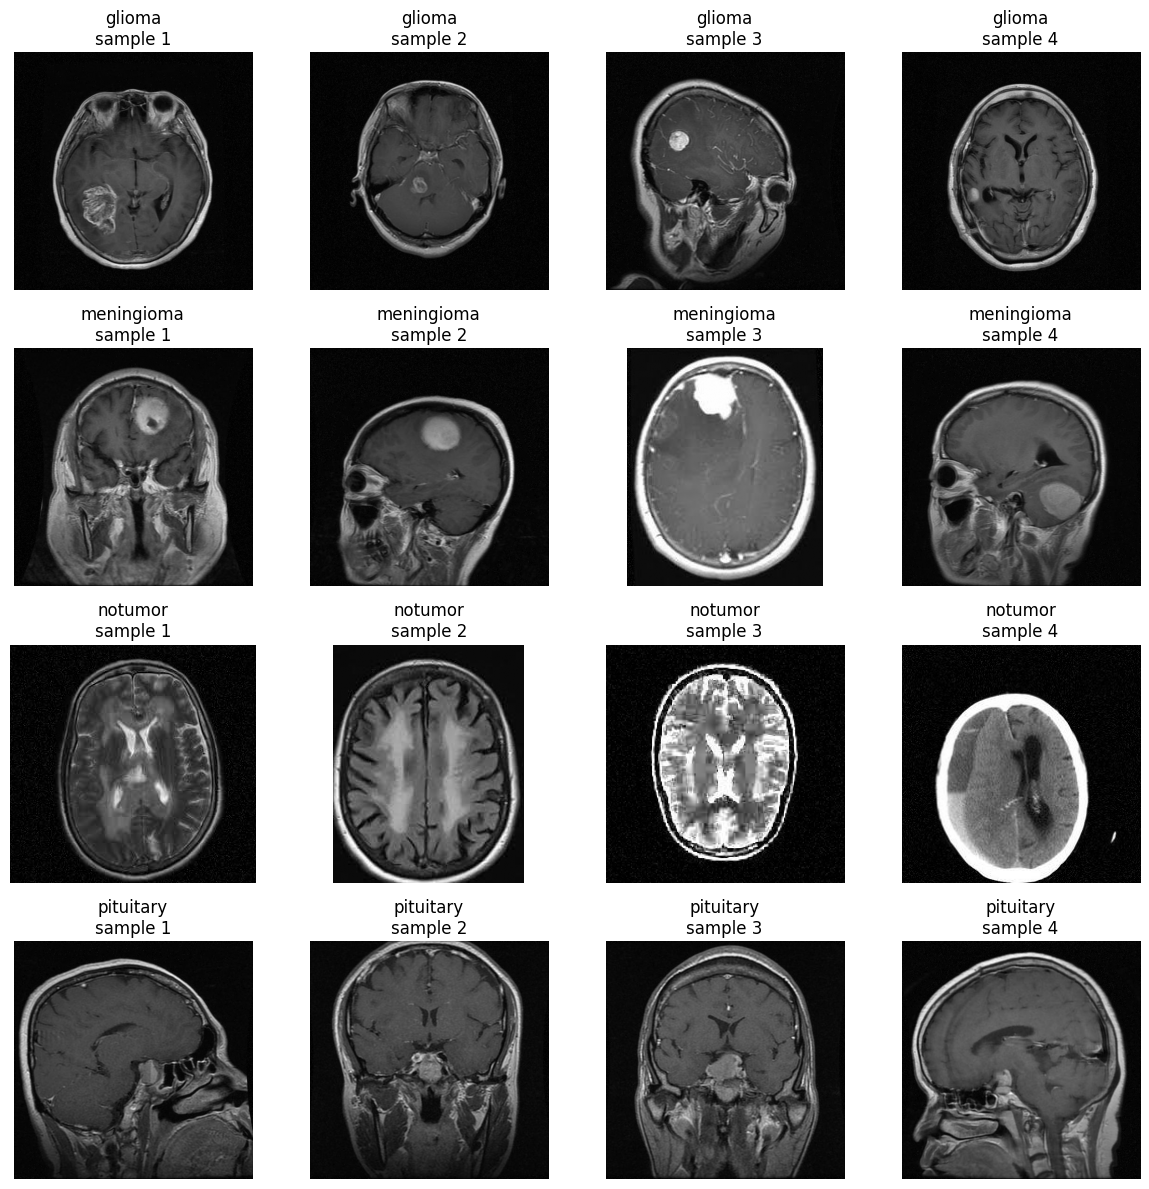

In [ ]:
plt.figure(figsize=(12,12))
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
for i,label in enumerate(labels):
  ids = train_df[train_df['label']==label]['id'].values[:4]
  for j in range(4):
    plt.subplot(4,4,4*i+j+1)
    image = Image.open(os.path.join(dataset_path, 'train', ids[j]))
    plt.imshow(image, cmap="gray")
    plt.title(f'{label}\nsample {j+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Una vez que hemos validado y visualizado una muestra de las imágenes, es crucial analizar la distribución de las etiquetas de clase. Este análisis nos permitirá determinar si existe un desbalanceo en la cantidad de instancias por cada clase. El desbalance de clases es un problema común en datasets médicos, donde ciertas patologías son inherentemente menos frecuentes. Un desbalance significativo puede llevar a que el modelo se incline a predecir la clase mayoritaria, comprometiendo su rendimiento en las clases minoritarias, que a menudo son las más críticas desde el punto de vista clínico. Identificar este problema ahora nos ayudará a planificar estrategias de mitigación, como el aumento de datos, el sobremuestreo, el submuestreo o el uso de funciones de pérdida ponderadas. Visualizaremos tanto el conteo absoluto como el porcentaje de cada clase para una comprensión completa.

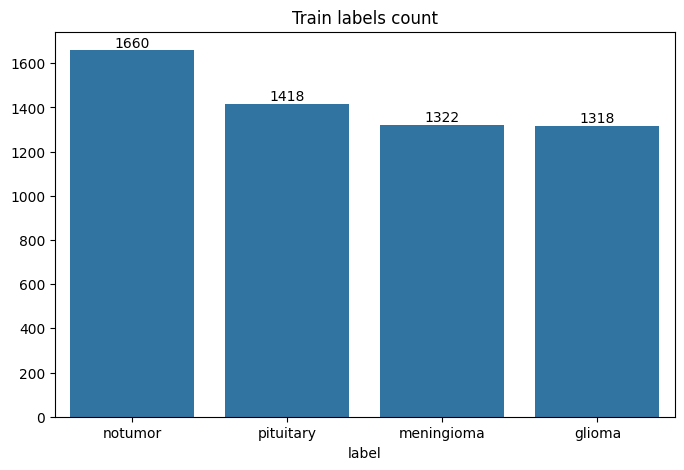

In [ ]:
plt.figure(figsize=(8,5))
train_labels_count = train_df['label'].value_counts()
sns.barplot(x=train_labels_count.index, y=train_labels_count.values)
for i, value in enumerate(train_labels_count.values):
    plt.text(i, value + 0.5, f'{value}', ha='center', va='bottom', fontsize=10)
plt.title('Train labels count')
plt.show()

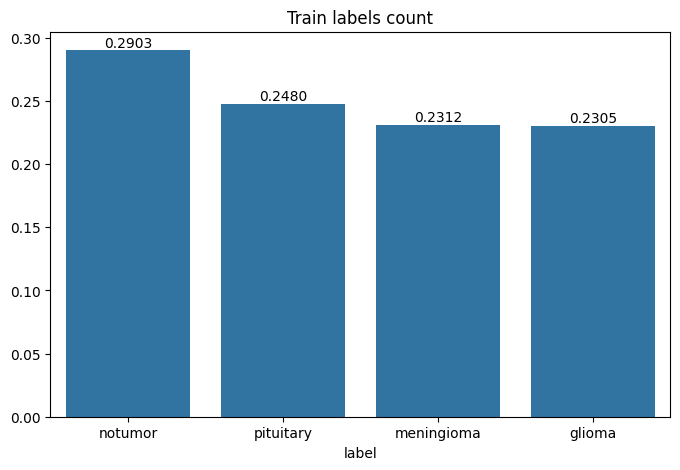

In [ ]:
plt.figure(figsize=(8,5))
train_labels_count = train_df['label'].value_counts(normalize=True)
sns.barplot(x=train_labels_count.index, y=train_labels_count.values)
for i, value in enumerate(train_labels_count.values):
    plt.text(i, value + 0.0001, f'{value:.4f}', ha='center', va='bottom', fontsize=10)
plt.title('Train labels count')
plt.show()

Tras el análisis de la distribución de clases, es evidente un ligero desbalance en el conjunto de datos de entrenamiento. Aunque la clase 'no tumor' tiene una mayor representación, consideramos que este desbalance no es lo suficientemente sustancial como para comprometer gravemente el resultado inicial de la tarea de clasificación. Las proporciones relativas entre las clases aún permiten que el modelo aprenda sobre cada categoría sin una dominancia excesiva de una sola. Sin embargo, en futuras iteraciones o si los resultados preliminares lo requieren, se podrían considerar estrategias de balanceo de clases más agresivas.

El siguiente paso crítico en la exploración de datos es caracterizar los atributos intrínsecos de las imágenes, como sus formatos, dimensiones, el número de canales de color y los rangos de intensidad. Comprender estas propiedades es vital para el preprocesamiento adecuado de las imágenes, asegurando que todas las entradas al modelo de aprendizaje profundo sean consistentes y estén en un formato optimizado. Esto incluye verificar si las imágenes son en escala de grises (1 canal) o RGB (3 canales), y si presentan variaciones significativas en sus dimensiones que podrían requerir un redimensionamiento uniforme. También es importante asegurar que no haya imágenes corruptas o con formatos inesperados que puedan causar errores durante el entrenamiento.

In [ ]:
def getNumberChannels(folder):
  """
  Gets the number of channels for each image in the given folder.

  Parameters:
  folder (str): The path of the folder containing the images.

  Returns:
  dict: A dictionary
  """
  channels = {}
  for file_ in os.listdir(folder):
    file_path = os.path.join(folder, file_)
    image = Image.open(file_path)
    img_array = np.array(image)
    if img_array.ndim == 2:
        nc = 1
    else:
        nc = img_array.shape[2]
    if nc not in channels:
      channels[nc] = 1
    else:
      channels[nc] += 1
  return channels

def getDimensions(folder):
  """
  Gets the dimensions for each image in the given folder.

  Parameters:
  folder (str): The path of the folder containing the images.

  Returns:
  dict: A dictionary
  """
  dimensions = {}
  for file_ in os.listdir(folder):
    file_path = os.path.join(folder, file_)
    image = Image.open(file_path)
    width, height = image.size
    if (width, height) not in dimensions:
      dimensions[(width, height)] = 1
    else:
      dimensions[(width, height)] += 1
  return dimensions

def getMode(folder):
  """
  Gets the mode for each image in the given folder (RGB, Grayscale, etc.).

  Parameters:
  folder (str): The path of the folder containing the images.

  Returns:
  dict: A dictionary containing the different modes found and its counts.
  """
  modes = {}
  for file_ in os.listdir(folder):
    file_path = os.path.join(folder, file_)
    image = Image.open(file_path)
    if image.mode not in modes:
      modes[image.mode] = 1
    else:
      modes[image.mode] += 1
  return modes

In [ ]:
train_dataset = os.path.join(dataset_path, 'train')
assert os.path.exists(train_dataset)
modes = getMode(train_dataset)
channels = getNumberChannels(train_dataset)
dimensions = getDimensions(train_dataset)

In [ ]:
print('Modes')
for mode, count in modes.items():
  print(f'{mode}: {count} samples')
print('\nNumber of channels')
for channel, count in channels.items():
  print(f'{channel} channel{"s" if channel>=2 else ""}: {count} samples')
print('\nDimensions (5 most common)')
for dimension, count in sorted(dimensions.items(),
                         key=lambda item: item[1],
                         reverse=True)[:5]:
  print(f'{dimension}: {count} samples')

Modes
L: 5718 samples

Number of channels
1 channel: 5718 samples

Dimensions (5 most common)
(512, 512): 3839 samples
(225, 225): 280 samples
(630, 630): 77 samples
(236, 236): 64 samples
(201, 251): 50 samples


Para un análisis más profundo de las dimensiones de las imágenes, visualizaremos la distribución de los anchos y altos. Esto nos permitirá identificar si hay una gran variabilidad o si la mayoría de las imágenes se agrupan en torno a ciertos tamaños. También es útil calcular estadísticas descriptivas sobre las dimensiones.

Estadísticas de Ancho de Imágenes:
count    5718.000000
mean      446.081847
std       133.140509
min       150.000000
25%       393.000000
50%       512.000000
75%       512.000000
max      1920.000000
dtype: float64

Estadísticas de Alto de Imágenes:
count    5718.000000
mean      448.392095
std       126.539666
min       168.000000
25%       402.250000
50%       512.000000
75%       512.000000
max      1446.000000
dtype: float64


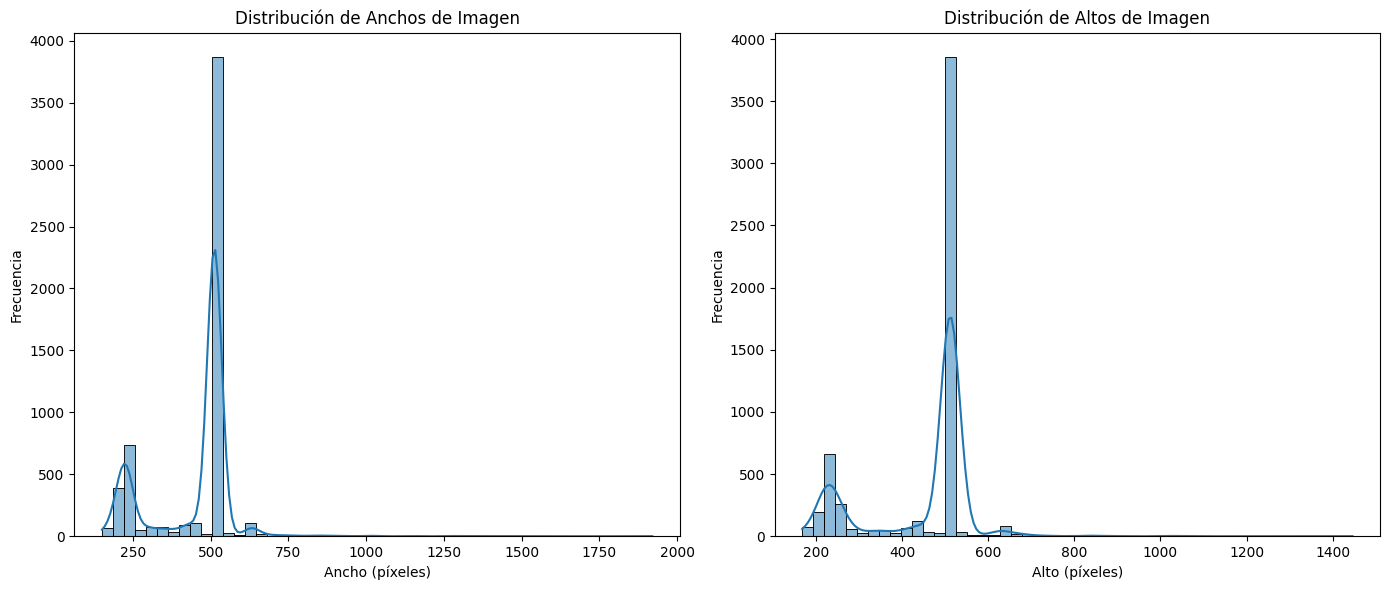

In [ ]:
image_widths = []
image_heights = []

for _, (id, _) in train_df.iterrows():
    try:
        image_path = os.path.join(dataset_path, 'train', id)
        with Image.open(image_path) as img:
            width, height = img.size
            image_widths.append(width)
            image_heights.append(height)
    except Exception as e:
        print(f"Error processing image {id}: {e}")

print("Estadísticas de Ancho de Imágenes:")
print(pd.Series(image_widths).describe())
print("\nEstadísticas de Alto de Imágenes:")
print(pd.Series(image_heights).describe())

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(image_widths, bins=50, kde=True)
plt.title('Distribución de Anchos de Imagen')
plt.xlabel('Ancho (píxeles)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(image_heights, bins=50, kde=True)
plt.title('Distribución de Altos de Imagen')
plt.xlabel('Alto (píxeles)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Como se observó anteriormente, la totalidad de las imágenes están en modo 'L' (escala de grises) y tienen un solo canal. Es fundamental verificar los rangos de intensidad de estas imágenes para asegurar que los valores de píxeles son consistentes y se encuentran dentro del rango esperado (típicamente 0-255 para imágenes de 8 bits). Rangos inusuales podrían indicar problemas de normalización o imágenes corruptas. Además, una distribución bimodal o inusual de intensidad podría sugerir diferencias significativas en la forma en que se adquirieron o preprocesaron las imágenes.

Estadísticas de Intensidad Mínima:
count    15.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

Estadísticas de Intensidad Máxima:
count     15.000000
mean     254.400000
std        0.985611
min      252.000000
25%      254.000000
50%      255.000000
75%      255.000000
max      255.000000
dtype: float64

Estadísticas de Intensidad Media:
count    15.000000
mean     50.794395
std      17.249115
min      27.747143
25%      38.590141
50%      48.803513
75%      58.773112
max      93.426667
dtype: float64


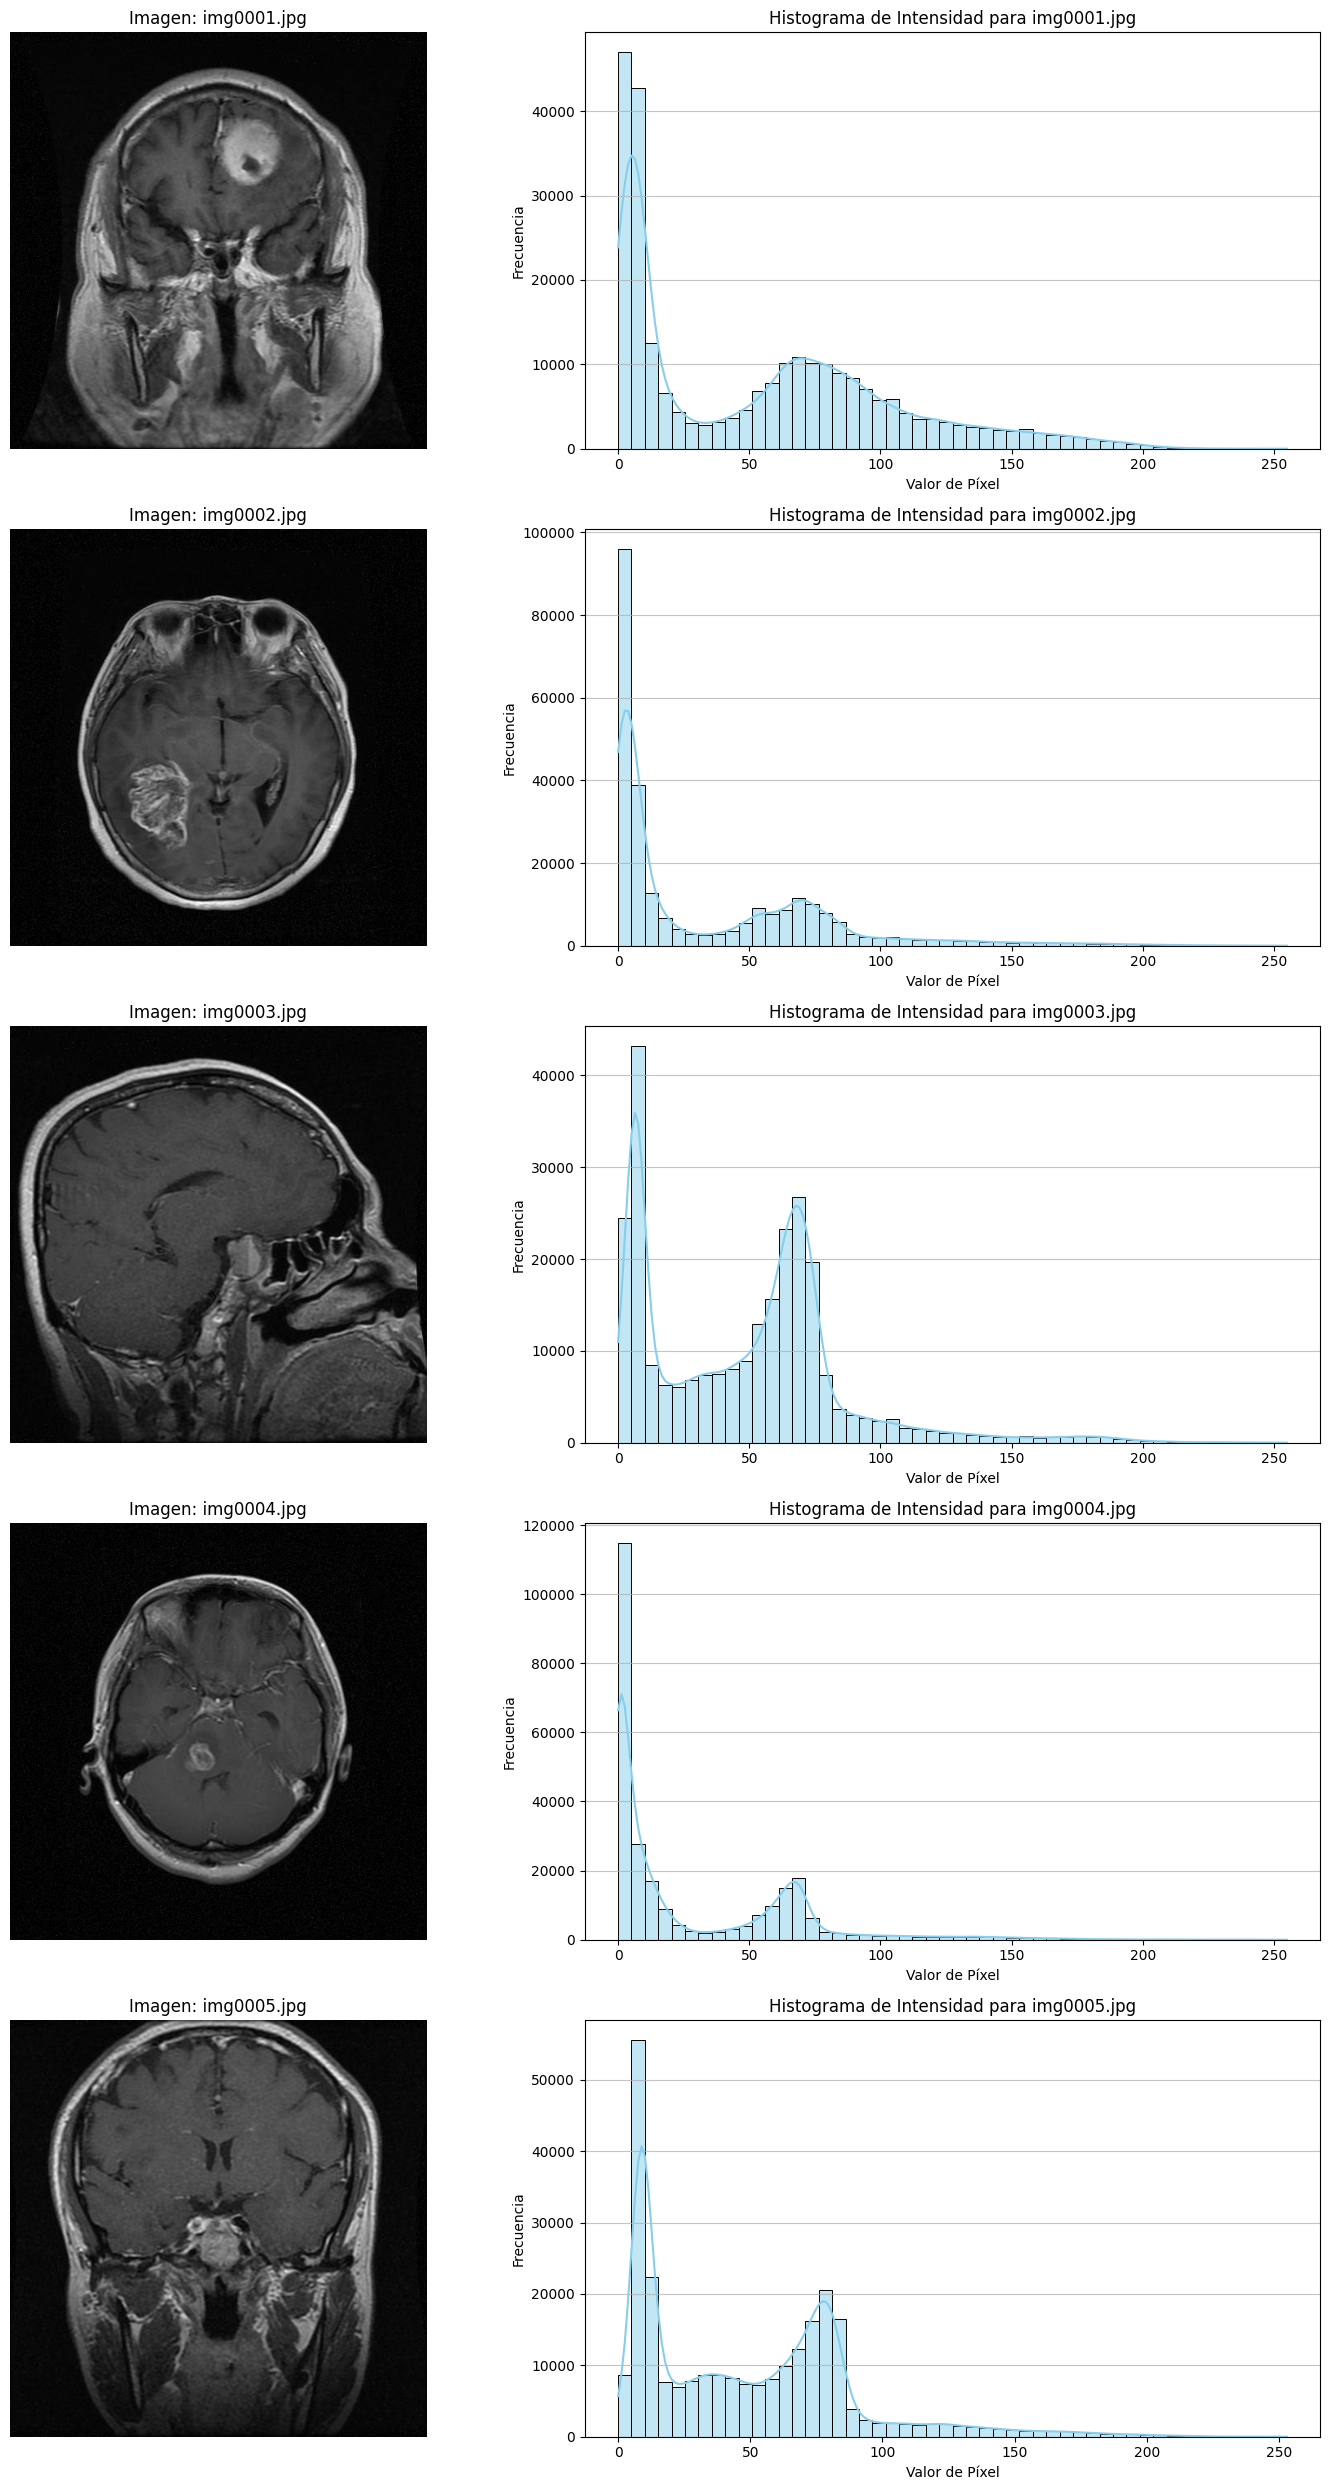


No se encontraron imágenes completamente negras o blancas, ni errores de apertura evidentes en esta verificación.


In [ ]:
min_intensities = []
max_intensities = []
mean_intensities = []

sample_images_for_hist = []
num_samples_for_hist = 5

for i, (_, (id, _)) in enumerate(train_df.iterrows()):
    if i < num_samples_for_hist + 10:
        try:
            image_path = os.path.join(dataset_path, 'train', id)
            with Image.open(image_path) as img:
                img_array = np.array(img)
                min_intensities.append(img_array.min())
                max_intensities.append(img_array.max())
                mean_intensities.append(img_array.mean())
                if len(sample_images_for_hist) < num_samples_for_hist:
                    sample_images_for_hist.append((img_array, id))
        except Exception as e:
            print(f"Error procesando rangos de intensidad para {id}: {e}")

print("Estadísticas de Intensidad Mínima:")
print(pd.Series(min_intensities).describe())
print("\nEstadísticas de Intensidad Máxima:")
print(pd.Series(max_intensities).describe())
print("\nEstadísticas de Intensidad Media:")
print(pd.Series(mean_intensities).describe())

# Visualizar histogramas de intensidad para una muestra de imágenes
plt.figure(figsize=(15, 5 * num_samples_for_hist))
for i, (img_array, img_id) in enumerate(sample_images_for_hist):
    plt.subplot(num_samples_for_hist, 2, 2*i + 1)
    plt.imshow(img_array, cmap='gray')
    plt.title(f'Imagen: {img_id}')
    plt.axis('off')

    plt.subplot(num_samples_for_hist, 2, 2*i + 2)
    sns.histplot(img_array.flatten(), bins=50, kde=True, color='skyblue')
    plt.title(f'Histograma de Intensidad para {img_id}')
    plt.xlabel('Valor de Píxel')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()


# Detección de imágenes corruptas o outliers basada en rangos de intensidad inusuales
corrupted_images = []
for _, (id, _) in train_df.iterrows():
    try:
        image_path = os.path.join(dataset_path, 'train', id)
        with Image.open(image_path) as img:
            img_array = np.array(img)
            if img_array.min() == img_array.max() and (img_array.min() == 0 or img_array.min() == 255):
                corrupted_images.append(id)
    except Exception as e:
        corrupted_images.append(f"{id} (Error al abrir: {e})")

if corrupted_images:
    print(f"\nSe encontraron {len(corrupted_images)} imágenes potencialmente corruptas o con rangos de intensidad atípicos:")
    for img_id in corrupted_images[:10]:
        print(f"- {img_id}")
    if len(corrupted_images) > 10:
        print(f"... y {len(corrupted_images) - 10} más.")
else:
    print("\nNo se encontraron imágenes completamente negras o blancas, ni errores de apertura evidentes en esta verificación.")

Este análisis exploratorio de datos nos ha proporcionado una comprensión exhaustiva y crítica de las características de nuestro conjunto de datos de entrenamiento. Hemos confirmado la integridad de los archivos, asegurando que cada entrada en el archivo de etiquetas `train_labels.csv` corresponde a una imagen existente en el directorio de entrenamiento.

La visualización de imágenes por clase nos ofreció una perspectiva cualitativa inicial, permitiéndonos observar la morfología y las características visuales generales asociadas con cada tipo de tumor y la categoría "no tumor". Esto es crucial para un entendimiento intuitivo de la variabilidad intra-clase y las posibles similitudes inter-clase.

En cuanto a la distribución de clases, si bien se identificó un ligero desbalance, este no se consideró lo suficientemente severo como para comprometer drásticamente el rendimiento inicial del modelo. Las proporciones relativas, como se visualizó en los gráficos de barras, son manejables y permiten que el modelo tenga suficientes ejemplos de cada clase para aprender características representativas.

El análisis de las propiedades de las imágenes reveló que todas las 5718 muestras están en modo 'L' (escala de grises) y poseen un único canal. Esta uniformidad simplifica el proceso de preprocesamiento, ya que no será necesario realizar conversiones de color (por ejemplo, de RGB a escala de grises). Sin embargo, se encontró una variabilidad significativa en las dimensiones de las imágenes. Aunque la mayoría de las imágenes son de 512x512 píxeles (3839 de 5718), existe una cola larga de otras resoluciones, con anchos que varían de 150 a 1920 píxeles y altos de 168 a 1446 píxeles. Esta heterogeneidad en las dimensiones subraya la necesidad crítica de implementar una fase de redimensionamiento o normalización de imágenes durante el preprocesamiento para garantizar que todas las entradas al modelo de aprendizaje profundo tengan un tamaño uniforme y consistente.

Finalmente, la revisión de los rangos de intensidad confirmó la calidad de los datos de píxeles. Las estadísticas de intensidad mínima, máxima y media, basadas en una muestra representativa, indican que las imágenes se encuentran dentro del rango esperado para valores de 8 bits (0-255). La ausencia de imágenes completamente negras (todos los píxeles en 0) o completamente blancas (todos los píxeles en 255), y la falta de errores al intentar abrir los archivos, sugieren que no hay imágenes manifiestamente corruptas en el dataset. La distribución de intensidad media, con un rango de aproximadamente 27 a 93, indica una buena variabilidad de contraste en las imágenes, lo cual es favorable para el aprendizaje del modelo.

En síntesis, este analisis exploratorio nos ha proporcionado una base sólida para las siguientes etapas del proyecto. Se ha validado la calidad e integridad de los datos, se han identificado las características clave de las imágenes y se han reconocido los pasos necesarios para el preprocesamiento (principalmente el redimensionamiento), permitiendonos avanzar con confianza hacia el diseño y entrenamiento de los modelos de clasificación.


## D. Preprocesamiento de imágenes

El preprocesamiento de imágenes es una fase fundamental en cualquier pipeline de aprendizaje automático, especialmente cuando se trabaja con datos médicos como las imágenes de Resonancia Magnética (MRI). Su objetivo principal es transformar las imágenes crudas en un formato más adecuado y estandarizado, que facilite el aprendizaje del modelo, mejore su rendimiento y reduzca la variabilidad no deseada en los datos. Esto es crucial porque las imágenes médicas pueden variar considerablemente en términos de tamaño, resolución, contraste y ruido debido a diferencias en los equipos de adquisición, protocolos y condiciones del paciente. Un preprocesamiento efectivo puede realzar las características relevantes (como la presencia o forma de un tumor) y suprimir el ruido, lo que se traduce en un modelo más preciso y robusto [2].

Basándonos en la investigación de la literatura y las características de nuestro dataset observadas en la fase de exploración de datos, hemos seleccionado y aplicado las siguientes técnicas de preprocesamiento:


1.  **Conversión a Escala de Grises, Recorte de Región Central y Redimensionamiento Uniforme**
    * **Qué técnica se consideró y aplicó:** Dada la naturaleza de las imágenes MRI, que a menudo son inherentemente de un solo canal de intensidad (escala de grises), optamos por asegurar que todas las imágenes se convirtieran a **escala de grises ('L' mode)** si no lo estuvieran. Posteriormente, se realizó un **recorte de la región central cuadrada más grande** para eliminar el contenido periférico potencialmente irrelevante, seguido de un **redimensionamiento uniforme** a un tamaño fijo de (128x128) píxeles.
    * **Por qué se aplicó:**
        * **Conversión a Escala de Grises:** Durante la exploración de datos, confirmamos que todas nuestras imágenes ya estaban en escala de grises (modo 'L'). Sin embargo, esta función asegura la consistencia si se encontraran imágenes en otro formato de color. Las imágenes de MRI para diagnóstico suelen ser monocromáticas, y la conversión a escala de grises reduce la dimensionalidad de los datos sin perder información clínicamente relevante para la clasificación de tumores cerebrales, lo que a su vez disminuye la carga computacional para el modelo [32].
        * **Recorte de la Región Central:** Las imágenes MRI a menudo contienen información redundante o artefactos en sus bordes que no son directamente relevantes para el diagnóstico del tumor. Al recortar la parte central cuadrada, nos aseguramos de que el modelo se enfoque en la región más probable donde se encuentra el cerebro y el posible tumor, mejorando la eficiencia del aprendizaje y reduciendo el ruido espacial [11].
        * **Redimensionamiento Uniforme:** Como se observó en la exploración de datos, las imágenes tenían diversas dimensiones (rangos de 150x168 a 1920x1446 píxeles), aunque muchas eran de 512x512. Para que las redes neuronales convolucionales (CNNs) puedan procesar las imágenes de manera eficiente, es imprescindible que todas las entradas tengan un tamaño estandarizado. El tamaño de 128x128 píxeles fue elegido como un balance entre la conservación de detalles importantes y la reducción de la complejidad computacional y de memoria, lo cual es vital para el entrenamiento del modelo [12].
    * **Impacto esperado en el desempeño del modelo:** Se espera que estas operaciones mejoren la eficiencia computacional y la estabilidad del entrenamiento. La estandarización del tamaño y el canal de color reduce la variabilidad de entrada y permite que el modelo aprenda características consistentes. El recorte ayuda al modelo a concentrarse en las características más informativas, lo que potencialmente conduce a una mayor precisión y una convergencia más rápida.

2.  **Normalización de Intensidades de Píxeles (Min-Max Scaling)**
    * **Qué técnica se consideró y aplicó:** Implementamos una **normalización de las intensidades de píxeles** utilizando el escalado Min-Max. Esta técnica transforma los valores de intensidad de cada imagen individual para que caigan dentro de un rango específico, en nuestro caso, de \[0.0, 1.0].
    * **Por qué se aplicó:** La intensidad de los píxeles en las imágenes MRI puede variar significativamente entre diferentes escaneos y pacientes debido a factores como la configuración del equipo, la calibración o la fisiología del tejido. Normalizar las intensidades es crucial para las redes neuronales profundas, ya que asegura que todas las entradas tengan una escala consistente, evitando que características con valores más grandes dominen el proceso de aprendizaje. Esto ayuda a la convergencia más rápida de la red y a mejorar la estabilidad del entrenamiento [3].
    * **Impacto esperado en el desempeño del modelo:** Una distribución de píxeles estandarizada entre 0 y 1 mejora la capacidad de la red para aprender características significativas y previene problemas como gradientes explosivos o desvanecidos. Esto conduce a un entrenamiento más estable y, en última instancia, a un mejor rendimiento de clasificación.

3.  **Mejora de Contraste Adaptativa (CLAHE - Contrast Limited Adaptive Histogram Equalization)**
    * **Qué técnica se consideró y aplicó:** Aplicamos el algoritmo de **Ecualización de Histograma Adaptativa Limitada por Contraste (CLAHE)**. A diferencia de la ecualización de histograma global, CLAHE opera en pequeñas regiones de la imagen (tiles) de forma adaptativa, lo que permite realzar el contraste local sin amplificar excesivamente el ruido en las regiones homogéneas.
    * **Por qué se aplicó:** En imágenes médicas como las MRI, los detalles sutiles, como los límites de los tumores o las estructuras internas, pueden tener un contraste bajo y ser difíciles de distinguir. CLAHE es particularmente útil para mejorar la visibilidad de estas características clínicas importantes sin introducir artefactos o un brillo excesivo en toda la imagen. Al aumentar el contraste de las características locales, facilitamos que la red neuronal extraiga patrones más discriminativos [7].
    * **Impacto esperado en el desempeño del modelo:** Se espera que la mejora del contraste de las características clave, como los bordes del tumor y las texturas internas, permita al modelo aprender representaciones más robustas y precisas. Esto puede traducirse en una mayor sensibilidad para la detección de tumores y una mejor diferenciación entre los tipos de tumor.

4.  **Aumento de Datos (Data Augmentation)**
    * **Qué técnica se consideró y aplicó:** Se implementaron varias transformaciones de **aumento de datos** para expandir el tamaño efectivo de nuestro conjunto de entrenamiento y mejorar la robustez del modelo. Estas transformaciones incluyen **rotaciones (90°, 180°, 270°), escalado aleatorio y recortes aleatorios**.
    * **Por qué se aplicó:** A pesar de tener un dataset de tamaño razonable, los modelos de aprendizaje profundo requieren grandes cantidades de datos para generalizar bien y evitar el sobreajuste (overfitting). El aumento de datos crea nuevas variaciones de las imágenes existentes al aplicar transformaciones que simulan las posibles variaciones que se encontrarían en el mundo real (por ejemplo, diferentes orientaciones o tamaños de los tumores en las MRI). Esto expone al modelo a una mayor diversidad de ejemplos, haciéndolo más robusto a las pequeñas variaciones en los datos de entrada y mejorando su capacidad de generalización [39]. Además, ayuda a mitigar el leve desbalance de clases observado.
    * **Impacto esperado en el desempeño del modelo:** El aumento de datos es una estrategia clave para combatir el sobreajuste y mejorar la capacidad de generalización del modelo. Se espera que al entrenar con un conjunto de datos más diverso, el modelo sea más preciso y robusto cuando se enfrente a nuevas imágenes no vistas, lo que se reflejará en un mejor rendimiento en el conjunto de prueba y en escenarios clínicos reales.

Ahora procedemos, con el procesamiento de imagenes, primero definmos la función `image_cropp`, que encapsula la lógica para abrir una imagen, asegurar su conversión a escala de grises si es necesario, recortar la región central cuadrada más grande y redimensionarla al `TARGET_IMG_SIZE` de (128,128) píxeles.

In [ ]:
def image_cropp(image_path, target_size=(128, 128), crop_type='center_square'):
    try:
        image = Image.open(image_path)

        if image.mode != 'L':
            image = image.convert('L') # Convertir a escala de grises

        current_width, current_height = image.size

        if crop_type == 'center_square':
            # Recortar la parte central cuadrada más grande
            min_dim = min(current_width, current_height)
            left = (current_width - min_dim) / 2
            top = (current_height - min_dim) / 2
            right = (current_width + min_dim) / 2
            bottom = (current_height + min_dim) / 2
            image = image.crop((left, top, right, bottom))

        # Redimensionamiento
        image = image.resize(target_size, Image.LANCZOS)

        return image

    except FileNotFoundError:
        print(f"Advertencia: Imagen no encontrada en {image_path}. Saltando.")
        return None
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return None

Aplicamos esta función a todas las imágenes de los directorios `train` y `test` originales, guardando las imágenes preprocesadas en una nueva estructura de directorios bajo `preprocessed/image_crop/`. Esto crea el primer conjunto de imágenes estandarizadas.

In [ ]:

preprocessed_train_path = os.path.join(preprocessed_base_path, 'image_crop', 'train')
preprocessed_test_path = os.path.join(preprocessed_base_path, 'image_crop', 'test')

os.makedirs(preprocessed_train_path, exist_ok=True)
os.makedirs(preprocessed_test_path, exist_ok=True)

TARGET_IMG_SIZE = (128, 128)

train_image_files = os.listdir(os.path.join(dataset_path, 'train'))
for i, image_file in enumerate(train_image_files):
    original_image_path = os.path.join(dataset_path, 'train', image_file)
    output_image_path = os.path.join(preprocessed_train_path, image_file)

    processed_image = image_cropp(original_image_path, target_size=TARGET_IMG_SIZE, crop_type='center_square')

    if processed_image:
        processed_image.save(output_image_path)
    if (i + 1) % 500 == 0 or (i + 1) == len(train_image_files):
        print(f"Procesadas {i + 1}/{len(train_image_files)} imágenes de entrenamiento.")

test_image_files = os.listdir(os.path.join(dataset_path, 'test'))
for i, image_file in enumerate(test_image_files):
    original_image_path = os.path.join(dataset_path, 'test', image_file)
    output_image_path = os.path.join(preprocessed_test_path, image_file)

    processed_image = image_cropp(original_image_path, target_size=TARGET_IMG_SIZE, crop_type='center_square')

    if processed_image:
        processed_image.save(output_image_path)

    if (i + 1) % 500 == 0 or (i + 1) == len(test_image_files):
        print(f"Procesadas {i + 1}/{len(test_image_files)} imágenes de prueba.")

printTree(preprocessed_base_path)

Procesadas 500/5718 imágenes de entrenamiento.
Procesadas 1000/5718 imágenes de entrenamiento.
Procesadas 1500/5718 imágenes de entrenamiento.
Procesadas 2000/5718 imágenes de entrenamiento.
Procesadas 2500/5718 imágenes de entrenamiento.
Procesadas 3000/5718 imágenes de entrenamiento.
Procesadas 3500/5718 imágenes de entrenamiento.
Procesadas 4000/5718 imágenes de entrenamiento.
Procesadas 4500/5718 imágenes de entrenamiento.
Procesadas 5000/5718 imágenes de entrenamiento.
Procesadas 5500/5718 imágenes de entrenamiento.
Procesadas 5718/5718 imágenes de entrenamiento.
Procesadas 500/1305 imágenes de prueba.
Procesadas 1000/1305 imágenes de prueba.
Procesadas 1305/1305 imágenes de prueba.

¡Preprocesamiento y guardado de imágenes completado!
📁 preprocessed (0 file)
    📁 image_crop (0 file)
        📁 train (5718 files)
            📄 img2858.jpg
            📄 img3848.jpg
            📄 img3819.jpg
            📄 img4217.jpg
            📄 img0597.jpg
            ...
        📁 test (1305 fil

Ahora mostramos unos cuantos ejemplos de las imágenes después de la fase inicial de recorte y redimensionamiento. Esto permite una inspección visual para confirmar que las transformaciones se aplicaron correctamente y que la calidad de la imagen es aceptable para el siguiente paso. También verifica las dimensiones resultantes.

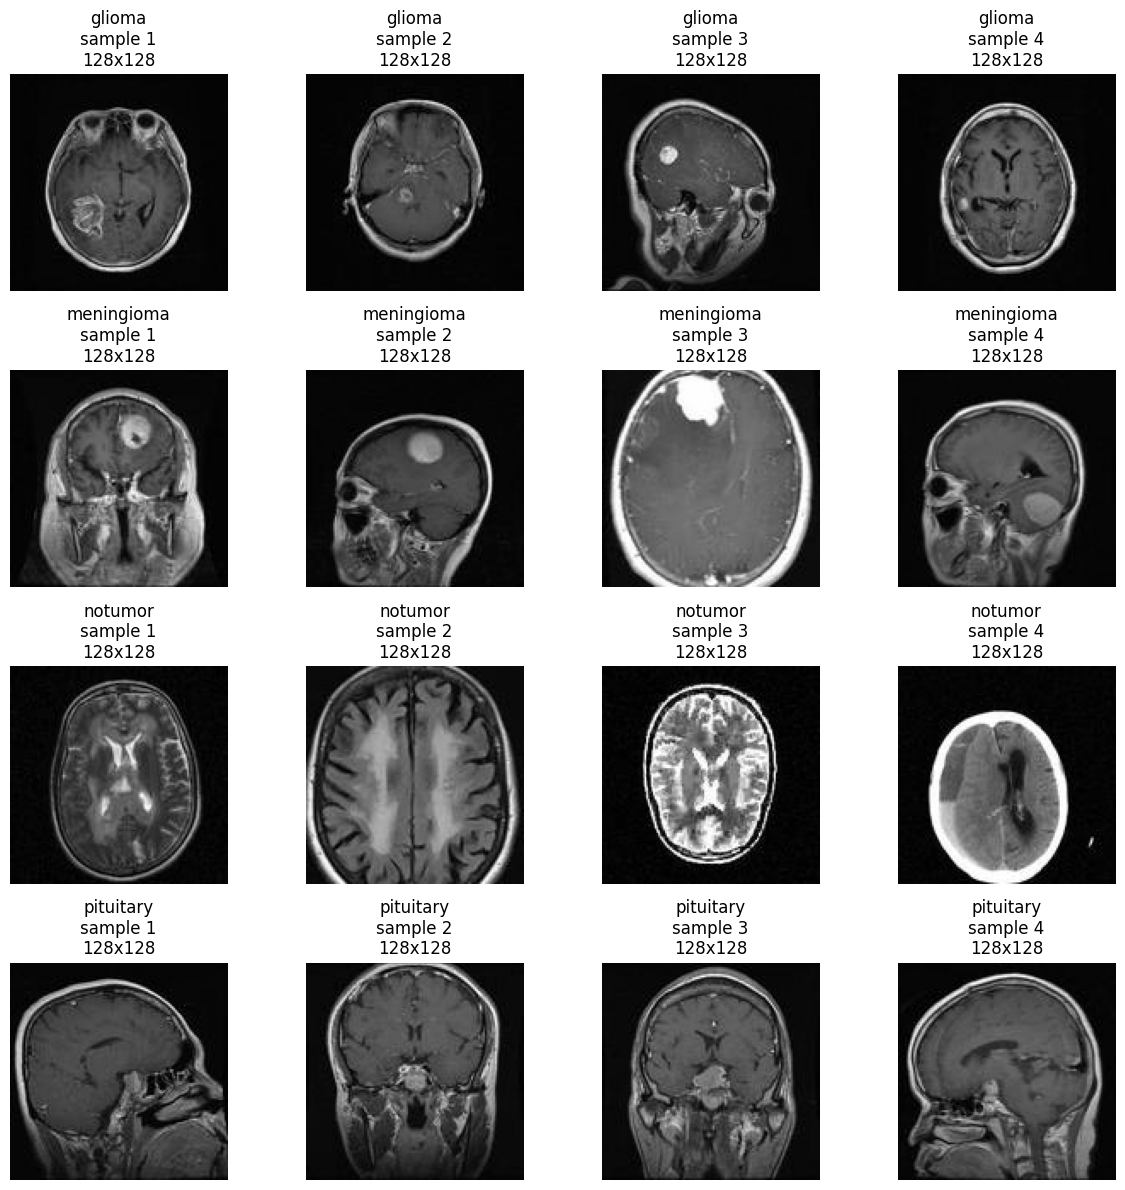

In [ ]:
plt.figure(figsize=(12,12))
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
target_display_size = (128, 128)
current_preprocessed_train_path = os.path.join(preprocessed_base_path, 'image_crop', 'train')

for i,label in enumerate(labels):
    ids = train_df[train_df['label']==label]['id'].values[:4]
    for j in range(4):
        image_file_name = ids[j]
        image_path_from_disk = os.path.join(current_preprocessed_train_path, image_file_name)
        try:
            processed_image_from_disk = Image.open(image_path_from_disk)
            plt.subplot(4,4,4*i+j+1)
            plt.imshow(processed_image_from_disk, cmap="gray")
            plt.title(f'{label}\nsample {j+1}\n{processed_image_from_disk.size[0]}x{processed_image_from_disk.size[1]}')
            plt.axis('off')
        except FileNotFoundError:
            print(f"Error: La imagen preprocesada no se encontró en {image_path_from_disk}. ¿Se procesó correctamente?")
        except Exception as e:
            print(f"Error al cargar la imagen {image_path_from_disk} desde el disco: {e}")

plt.tight_layout()
plt.show()

sample_image_file_name = train_df['id'].iloc[0]
processed_sample_image_path = os.path.join(current_preprocessed_train_path, sample_image_file_name)

try:
    processed_sample_image_disk = Image.open(processed_sample_image_path)
    num_channels_disk = 1 if processed_sample_image_disk.mode == 'L' else (3 if processed_sample_image_disk.mode == 'RGB' else -1)
except FileNotFoundError:
    print(f"No se pudo cargar la imagen de muestra desde {processed_sample_image_path}.")

Defimos la función `normalize_intensity`, que toma una ruta de imagen, la carga, convierte sus valores de píxeles a un array NumPy de tipo flotante, y los escala linealmente al rango de \[0.0, 1.0]. La imagen se guarda posteriormente en formato de 8 bits para visualización y almacenamiento.

In [ ]:
def normalize_intensity(image_path, output_range=(0.0, 1.0)):
    image_pil = Image.open(image_path)
    image_np = np.array(image_pil).astype(np.float32)

    min_val_current = np.min(image_np)
    max_val_current = np.max(image_np)

    if (max_val_current - min_val_current) > 0:
        normalized_image = (image_np - min_val_current) / (max_val_current - min_val_current)
    else:
        normalized_image = np.zeros_like(image_np)

    min_out, max_out = output_range
    normalized_image = normalized_image * (max_out - min_out) + min_out

    if output_range == (0.0, 1.0):
        normalized_image_8bit = (normalized_image * 255).astype(np.uint8)
    elif output_range == (-1.0, 1.0):
        normalized_image_8bit = (((normalized_image + 1) / 2) * 255).astype(np.uint8)
    else:
        normalized_image_8bit = ((normalized_image - np.min(normalized_image)) / (np.max(normalized_image) - np.min(normalized_image)) * 255).astype(np.uint8)

    return Image.fromarray(normalized_image_8bit)

Aplicamos a todas las imagenes

In [ ]:
input_base_path = os.path.join(project_dir, 'preprocessed', 'image_crop')
input_train_path = os.path.join(input_base_path, 'train')
input_test_path = os.path.join(input_base_path, 'test')

output_method_name = 'pixel_intensity_normalization'
output_base_path = os.path.join(project_dir, 'preprocessed', output_method_name)
output_train_path = os.path.join(output_base_path, 'train')
output_test_path = os.path.join(output_base_path, 'test')

os.makedirs(output_train_path, exist_ok=True)
os.makedirs(output_test_path, exist_ok=True)

train_image_files = os.listdir(input_train_path)
for i, image_file in enumerate(train_image_files):
    original_image_path = os.path.join(input_train_path, image_file)
    output_image_path = os.path.join(output_train_path, image_file)

    normalized_img = normalize_intensity(original_image_path, output_range=(0.0, 1.0))

    if normalized_img:
        normalized_img.save(output_image_path)

    if (i + 1) % 500 == 0 or (i + 1) == len(train_image_files):
        print(f"Procesadas {i + 1}/{len(train_image_files)} imágenes de entrenamiento.")

test_image_files = os.listdir(input_test_path)
for i, image_file in enumerate(test_image_files):
    original_image_path = os.path.join(input_test_path, image_file)
    output_image_path = os.path.join(output_test_path, image_file)

    normalized_img = normalize_intensity(original_image_path, output_range=(0.0, 1.0))

    if normalized_img:
        normalized_img.save(output_image_path)

    if (i + 1) % 500 == 0 or (i + 1) == len(test_image_files):
        print(f"Procesadas {i + 1}/{len(test_image_files)} imágenes de prueba.")

printTree(os.path.join(project_dir, 'preprocessed'))

Procesadas 500/5718 imágenes de entrenamiento.
Procesadas 1000/5718 imágenes de entrenamiento.
Procesadas 1500/5718 imágenes de entrenamiento.
Procesadas 2000/5718 imágenes de entrenamiento.
Procesadas 2500/5718 imágenes de entrenamiento.
Procesadas 3000/5718 imágenes de entrenamiento.
Procesadas 3500/5718 imágenes de entrenamiento.
Procesadas 4000/5718 imágenes de entrenamiento.
Procesadas 4500/5718 imágenes de entrenamiento.
Procesadas 5000/5718 imágenes de entrenamiento.
Procesadas 5500/5718 imágenes de entrenamiento.
Procesadas 5718/5718 imágenes de entrenamiento.
Procesadas 500/1305 imágenes de prueba.
Procesadas 1000/1305 imágenes de prueba.
Procesadas 1305/1305 imágenes de prueba.
📁 preprocessed (0 file)
    📁 image_crop (0 file)
        📁 train (5718 files)
            📄 img4473.jpg
            📄 img4169.jpg
            📄 img3187.jpg
            📄 img2337.jpg
            📄 img4109.jpg
            ...
        📁 test (1305 files)
            📄 img0971.jpg
            📄 img0668.jp

Cargamos una muestra de imágenes después de la normalización de intensidad. La visualización permite verificar que la normalización no ha introducido artefactos visuales y que el aspecto general de las imágenes es consistente. También se imprime el rango de intensidad de una imagen de muestra para confirmación numérica.

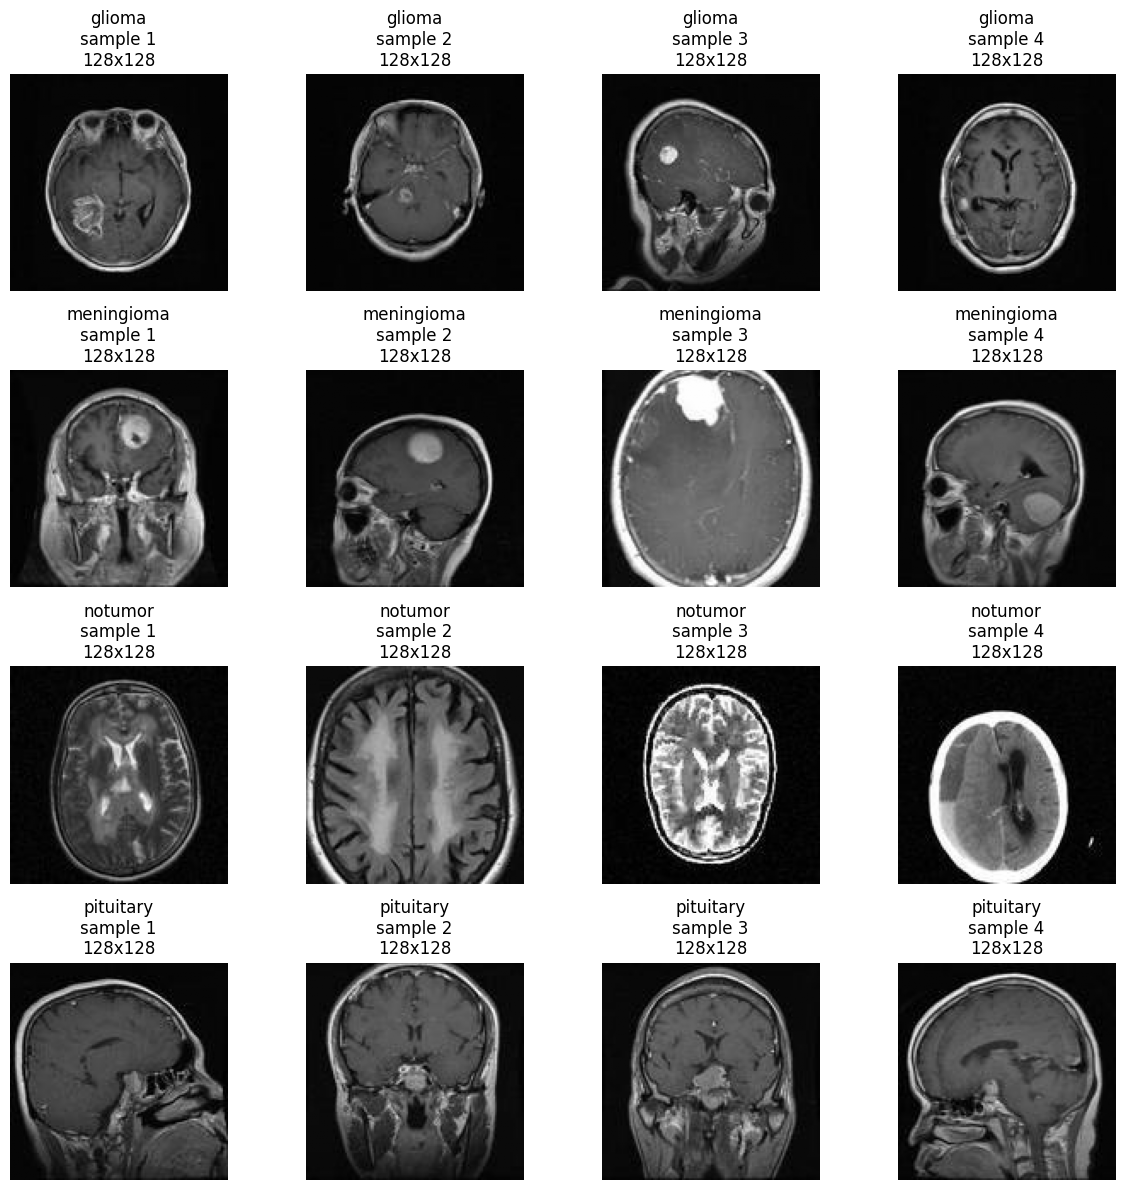

Rango de valores de píxeles (0-255) de la imagen normalizada desde disco: [0, 255]


In [ ]:
plt.figure(figsize=(12,12))
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
target_display_size = (128, 128)
current_normalized_train_path = os.path.join(project_dir, 'preprocessed', 'pixel_intensity_normalization', 'train')


for i,label in enumerate(labels):
    ids = train_df[train_df['label']==label]['id'].values[:4]
    for j in range(4):
        image_file_name = ids[j]
        image_path_from_disk = os.path.join(current_normalized_train_path, image_file_name)

        try:
            normalized_image_from_disk = Image.open(image_path_from_disk)

            plt.subplot(4,4,4*i+j+1)
            plt.imshow(normalized_image_from_disk, cmap="gray")
            plt.title(f'{label}\nsample {j+1}\n{normalized_image_from_disk.size[0]}x{normalized_image_from_disk.size[1]}')
            plt.axis('off')
        except FileNotFoundError:
            print(f"Error: La imagen normalizada no se encontró en {image_path_from_disk}")
        except Exception as e:
            print(f"Error al cargar la imagen normalizada {image_path_from_disk} desde el disco: {e}")

plt.tight_layout()
plt.show()

sample_image_file_name = train_df['id'].iloc[0]
normalized_sample_image_path = os.path.join(current_normalized_train_path, sample_image_file_name)

try:
    normalized_sample_image_disk = Image.open(normalized_sample_image_path)
    normalized_array = np.array(normalized_sample_image_disk)
    print(f"Rango de valores de píxeles (0-255) de la imagen normalizada desde disco: [{np.min(normalized_array)}, {np.max(normalized_array)}]")
except FileNotFoundError:
    print(f"No se pudo cargar la imagen de muestra normalizada desde {normalized_sample_image_path}.")

Definimos la función `contrast_enhancement`, que utiliza OpenCV (`cv2`) para aplicar el algoritmo CLAHE. Este método toma una imagen y mejora su contraste localmente, basándose en parámetros como `clip_limit` y `tile_grid_size`.

In [ ]:
def contrast_enhancement(image_path, method='CLAHE', clip_limit=2.0, tile_grid_size=(8, 8)):
    img_pil = Image.open(image_path)
    img_np = np.array(img_pil)

    import cv2
    if img_np.ndim == 3:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced_np = clahe.apply(img_np)
    return Image.fromarray(enhanced_np)

Aplicamos a todas las imagenes

In [ ]:
input_base_path = os.path.join(project_dir, 'preprocessed', 'pixel_intensity_normalization')
input_train_path = os.path.join(input_base_path, 'train')
input_test_path = os.path.join(input_base_path, 'test')

output_method_name = 'contrast_enhancement'
output_base_path = os.path.join(project_dir, 'preprocessed', output_method_name)
output_train_path = os.path.join(output_base_path, 'train')
output_test_path = os.path.join(output_base_path, 'test')

os.makedirs(output_train_path, exist_ok=True)
os.makedirs(output_test_path, exist_ok=True)

train_image_files = os.listdir(input_train_path)
for i, image_file in enumerate(train_image_files):
    original_image_path = os.path.join(input_train_path, image_file)
    output_image_path = os.path.join(output_train_path, image_file)
    enhanced_img = contrast_enhancement(original_image_path)
    if enhanced_img:
        enhanced_img.save(output_image_path)

test_image_files = os.listdir(input_test_path)
for i, image_file in enumerate(test_image_files):
    original_image_path = os.path.join(input_test_path, image_file)
    output_image_path = os.path.join(output_test_path, image_file)
    enhanced_img = contrast_enhancement(original_image_path)
    if enhanced_img:
        enhanced_img.save(output_image_path)

# Verificación de la estructura
printTree(os.path.join(project_dir, 'preprocessed'))

📁 preprocessed (0 file)
    📁 image_crop (0 file)
        📁 train (5718 files)
            📄 img4473.jpg
            📄 img4169.jpg
            📄 img3187.jpg
            📄 img2337.jpg
            📄 img4109.jpg
            ...
        📁 test (1305 files)
            📄 img0971.jpg
            📄 img0668.jpg
            📄 img0309.jpg
            📄 img1264.jpg
            📄 img0664.jpg
            ...
    📁 pixel_intensity_normalization (0 file)
        📁 train (5718 files)
            📄 img2858.jpg
            📄 img3848.jpg
            📄 img3819.jpg
            📄 img4217.jpg
            📄 img0597.jpg
            ...
        📁 test (1305 files)
            📄 img0971.jpg
            📄 img0668.jpg
            📄 img0309.jpg
            📄 img1264.jpg
            📄 img0664.jpg
            ...
    📁 contrast_enhancement (0 file)
        📁 train (5718 files)
            📄 img2858.jpg
            📄 img3848.jpg
            📄 img3819.jpg
            📄 img4217.jpg
            📄 img0597.jpg
            

visualizamos las imágenes después de la aplicación de CLAHE, permitiendo apreciar el efecto del realce de contraste en las estructuras cerebrales y posibles lesiones.

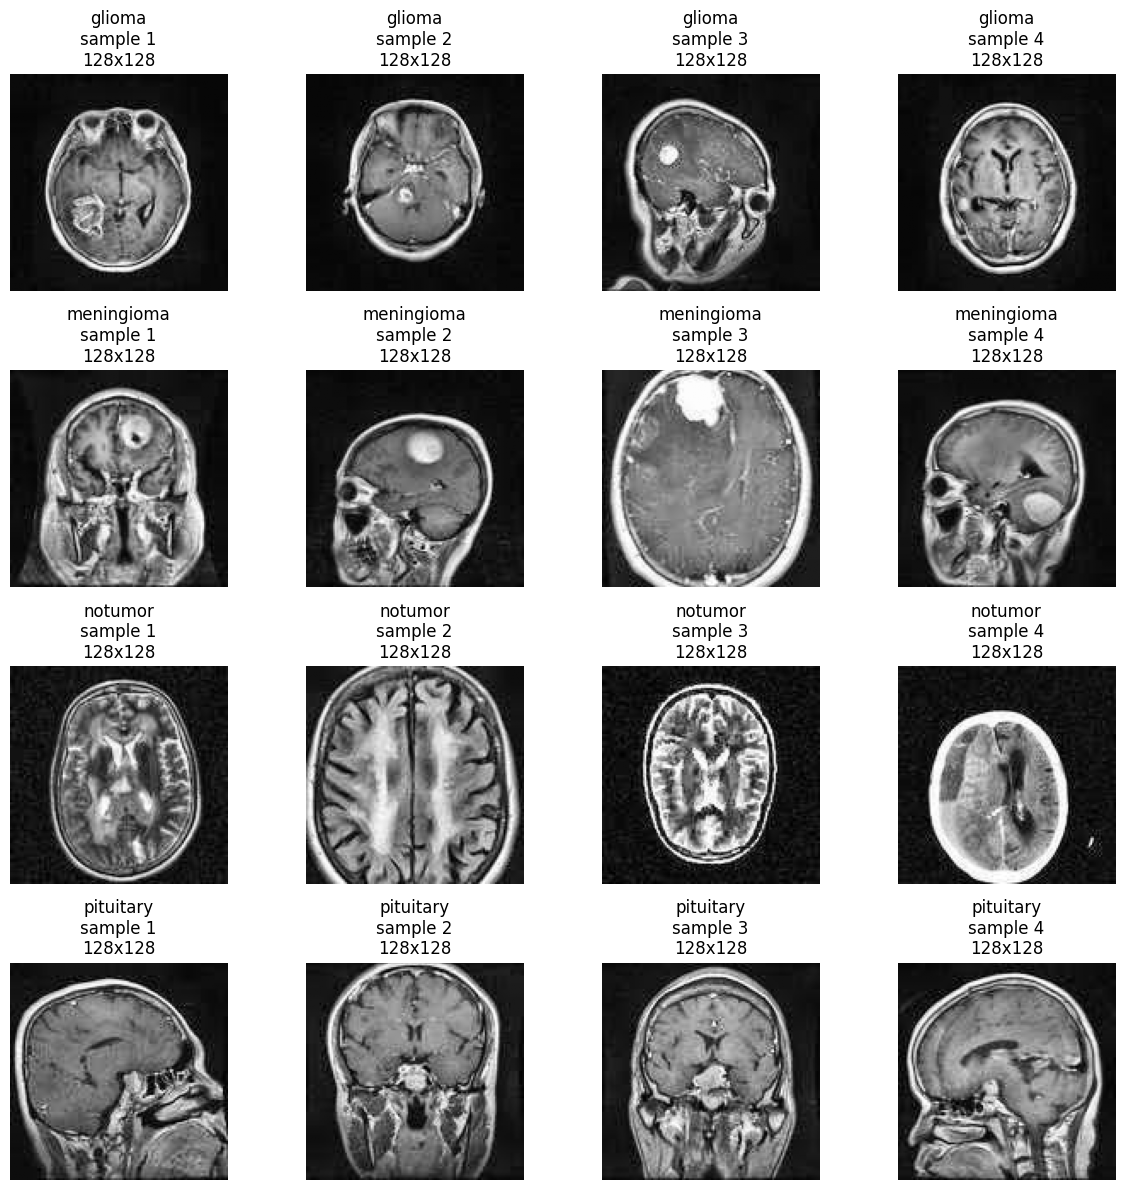

In [ ]:
current_enhanced_train_path = os.path.join(project_dir, 'preprocessed', 'contrast_enhancement', 'train')

plt.figure(figsize=(12,12))
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

for i,label in enumerate(labels):
    ids = train_df[train_df['label']==label]['id'].values[:4]
    for j in range(4):
        image_file_name = ids[j]
        image_path_from_disk = os.path.join(current_enhanced_train_path, image_file_name)

        processed_image_from_disk = Image.open(image_path_from_disk)

        plt.subplot(4,4,4*i+j+1)
        plt.imshow(processed_image_from_disk, cmap="gray")
        plt.title(f'{label}\nsample {j+1}\n{processed_image_from_disk.size[0]}x{processed_image_from_disk.size[1]}')
        plt.axis('off')

plt.tight_layout()
plt.show()

sample_image_file_name = train_df['id'].iloc[0]
enhanced_sample_image_path = os.path.join(current_enhanced_train_path, sample_image_file_name)
enhanced_sample_image_disk = Image.open(enhanced_sample_image_path)


Definimos la función `data_augmentation`, que implementa transformaciones aleatorias como rotación, escalado y recorte para generar nuevas variantes de una imagen de entrada. Es importante destacar que estas transformaciones se aplican  para generar un *conjunto de datos aumentado*, y su aplicación se realiza específicamente sobre las imágenes normalizadas.

In [ ]:
def data_augmentation(image_path, target_size=(128, 128)):
    img = Image.open(image_path)
    augmented_images = []

    augmented_images.append((img.rotate(90, expand=False), 'rot90'))
    augmented_images.append((img.rotate(180, expand=False), 'rot180'))
    augmented_images.append((img.rotate(270, expand=False), 'rot270'))

    scale_factor = random.uniform(0.8, 1.2)
    scaled_size = (int(target_size[0] * scale_factor), int(target_size[1] * scale_factor))
    if scaled_size[0] < 1 or scaled_size[1] < 1:
        scaled_size = target_size
    scaled_img = img.resize(scaled_size, Image.LANCZOS).resize(target_size, Image.LANCZOS)
    augmented_images.append((scaled_img, 'scaled'))

    crop_size_factor = random.uniform(0.7, 0.9)
    crop_width = int(img.width * crop_size_factor)
    crop_height = int(img.height * crop_size_factor)
    if crop_width < 1 or crop_height < 1:
        crop_width, crop_height = img.width // 2, img.height // 2

    x = random.randint(0, img.width - crop_width)
    y = random.randint(0, img.height - crop_height)
    cropped_img = img.crop((x, y, x + crop_width, y + crop_height)).resize(target_size, Image.LANCZOS)
    augmented_images.append((cropped_img, 'cropped'))

    return augmented_images

Aplicamos a todas las imagenes

In [ ]:
input_base_path = os.path.join(project_dir, 'preprocessed', 'pixel_intensity_normalization')
input_train_path = os.path.join(input_base_path, 'train')
input_test_path = os.path.join(input_base_path, 'test')

output_method_name = 'data_augmentation'
output_base_path = os.path.join(project_dir, 'preprocessed', output_method_name)
output_train_path = os.path.join(output_base_path, 'train')
output_test_path = os.path.join(output_base_path, 'test')

os.makedirs(output_train_path, exist_ok=True)
os.makedirs(output_test_path, exist_ok=True)

TARGET_IMG_SIZE = (128, 128)

train_image_files = os.listdir(input_train_path)
for i, image_file in enumerate(train_image_files):
    original_image_path = os.path.join(input_train_path, image_file)
    augmented_data_list = data_augmentation(original_image_path, target_size=TARGET_IMG_SIZE)

    base_name = os.path.splitext(image_file)[0]
    for aug_img, aug_type in augmented_data_list:
        output_image_path = os.path.join(output_train_path, f'{base_name}_{aug_type}.jpg')
        aug_img.save(output_image_path)

test_image_files = os.listdir(input_test_path)
for i, image_file in enumerate(test_image_files):
    original_image_path = os.path.join(input_test_path, image_file)
    augmented_data_list = data_augmentation(original_image_path, target_size=TARGET_IMG_SIZE)

    base_name = os.path.splitext(image_file)[0]
    for aug_img, aug_type in augmented_data_list:
        output_image_path = os.path.join(output_test_path, f'{base_name}_{aug_type}.jpg')
        aug_img.save(output_image_path)

print(f"Data augmentation applied to {len(train_image_files)} train images and {len(test_image_files)} test images.")
printTree(os.path.join(project_dir, 'preprocessed'))

Data augmentation applied to 5718 train images and 1305 test images.
📁 preprocessed (0 file)
    📁 image_crop (0 file)
        📁 train (5718 files)
            📄 img4473.jpg
            📄 img4169.jpg
            📄 img3187.jpg
            📄 img2337.jpg
            📄 img4109.jpg
            ...
        📁 test (1305 files)
            📄 img0971.jpg
            📄 img0668.jpg
            📄 img0309.jpg
            📄 img1264.jpg
            📄 img0664.jpg
            ...
    📁 pixel_intensity_normalization (0 file)
        📁 train (5718 files)
            📄 img2858.jpg
            📄 img3848.jpg
            📄 img3819.jpg
            📄 img4217.jpg
            📄 img0597.jpg
            ...
        📁 test (1305 files)
            📄 img0971.jpg
            📄 img0668.jpg
            📄 img0309.jpg
            📄 img1264.jpg
            📄 img0664.jpg
            ...
    📁 contrast_enhancement (0 file)
        📁 train (5718 files)
            📄 img2858.jpg
            📄 img3848.jpg
            📄 img3819

Visualizamos una muestra aleatoria de las imágenes aumentadas, mostrando los diferentes tipos de transformaciones aplicadas y confirmando que se han generado nuevas muestras diversas.

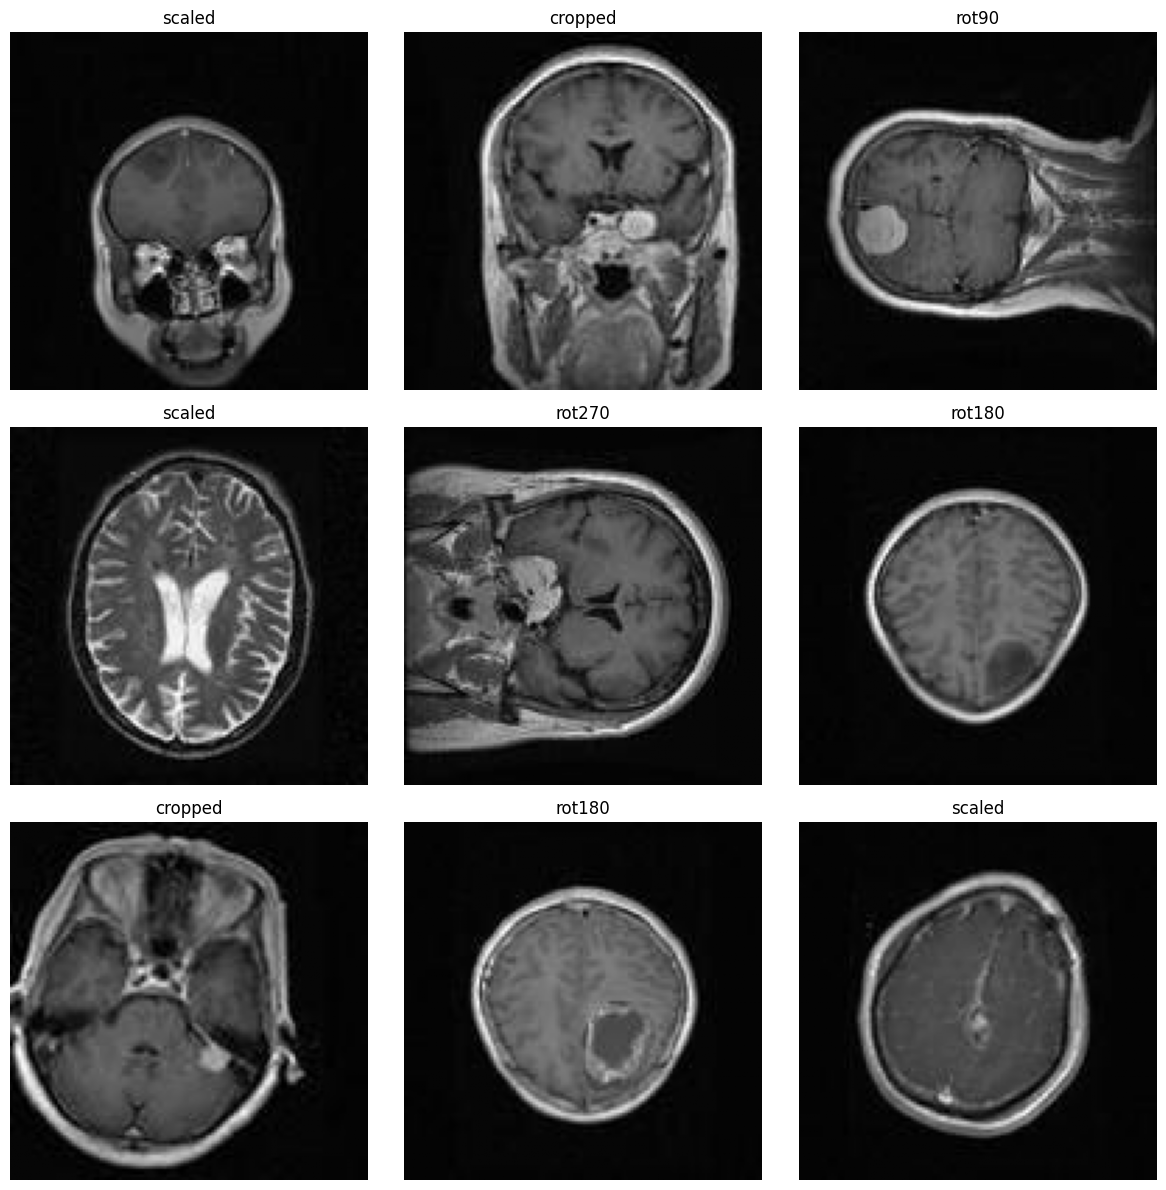

Sample augmented image dimensions: (128, 128)


In [ ]:
current_augmented_train_path = os.path.join(project_dir, 'preprocessed', 'data_augmentation', 'train')

plt.figure(figsize=(12, 12))
augmented_files = [f for f in os.listdir(current_augmented_train_path) if f.endswith('.jpg')]
random.shuffle(augmented_files) # Mezclar para ver una variedad de aumentaciones
display_limit = min(9, len(augmented_files))

for i in range(display_limit):
    image_file_name = augmented_files[i]
    image_path_from_disk = os.path.join(current_augmented_train_path, image_file_name)
    img = Image.open(image_path_from_disk)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(image_file_name.split('_')[-1].split('.')[0]) # Muestra el tipo de aumento
    plt.axis('off')

plt.tight_layout()
plt.show()

sample_image_file_name = augmented_files[0]
sample_image_path = os.path.join(current_augmented_train_path, sample_image_file_name)
sample_img = Image.open(sample_image_path)
print(f"Sample augmented image dimensions: {sample_img.size}")

La etapa de preprocesamiento ha sido fundamental para transformar nuestro conjunto de datos de imágenes MRI de cerebros en un formato óptimo para el entrenamiento de modelos de aprendizaje profundo. A través de la aplicación sistemática de diversas técnicas, hemos logrado abordar las heterogeneidades inherentes a las imágenes médicas, mejorando significativamente su calidad y uniformidad.

Específicamente, el **redimensionamiento uniforme y el recorte de la región central** a 128x128 píxeles, junto con la **conversión a escala de grises**, han estandarizado las dimensiones y el formato de todas las imágenes. Esta homogeneización no solo optimiza la eficiencia computacional al alimentar la red neuronal con entradas de tamaño consistente, sino que también ayuda a enfocar el modelo en las regiones de interés clave, reduciendo la influencia de información irrelevante o ruidosa en los bordes de las imágenes.

La **normalización de intensidades de píxeles** aseguró que los rangos de valores de intensidad fueran consistentes entre todas las imágenes, mitigando las variaciones causadas por diferentes adquisiciones de MRI. Este paso es crítico para la estabilidad del entrenamiento de redes neuronales, ya que evita que características con valores más altos dominen el proceso de optimización. Paralelamente, la **mejora de contraste mediante CLAHE** realzó los detalles sutiles y las estructuras de bajo contraste dentro de las imágenes, lo cual es invaluable para la visibilidad de los tumores y sus características morfológicas, permitiendo al modelo aprender patrones más discriminativos.

Finalmente, la implementación del **aumento de datos** ha enriquecido exponencialmente nuestro conjunto de entrenamiento. Al generar múltiples variaciones de cada imagen original mediante rotaciones, escalados y recortes aleatorios, hemos ampliado la diversidad del dataset. Esta estrategia es crucial para mejorar la capacidad de generalización del modelo, reducir el riesgo de sobreajuste y hacer que el modelo sea más robusto a las variaciones que pueda encontrar en datos no vistos en un entorno clínico real. Aunque para este proyecto se guardaron las imágenes aumentadas en disco para demostración, la metodología ideal en un pipeline de entrenamiento a gran escala sería aplicar estas transformaciones al vuelo.

En conjunto, estas técnicas de preprocesamiento no solo han preparado los datos para un consumo eficiente por parte de las arquitecturas de aprendizaje profundo, sino que también han mejorado la calidad de las características visuales que el modelo utilizará para la clasificación. Con un conjunto de datos estandarizado, normalizado, con contraste optimizado y aumentado, estamos en una posición sólida para proceder con la fase de construcción y entrenamiento de nuestros modelos de clasificación de tumores cerebrales, esperando obtener un rendimiento robusto y preciso.

## E. Modelos y ajuste de hiperparmetros

### Modelos fundacionales

#### Generación de embeddings

Vamos a aprovechar el modelo fundacional de Meta DINOv2 para poder obtener una representación compacta de nuestros datos preprocesados para generar embeddings que se puedan entrenar con machine learning clásico

In [ ]:
def cargar_y_preparar_imagen(path, size=(224, 224)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size, resample=Image.BILINEAR)
    img_np = np.asarray(img).astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)  # [C, H, W]

    # Normalizar como DINOv2
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = (img_tensor - mean) / std

    return img_tensor.unsqueeze(0)

def get_embeddings_dinov2(model, source_dir, output_file="embeddings.npy"):
    # Cargar modelo DINOv2 ViT-B/14
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Model loaded to {device}")

    # Lista de imágenes válidas
    image_files = sorted([f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
    n = len(image_files)
    print(f"Found {n} valid images")

    # Preasignar espacio en archivo .npy (memmap para eficiencia)
    embeddings_array = np.lib.format.open_memmap(output_file, dtype=np.float32, mode='w+', shape=(n, 768))

    for i, filename in enumerate(image_files):
        path = os.path.join(source_dir, filename)
        input_tensor = cargar_y_preparar_imagen(path).to(device)

        with torch.no_grad():
            embedding = model(input_tensor)  # [1, 768]
        embeddings_array[i] = embedding.squeeze(0).cpu().numpy()

    print(f"✅ Embeddings guardados en: {output_file}")
    return embeddings_array

In [ ]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 180MB/s]


In [ ]:
#Ruta con datos preprocesados
current_augmented_train_path = os.path.join(preprocessed_base_path, 'data_augmentation', 'train')
#Salida con embeddings
target_path = os.path.join(preprocessed_base_path, 'train_embeddinngs_dinov2.npy')
#Generacion de embeddings
embeddings = get_embeddings_dinov2(model, current_augmented_train_path, output_file=target_path)

Model loaded to cuda
Found 15344 valid images
✅ Embeddings guardados en: /content/drive/Shareddrives/ISI-proj/preprocessed/train_embeddinngs_dinov2.npy


In [ ]:
#Ruta con datos preprocesados
current_preprocessed_test_path = os.path.join(preprocessed_base_path, 'pixel_intensity_normalization', 'test')
#Salida con embeddings
target_path = os.path.join(preprocessed_base_path, 'test_embeddinngs_dinov2.npy')
#Generacion de embeddings
embeddings = get_embeddings_dinov2(model, current_preprocessed_test_path, output_file=target_path)

Model loaded to cuda
Found 1305 valid images
✅ Embeddings guardados en: /content/drive/Shareddrives/ISI-proj/preprocessed/test_embeddinngs_dinov2.npy


#### Uso y aplicación de embeddings

Ahora podemos cargar estos embeddings y utlizarlos en nuestra tarea de machine learning

In [ ]:
X = np.load(os.path.join(preprocessed_base_path, 'train_embeddinngs_dinov2.npy'))
X_test = np.load(os.path.join(preprocessed_base_path, 'test_embeddinngs_dinov2.npy'))

In [ ]:
train_df = pd.read_csv(os.path.join(dataset_path, 'train_labels.csv'))
source_dir = os.path.join(preprocessed_base_path, 'data_augmentation', 'train')
X_ids = sorted([f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
X_ids_cropped = list(map(lambda x: x.split('_')[0]+'.jpg', X_ids))
expanded_df = pd.DataFrame({
    'filename': X_ids,
    'id': X_ids_cropped
})
final_df = expanded_df.merge(train_df, on='id', how='left')
y = final_df['label']

In [ ]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'X_test shape: {X_test.shape}')

X shape: (15344, 768)
y shape: (15344,)
X_test shape: (1305, 768)


Ahora podemos probar distintos alggoritmos de aprendizaje de máquina para resolver nuestra tarea. Nos enfocaremos en usar:

* **XGBBoost:** Algoritmo de boosting que entrena árboles de decisión en secuencia para corregir los errores de modelos anteriores.
* **GaussianNB:** Clasificador probabilístico que asume independencia entre las características y que estas siguen una distribución normal.
* **Support Vector Machine (SVM):** Es un algoritmo de clasificación y regresión que encuentra el hiperplano óptimo que separa las clases en el espacio de características. Puede usar kernels para manejar relaciones no lineales, transformando los datos a un espacio de mayor dimensión donde la separación es lineal.
* **K-Nearest-Neighbours:** Algoritmo basado en instancias que clasifica un dato según los k vecinos más cercanos en el espacio de características.

Para la implementación, vamos a tener en cuenta la exploracion de hiperparametros usando GridSearchCV, normalizacion de datos usando StandardScaler y codificacion de etiquetas usando LabelEncoder.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

r = joblib.dump(label_encoder, os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
print(f'Label encoder saved in {r[0]}')

Label encoder saved in /content/drive/Shareddrives/ISI-proj/preprocessed/label_encoder.pkl


In [ ]:
def contestScore_(y_true, y_pred):
  return (accuracy_score(y_true, y_pred) + recall_score(y_true, y_pred, average='macro'))/2

contestScore = make_scorer(contestScore_, greater_is_better=True)

In [ ]:
@register_keras_serializable()
class ContestScore(Metric):
    def __init__(self, name='contest_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.accuracy = tf.keras.metrics.SparseCategoricalAccuracy()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(y_true, tf.int64)
        y_pred_classes = tf.cast(y_pred_classes, tf.int64)

        self.accuracy.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred_classes, sample_weight)

    def result(self):
        return (self.accuracy.result() + self.recall.result()) / 2.0

    def reset_states(self):
        self.accuracy.reset_states()
        self.recall.reset_states()

##### KNN

Entrenamos el modelo KNN

In [ ]:
knn = KNeighborsClassifier()
params = {
    'n_neighbors': [3, 9, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
grid_search_knn = GridSearchCV(knn, params, cv=5, scoring=contestScore,
                               verbose=2)
grid_search_knn.fit(X_scaled, y_encoded)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=  52.7s
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=  47.6s
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=  47.8s
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=  47.8s
[CV] END ................n_neighbors=3, p=1, weights=uniform; total time=  48.4s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=  46.1s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=  47.7s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=  51.0s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=  47.8s
[CV] END ...............n_neighbors=3, p=1, weights=distance; total time=  46.9s
[CV] END ................n_neighbors=3, p=2, weights=uniform; total time=   3.5s
[CV] END ................n_neighbors=3, p=2, wei

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 9, 15], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring=make_scorer(contestScore, response_method='predict'),
             verbose=2)

In [ ]:
pd.DataFrame(grid_search_knn.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.038686,0.024412,48.825379,1.919452,3,1,uniform,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}",0.875259,0.878759,0.886008,0.885286,0.868875,0.878838,0.006404,3
1,0.030221,0.017503,47.871297,1.641896,3,1,distance,"{'n_neighbors': 3, 'p': 1, 'weights': 'distance'}",0.876207,0.880547,0.888036,0.890045,0.868547,0.880676,0.007862,2
2,0.021674,0.002478,2.463329,0.513964,3,2,uniform,"{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}",0.875115,0.880401,0.885006,0.884829,0.867864,0.878643,0.006488,4
3,0.021415,0.001644,2.569184,0.456483,3,2,distance,"{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}",0.877191,0.883534,0.887076,0.891557,0.870566,0.881985,0.007393,1
4,0.025354,0.003355,48.015018,1.392555,9,1,uniform,"{'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}",0.859116,0.862164,0.866854,0.868063,0.846836,0.860606,0.007601,7


In [ ]:
print("Mejores parámetros:", grid_search_knn.best_params_)
print("Mejor score:", grid_search_knn.best_score_)

Mejores parámetros: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Mejor score: 0.8819847753728617


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', grid_search_knn.best_estimator_)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineKNN.pkl'))
print(f'KNN pipeline saved at {r[0]}')

KNN pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineKNN.pkl


##### GNB

Entrenamos ahora el modelo Naive-Bayes Gaussiano

In [ ]:
gnb = GaussianNB()
params =  {
    'var_smoothing': [0, 1e-8, 1e-6, 1e-4, 1e-2, 1]

}
grid_search_gnb = GridSearchCV(gnb, params, cv=5, scoring=contestScore,
                               verbose=2)
grid_search_gnb.fit(X_scaled, y_encoded)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ....................................var_smoothing=0; total time=   0.2s
[CV] END ....................................var_smoothing=0; total time=   0.2s
[CV] END ....................................var_smoothing=0; total time=   0.2s
[CV] END ....................................var_smoothing=0; total time=   0.2s
[CV] END ....................................var_smoothing=0; total time=   0.3s
[CV] END ................................var_smoothing=1e-08; total time=   0.2s
[CV] END ................................var_smoothing=1e-08; total time=   0.3s
[CV] END ................................var_smoothing=1e-08; total time=   0.2s
[CV] END ................................var_smoothing=1e-08; total time=   0.2s
[CV] END ................................var_smoothing=1e-08; total time=   0.2s
[CV] END ................................var_smoothing=1e-06; total time=   0.2s
[CV] END ................................var_smoo

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [0, 1e-08, 1e-06, 0.0001, 0.01, 1]},
             scoring=make_scorer(contestScore, response_method='predict'),
             verbose=2)

In [ ]:
pd.DataFrame(grid_search_gnb.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_var_smoothing,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.127842,0.025553,0.106845,0.008319,0.000000e+00,{'var_smoothing': 0},0.752047,0.74167,0.732710,0.734088,0.721342,0.736371,0.010181,1
1,0.109036,0.006460,0.111628,0.013794,1.000000e-08,{'var_smoothing': 1e-08},0.752047,0.74167,0.732710,0.734088,0.721342,0.736371,0.010181,1
2,0.115185,0.012786,0.106292,0.019193,1.000000e-06,{'var_smoothing': 1e-06},0.752047,0.74167,0.732710,0.734088,0.721342,0.736371,0.010181,1
3,0.086693,0.005619,0.073468,0.001883,1.000000e-04,{'var_smoothing': 0.0001},0.752047,0.74167,0.732710,0.734088,0.721342,0.736371,0.010181,1
4,0.083264,0.002605,0.074078,0.004277,1.000000e-02,{'var_smoothing': 0.01},0.752372,0.73857,0.731966,0.733041,0.722283,0.735646,0.009871,5


In [ ]:
print("Mejores parámetros:", grid_search_gnb.best_params_)
print("Mejor score:", grid_search_gnb.best_score_)

Mejores parámetros: {'var_smoothing': 0}
Mejor score: 0.7363713688442172


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', grid_search_gnb.best_estimator_)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineGNB.pkl'))
print(f'GNB pipeline saved at {r[0]}')

GNB pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineGNB.pkl


##### Support Vector Machine

Dado que entrenar un support vector machine depende del kernel para saber que hiperparámetros explorar

###### Kernel Lineal

In [ ]:
svc_linear = SVC(kernel='linear')
params_linear = {
    'C': [0.1, 0.5, 1, 10, 100, 1000]
}
grid_linear = GridSearchCV(
    svc_linear, params_linear,
    cv=5, scoring=contestScore,
    n_jobs=1, verbose=2
)
grid_linear.fit(X_scaled, y_encoded)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..............................................C=0.1; total time=  20.6s
[CV] END ..............................................C=0.1; total time=  15.7s
[CV] END ..............................................C=0.1; total time=  15.9s
[CV] END ..............................................C=0.1; total time=  16.2s
[CV] END ..............................................C=0.1; total time=  15.0s
[CV] END ..............................................C=0.5; total time=  15.6s
[CV] END ..............................................C=0.5; total time=  15.8s
[CV] END ..............................................C=0.5; total time=  16.1s
[CV] END ..............................................C=0.5; total time=  17.0s
[CV] END ..............................................C=0.5; total time=  15.4s
[CV] END ................................................C=1; total time=  15.6s
[CV] END ........................................

GridSearchCV(cv=5, estimator=SVC(kernel='linear'), n_jobs=1,
             param_grid={'C': [0.1, 0.5, 1, 10, 100, 1000]},
             scoring=make_scorer(contestScore, response_method='predict'),
             verbose=2)

In [ ]:
pd.DataFrame(grid_linear.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,14.849564,2.072256,1.856709,0.173933,0.1,{'C': 0.1},0.910422,0.930417,0.935429,0.927963,0.903416,0.921529,0.012370,1
1,14.132586,0.344239,1.846824,0.270965,0.5,{'C': 0.5},0.907077,0.926087,0.932794,0.918893,0.904127,0.917796,0.010924,2
2,14.229115,0.320666,1.903191,0.310039,1.0,{'C': 1},0.907077,0.926087,0.932794,0.918893,0.904127,0.917796,0.010924,2
3,14.170352,0.420171,1.985876,0.219921,10.0,{'C': 10},0.907077,0.926087,0.932794,0.918893,0.904127,0.917796,0.010924,2
4,15.389791,2.307385,1.745145,0.058946,100.0,{'C': 100},0.907077,0.926087,0.932794,0.918893,0.904127,0.917796,0.010924,2


In [ ]:
print("Mejores parámetros:", grid_linear.best_params_)
print("Mejor score:", grid_linear.best_score_)

Mejores parámetros: {'C': 0.1}
Mejor score: 0.9215291551365008


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', grid_linear.best_estimator_)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineSVC_linear.pkl'))
print(f'SVC pipeline saved at {r[0]}')

SVC pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineSVC_linear.pkl


###### Kernel RBF

In [ ]:
svc_rbf = SVC(kernel='rbf')
params_rbf = {
    'C': [0.1, 1, 10, 20],
    'gamma': ['scale', 'auto']
}
grid_rbf = GridSearchCV(
    svc_rbf, params_rbf,
    cv=5, scoring=contestScore,
    n_jobs=1, verbose=2
)
grid_rbf.fit(X_scaled, y_encoded)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .................................C=0.1, gamma=scale; total time= 1.3min
[CV] END .................................C=0.1, gamma=scale; total time= 1.3min
[CV] END .................................C=0.1, gamma=scale; total time= 1.2min
[CV] END .................................C=0.1, gamma=scale; total time= 1.2min
[CV] END .................................C=0.1, gamma=scale; total time= 1.2min
[CV] END ..................................C=0.1, gamma=auto; total time= 1.2min
[CV] END ..................................C=0.1, gamma=auto; total time= 1.2min
[CV] END ..................................C=0.1, gamma=auto; total time= 1.2min
[CV] END ..................................C=0.1, gamma=auto; total time= 1.2min
[CV] END ..................................C=0.1, gamma=auto; total time= 1.2min
[CV] END ...................................C=1, gamma=scale; total time=  44.5s
[CV] END ...................................C=1, 

GridSearchCV(cv=5, estimator=SVC(), n_jobs=1,
             param_grid={'C': [0.1, 1, 10, 20], 'gamma': ['scale', 'auto']},
             scoring=make_scorer(contestScore, response_method='predict'),
             verbose=2)

In [ ]:
pd.DataFrame(grid_rbf.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,55.203868,2.945465,19.010062,0.381081,0.1,scale,"{'C': 0.1, 'gamma': 'scale'}",0.875402,0.882863,0.878633,0.876692,0.869775,0.876673,0.004275,8
1,52.729368,0.399270,18.879231,0.275748,0.1,auto,"{'C': 0.1, 'gamma': 'auto'}",0.875402,0.882863,0.878633,0.877036,0.869775,0.876742,0.004277,7
2,31.144364,0.187868,13.402766,0.145549,1.0,scale,"{'C': 1, 'gamma': 'scale'}",0.936210,0.947257,0.940815,0.949879,0.917313,0.938295,0.011536,5
3,31.092761,0.239054,13.772028,0.416050,1.0,auto,"{'C': 1, 'gamma': 'auto'}",0.936210,0.947257,0.940815,0.949879,0.916643,0.938161,0.011780,6
4,30.252816,0.475877,13.165944,0.184484,10.0,scale,"{'C': 10, 'gamma': 'scale'}",0.945208,0.953024,0.948222,0.955121,0.926155,0.945546,0.010304,1


In [ ]:
print("Mejores parámetros:", grid_rbf.best_params_)
print("Mejor score:", grid_rbf.best_score_)

Mejores parámetros: {'C': 10, 'gamma': 'scale'}
Mejor score: 0.9455461996563205


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', grid_rbf.best_estimator_)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineSVC_RBF.pkl'))
print(f'SVC pipeline saved at {r[0]}')

SVC pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineSVC_RBF.pkl


###### Polynomial

In [ ]:
svc_poly = SVC(kernel='poly')

params_poly = {
    'C': [0.1, 10],                     # regularización
    'gamma': ['scale', 'auto'],         # coeficiente de kernel
    'degree': [2, 4, 6],                # grado del polinomio
    'coef0': [0.0, 1.0]                 # término independiente (bias)
}

grid_poly = GridSearchCV(
    svc_poly, params_poly,
    cv=5, scoring=contestScore,
    n_jobs=1, verbose=2
)

grid_poly.fit(X_scaled, y_encoded)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ............C=0.1, coef0=0.0, degree=2, gamma=scale; total time= 1.4min
[CV] END ............C=0.1, coef0=0.0, degree=2, gamma=scale; total time= 1.4min
[CV] END ............C=0.1, coef0=0.0, degree=2, gamma=scale; total time= 1.4min
[CV] END ............C=0.1, coef0=0.0, degree=2, gamma=scale; total time= 1.4min
[CV] END ............C=0.1, coef0=0.0, degree=2, gamma=scale; total time= 1.4min
[CV] END .............C=0.1, coef0=0.0, degree=2, gamma=auto; total time= 1.4min
[CV] END .............C=0.1, coef0=0.0, degree=2, gamma=auto; total time= 1.4min
[CV] END .............C=0.1, coef0=0.0, degree=2, gamma=auto; total time= 1.4min
[CV] END .............C=0.1, coef0=0.0, degree=2, gamma=auto; total time= 1.4min
[CV] END .............C=0.1, coef0=0.0, degree=2, gamma=auto; total time= 1.4min
[CV] END ............C=0.1, coef0=0.0, degree=4, gamma=scale; total time= 2.0min
[CV] END ............C=0.1, coef0=0.0, degree=4

GridSearchCV(cv=5, estimator=SVC(kernel='poly'), n_jobs=1,
             param_grid={'C': [0.1, 10], 'coef0': [0.0, 1.0],
                         'degree': [2, 4, 6], 'gamma': ['scale', 'auto']},
             scoring=make_scorer(contestScore, response_method='predict'),
             verbose=2)

In [ ]:
pd.DataFrame(grid_poly.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_coef0,param_degree,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,69.052556,0.898571,15.569578,0.301254,0.1,0.0,2,scale,"{'C': 0.1, 'coef0': 0.0, 'degree': 2, 'gamma':...",0.856174,0.864529,0.870729,0.858625,0.854153,0.860842,0.006047,19
1,70.150609,1.095003,15.527615,0.190502,0.1,0.0,2,auto,"{'C': 0.1, 'coef0': 0.0, 'degree': 2, 'gamma':...",0.856174,0.864529,0.870729,0.858625,0.854153,0.860842,0.006047,19
2,104.997032,1.502974,18.362407,0.436221,0.1,0.0,4,scale,"{'C': 0.1, 'coef0': 0.0, 'degree': 4, 'gamma':...",0.802886,0.805413,0.818102,0.810248,0.791444,0.805619,0.008783,22
3,105.920135,2.721756,18.474180,0.331114,0.1,0.0,4,auto,"{'C': 0.1, 'coef0': 0.0, 'degree': 4, 'gamma':...",0.802902,0.807145,0.818086,0.810585,0.790425,0.805829,0.009170,21
4,121.836799,3.282429,20.491540,0.584664,0.1,0.0,6,scale,"{'C': 0.1, 'coef0': 0.0, 'degree': 6, 'gamma':...",0.561872,0.586141,0.573807,0.580879,0.553797,0.571299,0.011946,23


In [ ]:
print("Mejores parámetros:", grid_poly.best_params_)
print("Mejor score:", grid_poly.best_score_)

Mejores parámetros: {'C': 10, 'coef0': 1.0, 'degree': 4, 'gamma': 'scale'}
Mejor score: 0.9449372833229072


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', grid_poly.best_estimator_)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineSVC_polynomial.pkl'))
print(f'SVC pipeline saved at {r[0]}')

SVC pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineSVC_polynomial.pkl


##### XGB

In [ ]:
xgb = XGBClassifier(eval_metric='mlogloss', learning_rate=0.01)

params= {
    'n_estimators': [200, 150, 100],
    'max_depth': [7, 5, 3],                   # profundidad máxima de cada árbol
    'reg_lambda': [1, 2]                      # regularización L2
}

grid_xgb = GridSearchCV(
    xgb, params,
    cv=5, scoring=contestScore,
    n_jobs=1, verbose=2
)

grid_xgb.fit(X_scaled, y_encoded)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=1; total time= 8.4min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=1; total time= 8.7min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=1; total time= 8.7min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=1; total time= 8.7min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=1; total time= 8.4min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=2; total time= 8.5min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=2; total time= 8.6min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=2; total time= 8.7min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=2; total time= 8.7min
[CV] END ........max_depth=7, n_estimators=200, reg_lambda=2; total time= 8.4min
[CV] END ........max_depth=7, n_estimators=150, reg_lambda=1; total time= 6.2min
[CV] END ........max_depth=7, n_estimators=150, 

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=1,
             param_grid={'max_depth': [7, 5, 3],
                         'n_estimators': [200, 150, 100],
                         'reg_lambda': [1, 2]},
             scoring=make_scorer(contestScore, response_method='predict'),
             verbose=2)

In [ ]:
pd.DataFrame(grid_xgb.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,param_reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,515.045674,9.639735,0.173770,0.037207,7,200,1,"{'max_depth': 7, 'n_estimators': 200, 'reg_lam...",0.840730,0.840992,0.848254,0.854238,0.853355,0.847514,0.005804,1
1,515.353024,6.751788,0.148733,0.011022,7,200,2,"{'max_depth': 7, 'n_estimators': 200, 'reg_lam...",0.837760,0.844325,0.847744,0.852899,0.852566,0.847059,0.005636,2
2,382.929968,6.263913,0.132110,0.032651,7,150,1,"{'max_depth': 7, 'n_estimators': 150, 'reg_lam...",0.832957,0.835261,0.838182,0.840192,0.841608,0.837640,0.003167,3
3,382.100396,5.472020,0.102196,0.002898,7,150,2,"{'max_depth': 7, 'n_estimators': 150, 'reg_lam...",0.832318,0.832408,0.836481,0.841959,0.843652,0.837364,0.004722,4
4,254.579206,3.347479,0.073608,0.007113,7,100,1,"{'max_depth': 7, 'n_estimators': 100, 'reg_lam...",0.821825,0.823093,0.826416,0.822938,0.833403,0.825535,0.004223,5


In [ ]:
print("Mejores parámetros:", grid_xgb.best_params_)
print("Mejor score:", grid_xgb.best_score_)

Mejores parámetros: {'max_depth': 7, 'n_estimators': 200, 'reg_lambda': 1}
Mejor score: 0.8475137616107963


In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', grid_xgb.best_estimator_)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineXGB.pkl'))
print(f'XGB pipeline saved at {r[0]}')

XGB pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineXGB.pkl


Como vemos que el mejor modelo al explorar los parametros, fue aquel que tuvo la regularización más baja y la mayor profundidad y numero de estimadores, podemos suponer que estamos en un escenario de underfitting. Dado esto, entrenaremos un modelo mucho más grande con un valor de regularización L1 de 0.5.

In [ ]:
def format_time(ms):
    minutes = ms // 60000
    seconds = (ms % 60000) // 1000
    milliseconds = ms % 1000
    return f"{minutes:02d}m {seconds:02d}s {milliseconds:03d}ms"

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled, y_encoded), 1):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    model = XGBClassifier(
        eval_metric='mlogloss',
        learning_rate=0.3,
        reg_lambda=0.5,
        n_estimators=1000,
        max_depth=3,
        verbosity=0
    )
    start = time.time() * 1000
    model.fit(X_train, y_train)
    end = time.time() * 1000
    t = format_time(int(end - start))
    y_pred = model.predict(X_val)

    score = contestScore_(y_val, y_pred)
    print(f"Fold {fold} - contestScore: {score:.4f} - Time: {t}")
    scores.append(score)

print(f"\nMean contestScore: {np.mean(scores):.4f}")

Fold 1 - contestScore: 0.9490 - Time: 05m 57s 751ms
Fold 2 - contestScore: 0.9583 - Time: 05m 34s 510ms
Fold 3 - contestScore: 0.9591 - Time: 05m 37s 924ms
Fold 4 - contestScore: 0.9569 - Time: 05m 41s 477ms
Fold 5 - contestScore: 0.9534 - Time: 05m 37s 528ms

Mean contestScore: 0.9554


In [ ]:
large_XGB = XGBClassifier(eval_metric='mlogloss',
                          learning_rate=0.3,
                          reg_lambda=0.5,
                          n_estimators=1000,
                          max_depth=3,
                          verbosity = 2)
large_XGB.fit(X_scaled, y_encoded,
              eval_set=[(X_scaled, y_encoded)],
              verbose = True)

[0]	validation_0-mlogloss:1.15158
[1]	validation_0-mlogloss:1.00485
[2]	validation_0-mlogloss:0.90097
[3]	validation_0-mlogloss:0.81853
[4]	validation_0-mlogloss:0.75425
[5]	validation_0-mlogloss:0.69990
[6]	validation_0-mlogloss:0.65611
[7]	validation_0-mlogloss:0.61896
[8]	validation_0-mlogloss:0.58662
[9]	validation_0-mlogloss:0.55842
[10]	validation_0-mlogloss:0.53431
[11]	validation_0-mlogloss:0.51176
[12]	validation_0-mlogloss:0.49157
[13]	validation_0-mlogloss:0.47136
[14]	validation_0-mlogloss:0.45474
[15]	validation_0-mlogloss:0.43946
[16]	validation_0-mlogloss:0.42531
[17]	validation_0-mlogloss:0.41269
[18]	validation_0-mlogloss:0.40035
[19]	validation_0-mlogloss:0.38901
[20]	validation_0-mlogloss:0.37814
[21]	validation_0-mlogloss:0.36777
[22]	validation_0-mlogloss:0.35807
[23]	validation_0-mlogloss:0.34868
[24]	validation_0-mlogloss:0.33990
[25]	validation_0-mlogloss:0.33121
[26]	validation_0-mlogloss:0.32307
[27]	validation_0-mlogloss:0.31601
[28]	validation_0-mlogloss:0.3

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
pipeline = Pipeline([
    ('scaler', scaler),
    ('model', large_XGB)
])

In [ ]:
r = joblib.dump(pipeline, os.path.join(models_path, 'pipelineLargeXGB.pkl'))
print(f'Largest XGB pipeline saved at {r[0]}')

Largest XGB pipeline saved at /content/drive/Shareddrives/ISI-proj/models/pipelineLargeXGB.pkl


##### Red Neuronal

In [ ]:
model = Sequential(
    [
        Input(shape=(768,)),
        Dense(1024, activation='relu'),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(4, activation='softmax')
    ]
)

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=[ContestScore()]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 1024)           │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,444,612 (5.51 MB)

 Trainable params: 1,444,612 (5.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_contest_score',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(models_path, 'best_model_embedding.keras'),
        monitor='val_contest_score',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=0
    )
]

history = model.fit(
    X_scaled, y_encoded,
    validation_split=0.2,
    batch_size=32,
    epochs=200,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/200
384/384 - 5s - 12ms/step - contest_score: 0.6699 - loss: 1.2948 - val_contest_score: 0.7376 - val_loss: 1.1627 - learning_rate: 1.0000e-06
Epoch 2/200
384/384 - 1s - 3ms/step - contest_score: 0.7751 - loss: 1.0353 - val_contest_score: 0.7788 - val_loss: 0.9848 - learning_rate: 1.0000e-06
Epoch 3/200
384/384 - 1s - 4ms/step - contest_score: 0.8098 - loss: 0.8806 - val_contest_score: 0.8066 - val_loss: 0.8614 - learning_rate: 1.0000e-06
Epoch 4/200
384/384 - 1s - 4ms/step - contest_score: 0.8326 - loss: 0.7700 - val_contest_score: 0.8253 - val_loss: 0.7697 - learning_rate: 1.0000e-06
Epoch 5/200
384/384 - 3s - 7ms/step - contest_score: 0.8490 - loss: 0.6873 - val_contest_score: 0.8420 - val_loss: 0.6998 - learning_rate: 1.0000e-06
Epoch 6/200
384/384 - 1s - 4ms/step - contest_score: 0.8673 - loss: 0.6236 - val_contest_score: 0.8556 - val_loss: 0.6448 - learning_rate: 1.0000e-06
Epoch 7/200
384/384 - 2s - 4ms/step - contest_score: 0.8795 - loss: 0.5730 - val_contest_score: 0.8

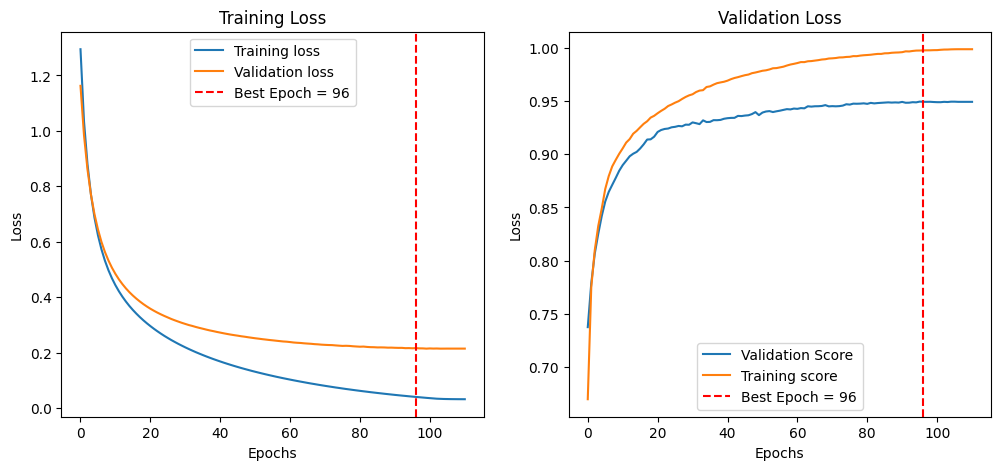

In [ ]:
best_epoch = callbacks[0].stopped_epoch - callbacks[0].patience + 1
plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
plt.plot(history.history['loss'], label=f'Training loss')
plt.plot(history.history['val_loss'], label=f'Validation loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch = {best_epoch}')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2, 2)
plt.plot(history.history['val_contest_score'], label=f'Validation Score')
plt.plot(history.history['contest_score'], label = f'Training score')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch = {best_epoch}')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.save(os.path.join(models_path, 'model_embedding.keras'))
r = joblib.dump(scaler, os.path.join(preprocessed_base_path, 'scaler.pkl'))
print(f'Neuronal network with embeddings saved at\n{r[0]}\n{os.path.join(models_path, "model_embedding.keras")}')

Neuronal network with embeddings saved at
/content/drive/Shareddrives/ISI-proj/preprocessed/scaler.pkl
/content/drive/Shareddrives/ISI-proj/models/model_embedding.keras


In [ ]:
model2 = Sequential([
    Input(shape=(768,)),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=[ContestScore()]
)

model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 1024)           │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,903,044 (11.07 MB)

 Trainable params: 2,896,900 (11.05 MB)

 Non-trainable params: 6,144 (24.00 KB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_contest_score',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(models_path, 'best_model2_embedding.keras'),
        monitor='val_contest_score',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=0
    )
]

history = model2.fit(
    X_scaled, y_encoded,
    validation_split=0.1,
    batch_size=32,
    epochs=200,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/200
432/432 - 10s - 24ms/step - contest_score: 0.5591 - loss: 1.7803 - val_contest_score: 0.7137 - val_loss: 1.1243 - learning_rate: 1.0000e-06
Epoch 2/200
432/432 - 2s - 4ms/step - contest_score: 0.6401 - loss: 1.4197 - val_contest_score: 0.7801 - val_loss: 0.8856 - learning_rate: 1.0000e-06
Epoch 3/200
432/432 - 3s - 7ms/step - contest_score: 0.6921 - loss: 1.2059 - val_contest_score: 0.8158 - val_loss: 0.7608 - learning_rate: 1.0000e-06
Epoch 4/200
432/432 - 2s - 4ms/step - contest_score: 0.7238 - loss: 1.0931 - val_contest_score: 0.8429 - val_loss: 0.6788 - learning_rate: 1.0000e-06
Epoch 5/200
432/432 - 2s - 4ms/step - contest_score: 0.7432 - loss: 1.0150 - val_contest_score: 0.8605 - val_loss: 0.6225 - learning_rate: 1.0000e-06
Epoch 6/200
432/432 - 2s - 4ms/step - contest_score: 0.7642 - loss: 0.9282 - val_contest_score: 0.8711 - val_loss: 0.5787 - learning_rate: 1.0000e-06
Epoch 7/200
432/432 - 3s - 6ms/step - contest_score: 0.7773 - loss: 0.8764 - val_contest_score: 0.

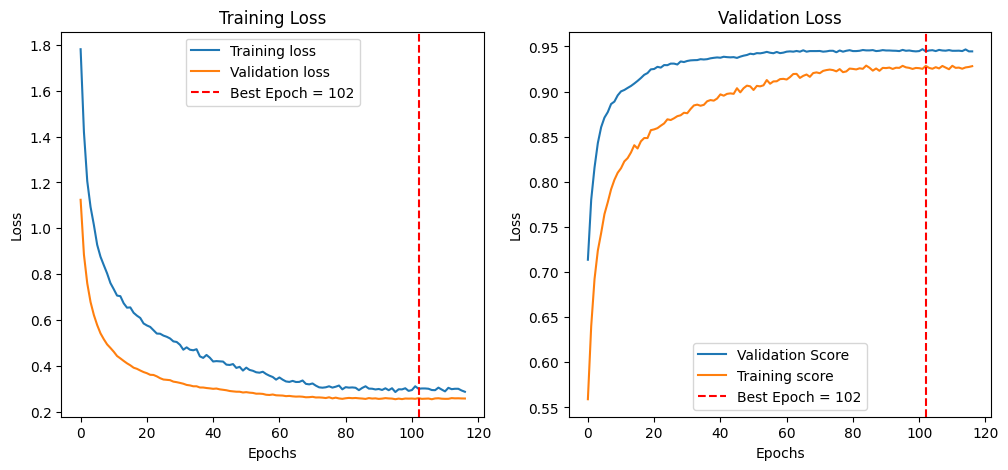

In [ ]:
best_epoch = callbacks[0].stopped_epoch - callbacks[0].patience + 1
plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
plt.plot(history.history['loss'], label=f'Training loss')
plt.plot(history.history['val_loss'], label=f'Validation loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch = {best_epoch}')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2, 2)
plt.plot(history.history['val_contest_score'], label=f'Validation Score')
plt.plot(history.history['contest_score'], label = f'Training score')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch = {best_epoch}')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model2.save(os.path.join(models_path, 'model2_embedding.keras'))
r = joblib.dump(scaler, os.path.join(preprocessed_base_path, 'scaler.pkl'))
print(f'Neuronal network with embeddings saved at\n{r[0]}\n{os.path.join(models_path, "model2_embedding.keras")}')

Neuronal network with embeddings saved at
/content/drive/Shareddrives/ISI-proj/preprocessed/scaler.pkl
/content/drive/Shareddrives/ISI-proj/models/model2_embedding.keras


##### Ensamblaje

Como propuesta final de este modelo, vamos a generar un ensamble de los mejores modelos encontrados hasta ahora y realizaremos un proceso de votación para definir la clase definitiva. Esto inspirado en los modelos de ensamblaje como RandomForest; con la diferencia fundamental de que no son modelos completamente independientes; pero buscamos aprovechar la capacidad de aprender patrones de distintas formas de los distintos modelos.

In [ ]:
class KerasModel(BaseEstimator, ClassifierMixin):
  def __init__(self, model):
    self.model = model

  def fit(self, X, y):
    return self

  def predict(self, X):
    return np.argmax(self.model.predict(X),axis=1)

class EnsembleModel(BaseEstimator, ClassifierMixin):
    def __init__(self, models, label_encoder=None):
        self.models = models
        self.encoder = label_encoder

    def fit(self, X, y):
        return self

    def predict(self, X):
        all_preds = np.array([model.predict(X) for model in self.models])
        all_preds = all_preds.T
        maj_votes, _ = mode(all_preds, axis=1, keepdims=False)
        if self.encoder: return self.encoder.inverse_transform(maj_votes.astype(int))
        return maj_votes.astype(int)

### Modelos de aprendizaje profundo

Vamos a generar la métrica para monitorear el score de validación.

In [ ]:
@register_keras_serializable()
class ContestScore(Metric):
    def __init__(self, name='contest_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.accuracy = tf.keras.metrics.SparseCategoricalAccuracy()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(y_true, tf.int64)
        y_pred_classes = tf.cast(y_pred_classes, tf.int64)

        self.accuracy.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred_classes, sample_weight)

    def result(self):
        return (self.accuracy.result() + self.recall.result()) / 2.0

    def reset_states(self):
        self.accuracy.reset_states()
        self.recall.reset_states()

def create_test_generator(test_dir, batch_size=32, target_size=(224,224)):
    image_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    test_df = pd.DataFrame({'filename': image_files})
    test_datagen = ImageDataGenerator()
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=test_dir,
        x_col='filename',
        y_col=None,
        batch_size=batch_size,
        shuffle=False,
        class_mode=None,
        target_size=target_size
    )
    return test_generator , test_df

def generateSubmissionFromImages(model, test_data, train_data, name='submission.csv', batch_size=32,
                                 target_size=(224,224)):
    assert os.path.exists(test_data), f'{test_data} not found'
    index_to_class = {v: k for k, v in train_data.class_indices.items()}
    test_generator, test_df = create_test_generator(test_data, batch_size=batch_size, target_size=target_size)
    preds = model.predict(test_generator, verbose=1)
    predicted_class_indices = preds.argmax(axis=1)
    predicted_labels = [index_to_class[idx] for idx in predicted_class_indices]
    submission_df = pd.DataFrame({
        'id': test_df['filename'],
        'label': predicted_labels
    })
    output_path = os.path.join(submissions_path, name)
    submission_df.to_csv(output_path, index=False)
    print(f'Submission file generated at {output_path}')

def merge_histories(history1, history2):
    merged = {}
    for key in history1.history:
        merged[key] = history1.history[key] + history2.history.get(key, [])
    return merged

Generamos el dataframe de rutas de las imágenes y clases de los datos de entrenamiento para ser utilizados en los modelos.

In [ ]:
train_df = pd.read_csv(os.path.join(dataset_path, 'train_labels.csv'))
source_dir = os.path.join(preprocessed_base_path, 'data_augmentation', 'train')
X_ids = sorted([f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
X_ids_cropped = list(map(lambda x: x.split('_')[0]+'.jpg', X_ids))
expanded_df = pd.DataFrame({
    'filename': X_ids,
    'id': X_ids_cropped
})
final_df = expanded_df.merge(train_df, on='id', how='left')
train_augmented_df = final_df[['filename','label']].copy()
train_augmented_df['filename'] = train_augmented_df['filename'].apply(lambda x: str(os.path.join(source_dir, x)))
train_augmented_df.head()

,filename,label
0,/content/drive/Shareddrives/ISI-proj/preproces...,meningioma
1,/content/drive/Shareddrives/ISI-proj/preproces...,meningioma
2,/content/drive/Shareddrives/ISI-proj/preproces...,meningioma
3,/content/drive/Shareddrives/ISI-proj/preproces...,meningioma
4,/content/drive/Shareddrives/ISI-proj/preproces...,meningioma


In [ ]:
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)

    print("✅ TPU initialized.")
    print("Replicas in sync:", strategy.num_replicas_in_sync)
except Exception as e:
    print("❌ TPU not found or cannot connect:", e)
    strategy = tf.distribute.get_strategy()
print(strategy)

❌ TPU not found or cannot connect: TPUs not found in the cluster. Failed in initialization: No OpKernel was registered to support Op 'ConfigureDistributedTPU' used by {{node ConfigureDistributedTPU}} with these attrs: [tpu_cancellation_closes_chips=2, enable_whole_mesh_compilations=false, embedding_config="", tpu_embedding_config="", compilation_failure_closes_chips=false, is_global_init=false]
Registered devices: [CPU, GPU]
Registered kernels:
  <no registered kernels>

	 [[ConfigureDistributedTPU]] [Op:__inference__tpu_init_fn_4]


I0000 00:00:1752512364.985974      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752512364.986763      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Vamos a probar el uso de modelos entrenados, en particular, realizaremos fine tunning sobre los modelos Resnet101, Resnet50V2, Xception y EfficientNetB4

###### Resnet101

Para este modelo, definimos un tamaño de imagen de 224x224 con res canales en formato RGB

In [ ]:
train_df, val_df = train_test_split(
    train_augmented_df,
    test_size=0.1,
    stratify=train_augmented_df['label'],
    random_state=42
)

image_size = 224
batch_size = 32

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

Found 25731 validated image filenames belonging to 4 classes.
Found 2859 validated image filenames belonging to 4 classes.


In [ ]:
with strategy.scope():
    base_model = tf.keras.applications.ResNet101(
        weights='imagenet',
        include_top=False,
        input_shape=(image_size, image_size, 3)
    )

    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1,
    callbacks=[checkpoint, reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
  8/432 ━━━━━━━━━━━━━━━━━━━━ 3:02:12 26s/step - contest_score: 0.6611 - loss: 1.4808

In [ ]:
target_file = os.path.join(models_path, 'resnet101.keras')

checkpoint = ModelCheckpoint(target_file, monitor="val_contest_score",
                             save_best_only=True, verbose=1, mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_contest_score', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1, mode='max')

early_stopping = EarlyStopping(
    monitor='val_contest_score',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

callbacks = [checkpoint, reduce_lr, early_stopping]

In [ ]:
history_warmup = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1752487802.453096      97 service.cc:148] XLA service 0x7b4180022940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752487802.453848      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752487802.453873      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752487805.232309      97 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1752487810.567142      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of th

805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - contest_score: 0.7074 - loss: 1.0284
Epoch 1: val_contest_score improved from -inf to 0.88684, saving model to /kaggle/working/models/resnet101.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 172s 180ms/step - contest_score: 0.7075 - loss: 1.0282 - val_contest_score: 0.8868 - val_loss: 0.5137 - learning_rate: 1.0000e-04
Epoch 2/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - contest_score: 0.8649 - loss: 0.5678
Epoch 2: val_contest_score improved from 0.88684 to 0.90211, saving model to /kaggle/working/models/resnet101.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 130s 161ms/step - contest_score: 0.8649 - loss: 0.5677 - val_contest_score: 0.9021 - val_loss: 0.4225 - learning_rate: 1.0000e-04
Epoch 3/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - contest_score: 0.8818 - loss: 0.4885
Epoch 3: val_contest_score improved from 0.90211 to 0.91057, saving model to /kaggle/working/models/resnet101.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 129s 161ms/step - contest_score: 0.8818 - 

In [ ]:
with strategy.scope():
    base_model.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

In [ ]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - contest_score: 0.9177 - loss: 0.3550
Epoch 1: val_contest_score improved from 0.91977 to 0.95548, saving model to /kaggle/working/models/resnet101.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 586s 565ms/step - contest_score: 0.9178 - loss: 0.3548 - val_contest_score: 0.9555 - val_loss: 0.1252 - learning_rate: 1.0000e-05
Epoch 2/30
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - contest_score: 0.9835 - loss: 0.0802
Epoch 2: val_contest_score improved from 0.95548 to 0.98489, saving model to /kaggle/working/models/resnet101.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 414s 515ms/step - contest_score: 0.9835 - loss: 0.0802 - val_contest_score: 0.9849 - val_loss: 0.0842 - learning_rate: 1.0000e-05
Epoch 3/30
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - contest_score: 0.9952 - loss: 0.0270
Epoch 3: val_contest_score improved from 0.98489 to 0.98512, saving model to /kaggle/working/models/resnet101.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 414s 514ms/step - contest_

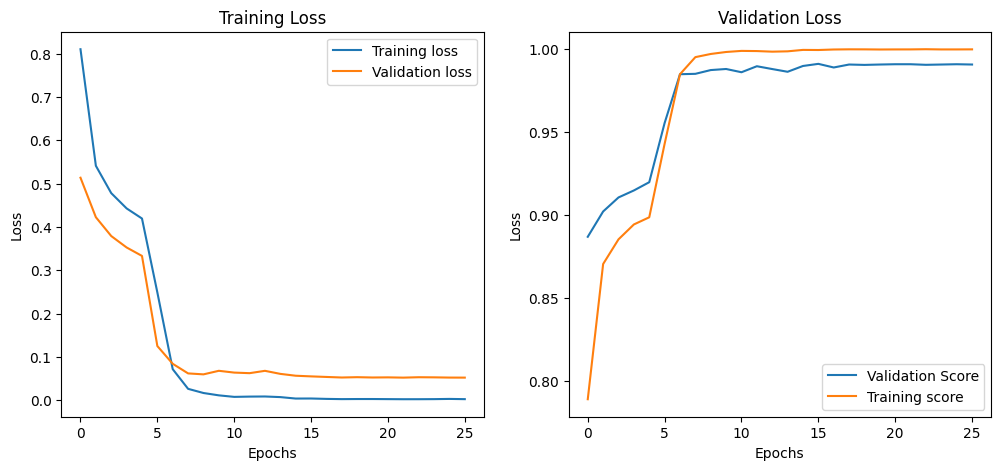

In [ ]:
history = merge_histories(history_warmup, history_finetune)
plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
plt.plot(history['loss'], label=f'Training loss')
plt.plot(history['val_loss'], label=f'Validation loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2, 2)
plt.plot(history['val_contest_score'], label=f'Validation Score')
plt.plot(history['contest_score'], label = f'Training score')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
path = os.path.join(models_path, 'modelResnet101.keras')
model.save(path)

###### ResNet 50V2

In [ ]:
train_df, val_df = train_test_split(
    train_augmented_df,
    test_size=0.1,
    stratify=train_augmented_df['label'],
    random_state=42
)

image_size = 224
batch_size = 32

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

Found 25731 validated image filenames belonging to 4 classes.
Found 2859 validated image filenames belonging to 4 classes.


In [ ]:
with strategy.scope():
    base_model = tf.keras.applications.ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(image_size, image_size, 3)
    )

    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1536, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
target_file = os.path.join(models_path, 'resnet50v2.keras')

checkpoint = ModelCheckpoint(target_file, monitor="val_contest_score",
                             save_best_only=True, verbose=1, mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_contest_score', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1, mode='max')

early_stopping = EarlyStopping(
    monitor='val_contest_score',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

callbacks = [checkpoint, reduce_lr, early_stopping]

In [ ]:
target_file = os.path.join(models_path, 'resnet50v2.keras')

checkpoint = ModelCheckpoint(target_file, monitor="val_contest_score",
                             save_best_only=True, verbose=1, mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_contest_score', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1, mode='max')

early_stopping = EarlyStopping(
    monitor='val_contest_score',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

callbacks = [checkpoint, reduce_lr, early_stopping]

In [ ]:
history_warmup = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1752512501.404807     106 service.cc:148] XLA service 0x7a4e54002840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752512501.406203     106 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752512501.406232     106 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752512502.917508     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/805 ━━━━━━━━━━━━━━━━━━━━ 58s 72ms/step - contest_score: 0.4392 - loss: 1.4491   

I0000 00:00:1752512511.197121     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - contest_score: 0.7812 - loss: 0.8095
Epoch 1: val_contest_score improved from -inf to 0.86892, saving model to /kaggle/working/models/resnet50v2.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 98s 97ms/step - contest_score: 0.7812 - loss: 0.8093 - val_contest_score: 0.8689 - val_loss: 0.5000 - learning_rate: 1.0000e-04
Epoch 2/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - contest_score: 0.8717 - loss: 0.5065
Epoch 2: val_contest_score improved from 0.86892 to 0.90282, saving model to /kaggle/working/models/resnet50v2.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 66s 82ms/step - contest_score: 0.8717 - loss: 0.5064 - val_contest_score: 0.9028 - val_loss: 0.4182 - learning_rate: 1.0000e-04
Epoch 3/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - contest_score: 0.8877 - loss: 0.4398
Epoch 3: val_contest_score improved from 0.90282 to 0.90384, saving model to /kaggle/working/models/resnet50v2.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 67s 83ms/step - contest_score: 0.8877 - loss: 

In [ ]:
with strategy.scope():
    base_model.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

In [ ]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - contest_score: 0.8069 - loss: 0.8858
Epoch 1: val_contest_score improved from 0.91659 to 0.94815, saving model to /kaggle/working/models/resnet50v2.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 320s 319ms/step - contest_score: 0.8070 - loss: 0.8854 - val_contest_score: 0.9482 - val_loss: 0.2084 - learning_rate: 1.0000e-05
Epoch 2/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - contest_score: 0.9659 - loss: 0.1462
Epoch 2: val_contest_score improved from 0.94815 to 0.97253, saving model to /kaggle/working/models/resnet50v2.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 233s 289ms/step - contest_score: 0.9659 - loss: 0.1462 - val_contest_score: 0.9725 - val_loss: 0.1368 - learning_rate: 1.0000e-05
Epoch 3/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - contest_score: 0.9896 - loss: 0.0586
Epoch 3: val_contest_score did not improve from 0.97253
805/805 ━━━━━━━━━━━━━━━━━━━━ 230s 286ms/step - contest_score: 0.9896 - loss: 0.0586 - val_contest_score: 0.9719 -

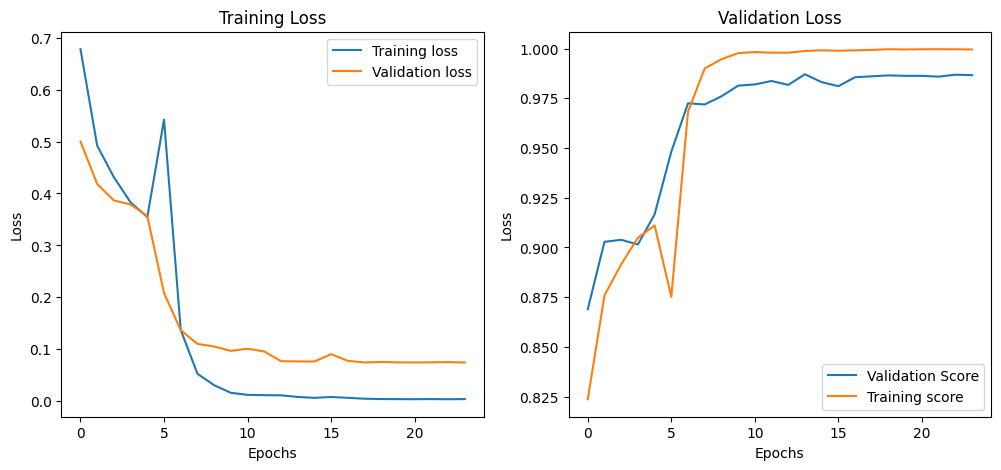

In [ ]:
history = merge_histories(history_warmup, history_finetune)
plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
plt.plot(history['loss'], label=f'Training loss')
plt.plot(history['val_loss'], label=f'Validation loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2, 2)
plt.plot(history['val_contest_score'], label=f'Validation Score')
plt.plot(history['contest_score'], label = f'Training score')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
path = os.path.join(models_path, 'modelResNet50V2.keras')
model.save(path)

###### Xception

In [ ]:
train_df, val_df = train_test_split(
    train_augmented_df,
    test_size=0.1,
    stratify=train_augmented_df['label'],
    random_state=42
)

image_size = 229
batch_size = 32

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

Found 25731 validated image filenames belonging to 4 classes.
Found 2859 validated image filenames belonging to 4 classes.


In [ ]:
with strategy.scope():
    base_model = tf.keras.applications.Xception(weights='imagenet',
                                                include_top=False,
                                                input_shape=(image_size, image_size, 3))

    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1536, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
with strategy.scope():
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))
    base_model.trainable = True

    model = Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

In [ ]:
target_file = os.path.join(models_path, 'xception.keras')

checkpoint = ModelCheckpoint(target_file, monitor="val_contest_score",
                             save_best_only=True, verbose=1, mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_contest_score', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1, mode='max')

early_stopping = EarlyStopping(
    monitor='val_contest_score',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

callbacks = [checkpoint, reduce_lr, early_stopping]

In [ ]:
history_warmup = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - contest_score: 0.7688 - loss: 0.8908
Epoch 1: val_contest_score improved from -inf to 0.85353, saving model to /kaggle/working/models/xception.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 157s 173ms/step - contest_score: 0.7689 - loss: 0.8906 - val_contest_score: 0.8535 - val_loss: 0.5359 - learning_rate: 1.0000e-04
Epoch 2/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - contest_score: 0.8621 - loss: 0.5385
Epoch 2: val_contest_score improved from 0.85353 to 0.87394, saving model to /kaggle/working/models/xception.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 127s 158ms/step - contest_score: 0.8621 - loss: 0.5385 - val_contest_score: 0.8739 - val_loss: 0.4843 - learning_rate: 1.0000e-04
Epoch 3/5
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - contest_score: 0.8794 - loss: 0.4825
Epoch 3: val_contest_score improved from 0.87394 to 0.88394, saving model to /kaggle/working/models/xception.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 127s 158ms/step - contest_score: 0.8794 - los

In [ ]:
with strategy.scope():
    base_model.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

In [ ]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


E0000 00:00:1752518108.674786     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752518108.860344     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752518110.237195     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752518110.377420     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 61/805 ━━━━━━━━━━━━━━━━━━━━ 6:45 545ms/step - contest_score: 0.6081 - loss: 2.4418

E0000 00:00:1752518158.591225     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752518158.726598     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - contest_score: 0.7791 - loss: 1.0586
Epoch 1: val_contest_score improved from 0.90069 to 0.93217, saving model to /kaggle/working/models/xception.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 510s 560ms/step - contest_score: 0.7792 - loss: 1.0581 - val_contest_score: 0.9322 - val_loss: 0.2963 - learning_rate: 1.0000e-05
Epoch 2/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - contest_score: 0.9385 - loss: 0.2552
Epoch 2: val_contest_score improved from 0.93217 to 0.96065, saving model to /kaggle/working/models/xception.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 431s 535ms/step - contest_score: 0.9386 - loss: 0.2551 - val_contest_score: 0.9607 - val_loss: 0.1881 - learning_rate: 1.0000e-05
Epoch 3/50
805/805 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - contest_score: 0.9696 - loss: 0.1324
Epoch 3: val_contest_score improved from 0.96065 to 0.96578, saving model to /kaggle/working/models/xception.keras
805/805 ━━━━━━━━━━━━━━━━━━━━ 431s 535ms/step - contest_score: 0.9696 

In [ ]:
path = os.path.join(models_path, 'modelXception.keras')
model.save(path)

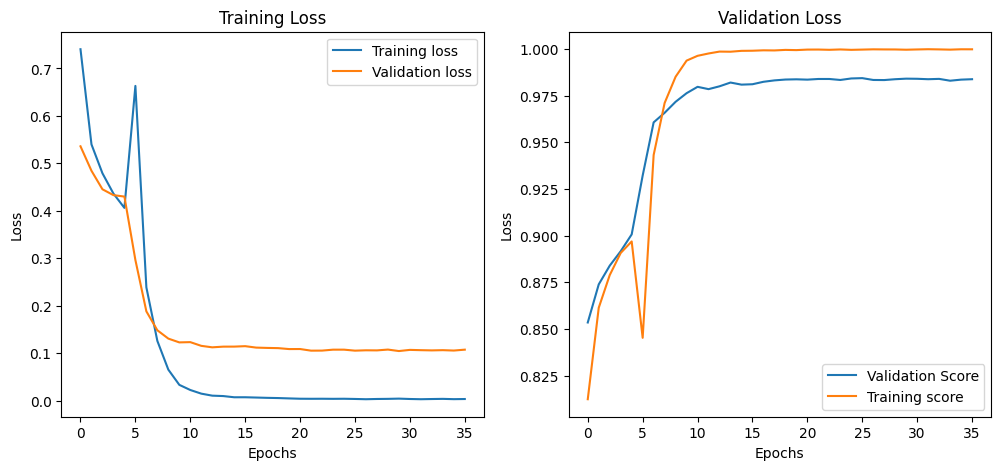

In [ ]:
history = merge_histories(history_warmup, history_finetune)
plt.figure(figsize=(12,5))
plt.subplot(1,2, 1)
plt.plot(history['loss'], label=f'Training loss')
plt.plot(history['val_loss'], label=f'Validation loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2, 2)
plt.plot(history['val_contest_score'], label=f'Validation Score')
plt.plot(history['contest_score'], label = f'Training score')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

##### EfficientB4

In [ ]:
train_df, val_df = train_test_split(
    train_augmented_df,
    test_size=0.1,
    stratify=train_augmented_df['label'],
    random_state=42
)

image_size = 380
batch_size = 16

train_datagen = ImageDataGenerator(preprocessing_function = tf.keras.applications.efficientnet.preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function = tf.keras.applications.efficientnet.preprocess_input)

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

Found 25731 validated image filenames belonging to 4 classes.
Found 2859 validated image filenames belonging to 4 classes.


In [ ]:
with strategy.scope():
    base_model = tf.keras.applications.EfficientNetB4(weights='imagenet',
                                                      include_top=False,
                                                      input_shape=(image_size, image_size, 3))

    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(4, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(1e-4))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
target_file = os.path.join(models_path, 'efficientb4.keras')

checkpoint = ModelCheckpoint(target_file, monitor="val_contest_score",
                             save_best_only=True, verbose=1, mode='max')

reduce_lr = ReduceLROnPlateau(monitor='val_contest_score', factor=0.1, patience=2,
                              min_delta=0.0001, verbose=1, mode='max')

early_stopping = EarlyStopping(
    monitor='val_contest_score',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

callbacks = [checkpoint, reduce_lr, early_stopping]

In [ ]:
history_warmup = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
E0000 00:00:1752531532.708776     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752531532.892497     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 695/1609 ━━━━━━━━━━━━━━━━━━━━ 2:06 138ms/step - contest_score: 0.7223 - loss: 0.8726

E0000 00:00:1752531650.005819     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752531650.148346     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1609/1609 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - contest_score: 0.7833 - loss: 0.7314

E0000 00:00:1752531825.523750     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752531825.690601     107 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_contest_score improved from -inf to 0.93439, saving model to /kaggle/working/models/efficientb4.keras
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 339s 178ms/step - contest_score: 0.7833 - loss: 0.7313 - val_contest_score: 0.9344 - val_loss: 0.2984 - learning_rate: 1.0000e-04
Epoch 2/5
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - contest_score: 0.8996 - loss: 0.4142
Epoch 2: val_contest_score improved from 0.93439 to 0.94297, saving model to /kaggle/working/models/efficientb4.keras
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 246s 153ms/step - contest_score: 0.8996 - loss: 0.4142 - val_contest_score: 0.9430 - val_loss: 0.2324 - learning_rate: 1.0000e-04
Epoch 3/5
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - contest_score: 0.9138 - loss: 0.3535
Epoch 3: val_contest_score improved from 0.94297 to 0.95077, saving model to /kaggle/working/models/efficientb4.keras
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 246s 153ms/step - contest_score: 0.9138 - loss: 0.3535 - val_contest_score: 0.9508 - val_loss: 0.2052 - lea

In [ ]:
with strategy.scope():
    base_model.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
        loss='sparse_categorical_crossentropy',
        metrics=[ContestScore()]
    )

In [ ]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


E0000 00:00:1752532946.511028     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752532946.656659     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752532947.127716     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752532947.274449     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752532947.822688     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

  26/1609 ━━━━━━━━━━━━━━━━━━━━ 14:04 534ms/step - contest_score: 0.6477 - loss: 1.2820

E0000 00:00:1752533021.223370     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752533021.357410     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752533021.651957     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752533021.789834     109 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1609/1609 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - contest_score: 0.8422 - loss: 0.6156
Epoch 1: val_contest_score did not improve from 0.96100
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 1116s 587ms/step - contest_score: 0.8422 - loss: 0.6155 - val_contest_score: 0.9600 - val_loss: 0.1583 - learning_rate: 1.0000e-05
Epoch 2/50
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - contest_score: 0.9430 - loss: 0.2331
Epoch 2: val_contest_score improved from 0.96100 to 0.97919, saving model to /kaggle/working/models/efficientb4.keras
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 872s 542ms/step - contest_score: 0.9430 - loss: 0.2331 - val_contest_score: 0.9792 - val_loss: 0.0909 - learning_rate: 1.0000e-05
Epoch 3/50
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - contest_score: 0.9681 - loss: 0.1405
Epoch 3: val_contest_score improved from 0.97919 to 0.98489, saving model to /kaggle/working/models/efficientb4.keras
1609/1609 ━━━━━━━━━━━━━━━━━━━━ 872s 542ms/step - contest_score: 0.9681 - loss: 0.1405 - val_contest_score: 0.98

In [ ]:
path = os.path.join(models_path, 'modelEfficientB4.keras')
model.save(path)

## F. Evaluación del desempeño del modelo final

Para la evaluacion del desempeño de los modelos, vamos a generar una función que genere el reporte de clasificación de sklearn, la matriz de confusión de los resultados del modelo sobre la partición de validación y el score que se usará para evaluar el contest.

In [ ]:
@register_keras_serializable()
class ContestScore(Metric):
    def __init__(self, name='contest_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.accuracy = tf.keras.metrics.SparseCategoricalAccuracy()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(y_true, tf.int64)
        y_pred_classes = tf.cast(y_pred_classes, tf.int64)

        self.accuracy.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred_classes, sample_weight)

    def result(self):
        return (self.accuracy.result() + self.recall.result()) / 2.0

    def reset_states(self):
        self.accuracy.reset_states()
        self.recall.reset_states()

def loadModel(route):
  pipeline = joblib.load(os.path.join(models_path, route))
  assert hasattr(pipeline, 'predict')
  return pipeline

def loadKerasModel(route):
  pipeline = tf.keras.models.load_model(os.path.join(models_path, route))
  assert hasattr(pipeline, 'predict')
  return pipeline

def loadScaler(route):
  pipeline = joblib.load(os.path.join(models_path, route))
  assert hasattr(pipeline, 'transform')
  return pipeline

def loadLabelEncoder(route):
  pipeline = joblib.load(os.path.join(models_path, route))
  assert hasattr(pipeline, 'inverse_transform')
  return pipeline

def showPerformanceKeras(model, val_df, image_size=224, batch_size=32, n_errors=10):
    """
    Evalúa un modelo Keras sobre un DataFrame de validación:
     - Classification report (precisión, recall, f1 por clase)
     - Matriz de confusión
     - Accuracy global
     - Macro recall
     - Métrica compuesta (accuracy + recall_macro)/2
     - Curvas ROC por clase + AUC
     - Ejemplos de errores (primeros n_errors)
    Devuelve un dict con todas las métricas y listas de errores.
    """
    # --- Preparar data generator ---
    val_gen = ImageDataGenerator()
    val_data = val_gen.flow_from_dataframe(
        dataframe=val_df,
        directory=os.path.join(preprocessed_base_path, 'data_augmentation', 'train'),
        x_col='filename',
        y_col='label',
        target_size=(image_size, image_size),
        class_mode='categorical',
        shuffle=False,
        batch_size=batch_size
    )

    # Mapeo índice → clase
    y_true_idx = val_data.classes
    idx_to_class = {v: k for k, v in val_data.class_indices.items()}
    class_names = [idx_to_class[i] for i in sorted(idx_to_class)]

    # --- Predicciones ---
    y_pred_probs = model.predict(val_data)               # shape (n_samples, n_classes)
    y_pred_idx   = np.argmax(y_pred_probs, axis=1)
    y_pred_labels = [idx_to_class[i] for i in y_pred_idx]
    y_true_labels = [idx_to_class[i] for i in y_true_idx]

    # --- Classification report + Matriz de confusión ---
    print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_names)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusión')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()
    plt.show()

    # --- Accuracy, Macro Recall, Métrica Compuesta ---
    acc = accuracy_score(y_true_labels, y_pred_labels)
    macro_rec = recall_score(y_true_labels, y_pred_labels, average='macro')
    comp_score = (acc + macro_rec) / 2.0
    print(f'Accuracy:     {acc:.4f}')
    print(f'Macro Recall: {macro_rec:.4f}')
    print(f'Composite:    {comp_score:.4f}')

    # --- ROC curves & AUC por clase ---
    lb = LabelBinarizer()
    y_true_bin = lb.fit_transform(y_true_labels)
    plt.figure(figsize=(10, 8))
    roc_aucs = {}
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_aucs[cls] = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_aucs[cls]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
    plt.title('Curvas ROC por Clase')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    print("AUC por clase:")
    for cls, a in roc_aucs.items():
        print(f"  {cls}: {a:.3f}")

    # --- Casos mal clasificados ---
    print(f"\nPrimeros {n_errors} ejemplos mal clasificados:")
    errors = [
        (fn, true, pred)
        for fn, true, pred in zip(val_data.filenames, y_true_labels, y_pred_labels)
        if true != pred
    ]
    for i, (fn, t, p) in enumerate(errors[:n_errors]):
        print(f"{i+1:>2}. Archivo: {fn:>20} | Real: {t:>10} | Predicho: {p:>10}")

    # --- Devolver resultados ---
    return {
        'accuracy':      acc,
        'macro_recall':  macro_rec,
        'composite_score':     comp_score,
        'roc_auc':       roc_aucs,
        'confusion_matrix': cm,
        'classification_report': classification_report(
            y_true_labels, y_pred_labels, target_names=class_names, output_dict=True
        ),
        'misclassified': errors
    }


def showPerformanceEmbedding(model, X_val, y_true, encoder, keras=False, n_errors=10):
    """
    Evalúa un modelo de embedding (sklearn o Keras) sobre un conjunto X_val / y_true:
      - Classification report
      - Matriz de confusión
      - Accuracy global
      - Macro Recall
      - Métrica compuesta (accuracy + recall_macro)/2
      - ROC y AUC por clase (si hay probabilidades)
      - Listado de primeros n_errors casos mal clasificados
    Devuelve un dict con todas las métricas y listas de errores.
    """
    # 1) Predicciones
    y_raw = model.predict(X_val)
    if keras:
        # y_raw es (n_samples, n_classes)
        y_idx = np.argmax(y_raw, axis=1)
    else:
        # y_raw debe ser ya vectores de clase
        y_idx = y_raw
    y_pred = encoder.inverse_transform(y_idx)
    y_true_lab = np.array(y_true)
    class_names = list(encoder.classes_)

    # 2) Classification report + Confusion Matrix
    print(classification_report(y_true_lab, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true_lab, y_pred, labels=class_names)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusión')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()
    plt.show()

    # 3) Accuracy, Macro Recall, Composite
    acc = accuracy_score(y_true_lab, y_pred)
    macro_rec = recall_score(y_true_lab, y_pred, average='macro')
    comp_score = (acc + macro_rec) / 2.0
    print(f'Accuracy:     {acc:.4f}')
    print(f'Macro Recall: {macro_rec:.4f}')
    print(f'Composite:    {comp_score:.4f}')

    # 4) ROC & AUC por clase (si hay probabilidades)
    roc_aucs = {}
    try:
        if keras:
            y_scores = y_raw
        else:
            y_scores = model.predict_proba(X_val)
        lb = LabelBinarizer().fit(y_true_lab)
        y_true_bin = lb.transform(y_true_lab)
        plt.figure(figsize=(10, 8))
        for i, cls in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
            roc_aucs[cls] = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_aucs[cls]:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
        plt.title('Curvas ROC por Clase')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()
        print("AUC por clase:")
        for cls, a in roc_aucs.items():
            print(f"  {cls}: {a:.3f}")
    except Exception:
        print("No fue posible calcular ROC/AUC (¿falta predict_proba?).")

    # 5) Casos mal clasificados
    errors = [
        (i, true, pred)
        for i, (true, pred) in enumerate(zip(y_true_lab, y_pred))
        if true != pred
    ]
    print(f"\nPrimeros {n_errors} casos mal clasificados:")
    for i, (idx, true, pred) in enumerate(errors[:n_errors], 1):
        print(f"{i:>2}. Índice: {idx:>2} | Real: {true:>10} | Predicho: {pred:>10}")

    # 6) Retornar todo en un diccionario
    return {
        'accuracy':             acc,
        'macro_recall':         macro_rec,
        'composite_score':      comp_score,
        'confusion_matrix':     cm,
        'classification_report': classification_report(
                                    y_true_lab, y_pred,
                                    target_names=class_names,
                                    output_dict=True
                                 ),
        'roc_auc':              roc_aucs,
        'misclassified':        errors
    }


Generamos los resultados con los modelos clásicos entrenados usando el embedding de DINOv2. Vale la pemna aclarar que el tamaño de estos modelos permitio entrenarlos usando validacion cruzada, por lo que el resultado estará sesgado por el uso de todos los datos de entrenamiento (En los distintos pliegues) dada la naturaleza de GridSearchCV

In [ ]:
X = np.load(os.path.join(preprocessed_base_path, 'train_embeddinngs_dinov2.npy'))
X_test = np.load(os.path.join(preprocessed_base_path, 'test_embeddinngs_dinov2.npy'))

train_df = pd.read_csv(os.path.join(dataset_path, 'train_labels.csv'))
source_dir = os.path.join(preprocessed_base_path, 'data_augmentation', 'train')
X_ids = sorted([f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
X_ids_cropped = list(map(lambda x: x.split('_')[0]+'.jpg', X_ids))
expanded_df = pd.DataFrame({
    'filename': X_ids,
    'id': X_ids_cropped
})
final_df = expanded_df.merge(train_df, on='id', how='left')
y = final_df['label']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    stratify=y,
    random_state=42
)

train_df, val_df = train_test_split(
    final_df,
    test_size=0.1,
    stratify=y,
    random_state=42
)

In [ ]:
scores = {
    'model': [],
    'score': []
}

deep_scores = {
    'model': [],
    'score': []
}

### Desempeño KNN

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       359
  meningioma       1.00      1.00      1.00       344
     notumor       1.00      1.00      1.00       445
   pituitary       1.00      1.00      1.00       387

    accuracy                           1.00      1535
   macro avg       1.00      1.00      1.00      1535
weighted avg       1.00      1.00      1.00      1535



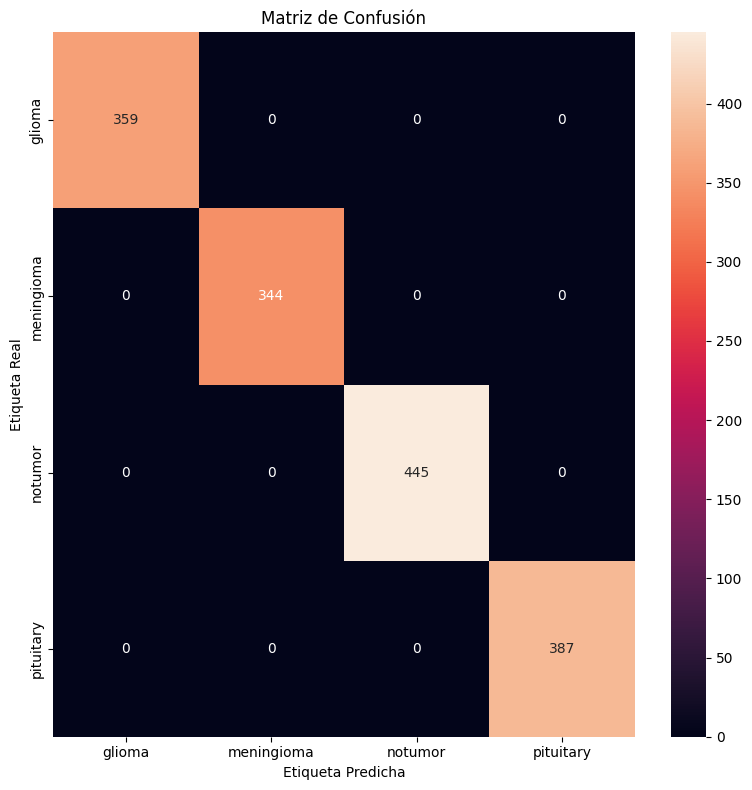

Accuracy:     1.0000
Macro Recall: 1.0000
Composite:    1.0000


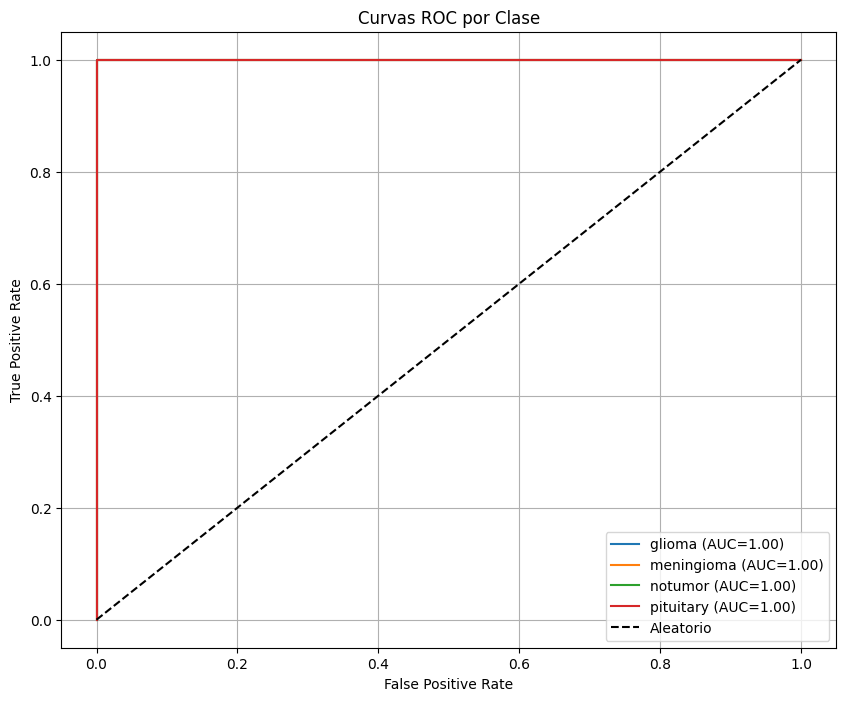

AUC por clase:
  glioma: 1.000
  meningioma: 1.000
  notumor: 1.000
  pituitary: 1.000

Primeros 10 casos mal clasificados:


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineKNN.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
p_result = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('KNN')
scores['score'].append(p_result['composite_score'])

### Desempeño GNB

              precision    recall  f1-score   support

      glioma       0.79      0.66      0.72       359
  meningioma       0.57      0.47      0.52       344
     notumor       0.90      0.89      0.89       445
   pituitary       0.65      0.86      0.74       387

    accuracy                           0.74      1535
   macro avg       0.73      0.72      0.72      1535
weighted avg       0.74      0.74      0.73      1535



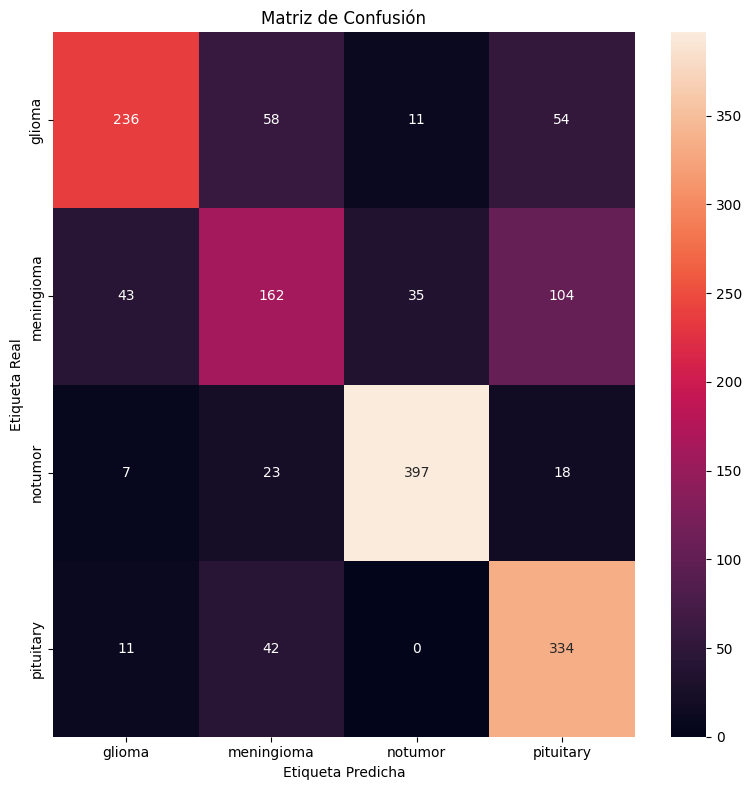

Accuracy:     0.7355
Macro Recall: 0.7209
Composite:    0.7282


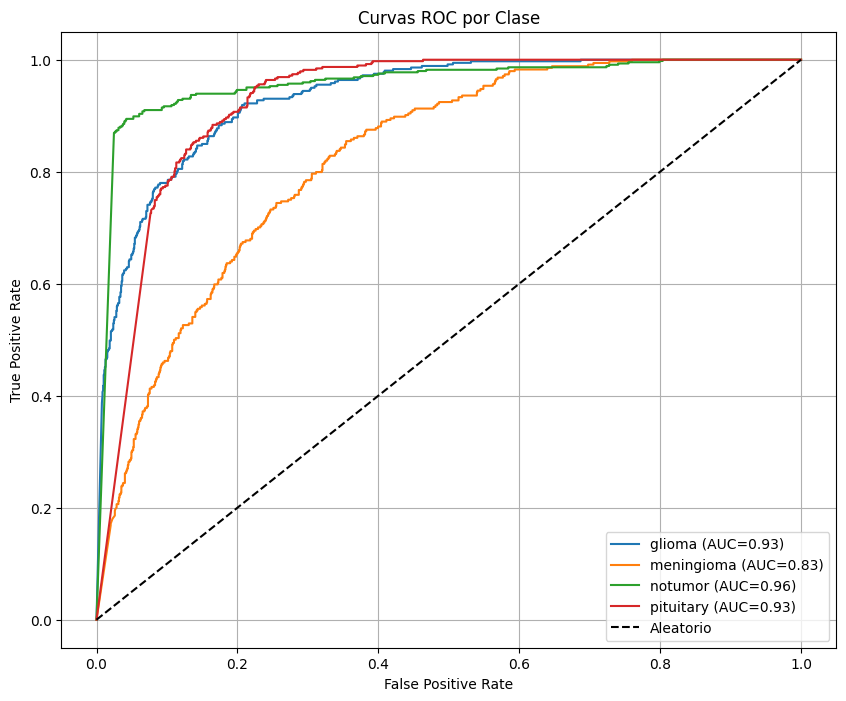

AUC por clase:
  glioma: 0.933
  meningioma: 0.825
  notumor: 0.958
  pituitary: 0.925

Primeros 10 casos mal clasificados:
 1. Índice:  5 | Real:     glioma | Predicho: meningioma
 2. Índice: 15 | Real:     glioma | Predicho:  pituitary
 3. Índice: 18 | Real:  pituitary | Predicho: meningioma
 4. Índice: 23 | Real:    notumor | Predicho:  pituitary
 5. Índice: 24 | Real:     glioma | Predicho:  pituitary
 6. Índice: 27 | Real:    notumor | Predicho:  pituitary
 7. Índice: 30 | Real: meningioma | Predicho:     glioma
 8. Índice: 31 | Real:     glioma | Predicho:  pituitary
 9. Índice: 33 | Real: meningioma | Predicho:     glioma
10. Índice: 37 | Real: meningioma | Predicho:    notumor


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineGNB.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
p_result = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('GNB')
scores['score'].append(p_result['composite_score'])

### Desempeño SVC con kernel lineal

              precision    recall  f1-score   support

      glioma       1.00      0.99      0.99       359
  meningioma       0.99      1.00      0.99       344
     notumor       1.00      1.00      1.00       445
   pituitary       1.00      1.00      1.00       387

    accuracy                           1.00      1535
   macro avg       1.00      1.00      1.00      1535
weighted avg       1.00      1.00      1.00      1535



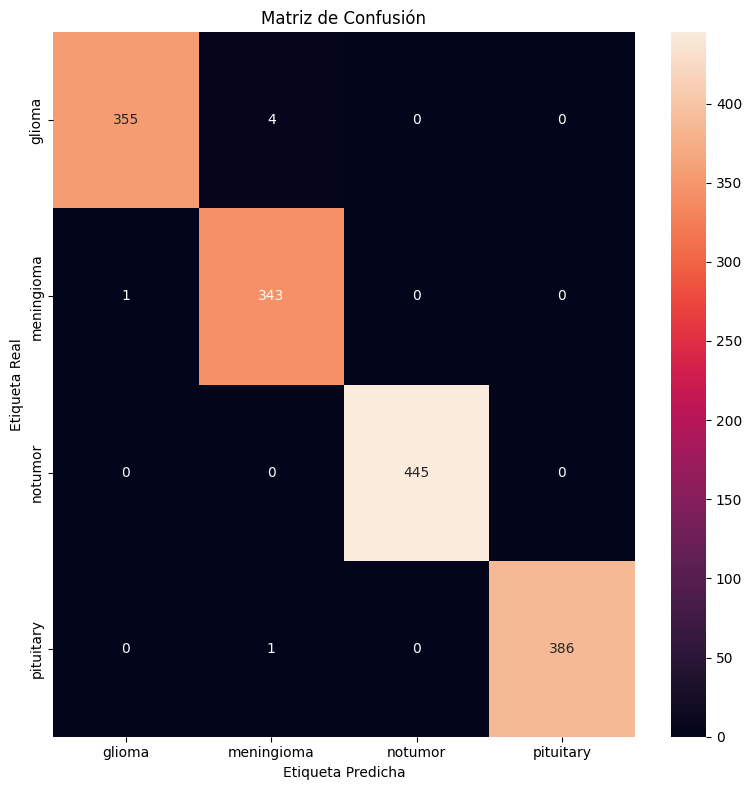

Accuracy:     0.9961
Macro Recall: 0.9958
Composite:    0.9960
No fue posible calcular ROC/AUC (¿falta predict_proba?).

Primeros 10 casos mal clasificados:
 1. Índice: 15 | Real:     glioma | Predicho: meningioma
 2. Índice: 230 | Real:     glioma | Predicho: meningioma
 3. Índice: 466 | Real: meningioma | Predicho:     glioma
 4. Índice: 1116 | Real:     glioma | Predicho: meningioma
 5. Índice: 1477 | Real:  pituitary | Predicho: meningioma
 6. Índice: 1514 | Real:     glioma | Predicho: meningioma


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineSVC_linear.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
p_result = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('SVC_linear')
scores['score'].append(p_result['composite_score'])

### Desempeño SVC con kernel RBF

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       359
  meningioma       1.00      1.00      1.00       344
     notumor       1.00      1.00      1.00       445
   pituitary       1.00      1.00      1.00       387

    accuracy                           1.00      1535
   macro avg       1.00      1.00      1.00      1535
weighted avg       1.00      1.00      1.00      1535



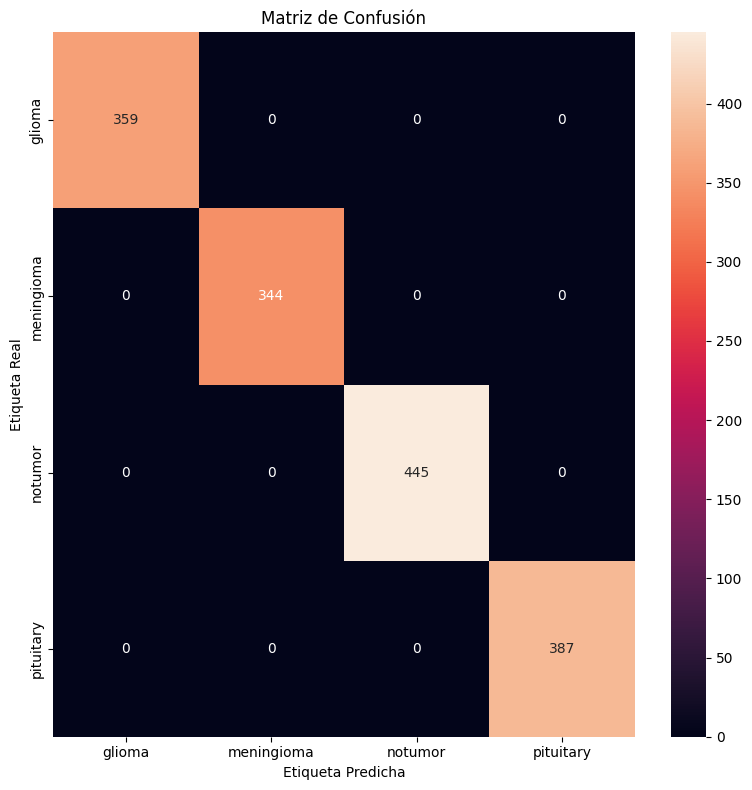

Accuracy:     1.0000
Macro Recall: 1.0000
Composite:    1.0000
No fue posible calcular ROC/AUC (¿falta predict_proba?).

Primeros 10 casos mal clasificados:


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineSVC_RBF.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
p_result = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('SVC_RBF')
scores['score'].append(p_result['composite_score'])

### Desempeño SVC con kernel polinomial

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       359
  meningioma       1.00      1.00      1.00       344
     notumor       1.00      1.00      1.00       445
   pituitary       1.00      1.00      1.00       387

    accuracy                           1.00      1535
   macro avg       1.00      1.00      1.00      1535
weighted avg       1.00      1.00      1.00      1535



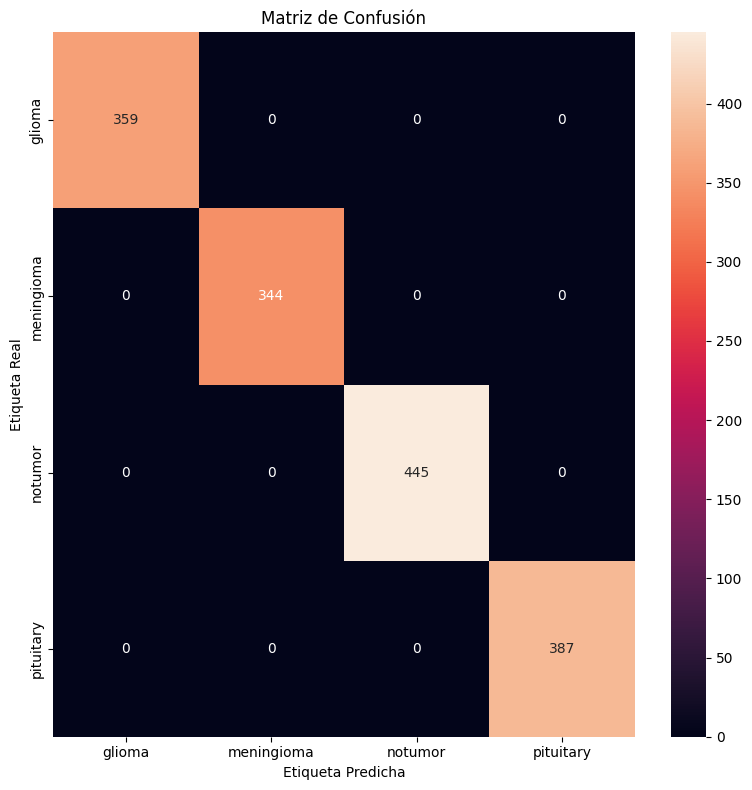

Accuracy:     1.0000
Macro Recall: 1.0000
Composite:    1.0000
No fue posible calcular ROC/AUC (¿falta predict_proba?).

Primeros 10 casos mal clasificados:


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineSVC_polynomial.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
p_result = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('SVC_polynomial')
scores['score'].append(p_result['composite_score'])

### Desempeño modelos XGB

              precision    recall  f1-score   support

      glioma       0.97      0.97      0.97       359
  meningioma       0.98      0.90      0.94       344
     notumor       0.99      0.99      0.99       445
   pituitary       0.93      1.00      0.96       387

    accuracy                           0.97      1535
   macro avg       0.97      0.96      0.96      1535
weighted avg       0.97      0.97      0.97      1535



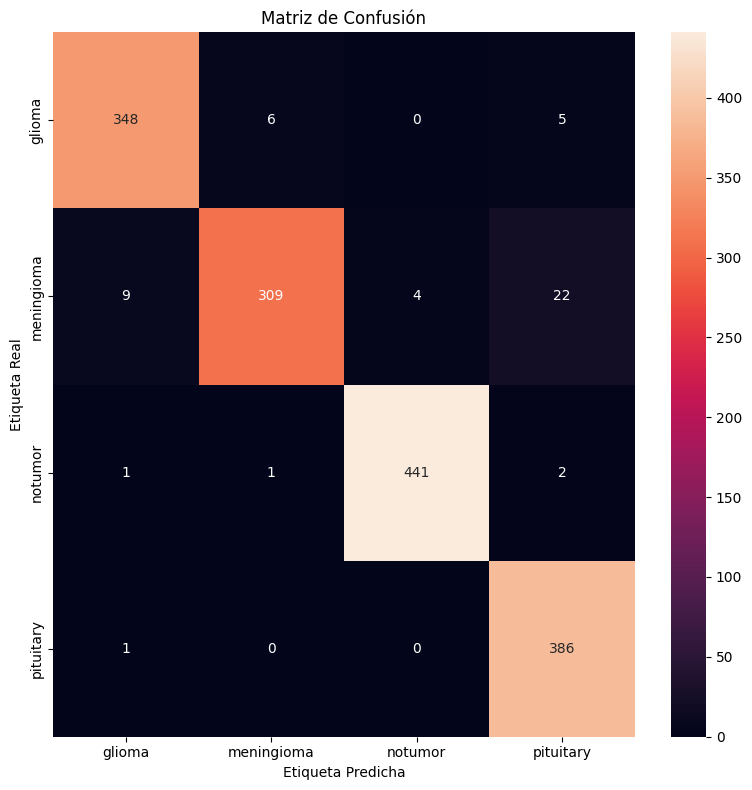

Accuracy:     0.9668
Macro Recall: 0.9640
Composite:    0.9654


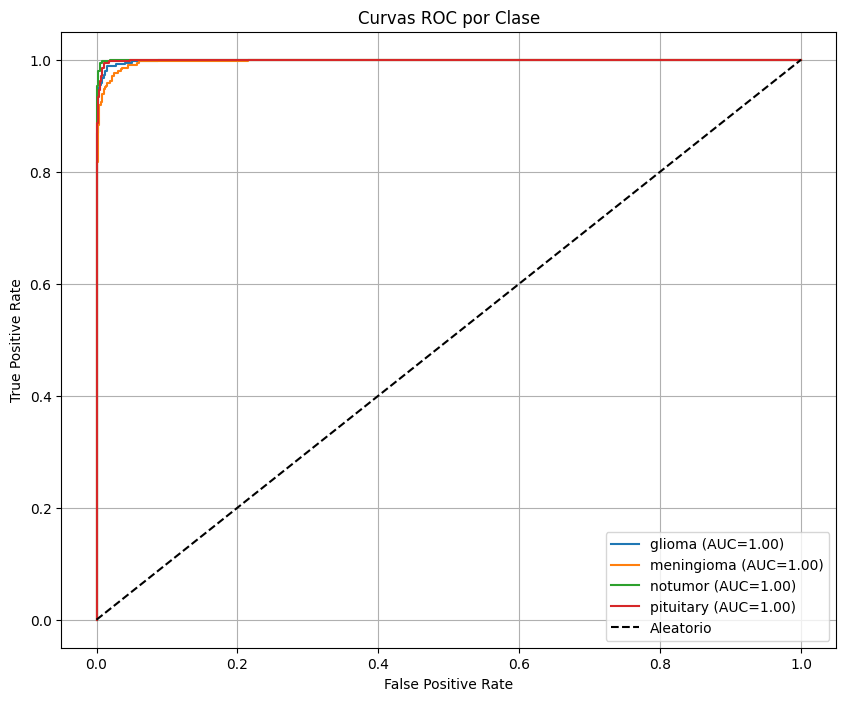

AUC por clase:
  glioma: 0.999
  meningioma: 0.997
  notumor: 1.000
  pituitary: 0.999

Primeros 10 casos mal clasificados:
 1. Índice: 63 | Real: meningioma | Predicho:     glioma
 2. Índice: 112 | Real:    notumor | Predicho:  pituitary
 3. Índice: 116 | Real: meningioma | Predicho:     glioma
 4. Índice: 118 | Real: meningioma | Predicho:  pituitary
 5. Índice: 148 | Real: meningioma | Predicho:     glioma
 6. Índice: 166 | Real: meningioma | Predicho:  pituitary
 7. Índice: 203 | Real: meningioma | Predicho:  pituitary
 8. Índice: 214 | Real: meningioma | Predicho:  pituitary
 9. Índice: 230 | Real:     glioma | Predicho:  pituitary
10. Índice: 268 | Real: meningioma | Predicho:  pituitary


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineXGB.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
p_result = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('XGB')
scores['score'].append(p_result['composite_score'])

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       359
  meningioma       1.00      1.00      1.00       344
     notumor       1.00      1.00      1.00       445
   pituitary       1.00      1.00      1.00       387

    accuracy                           1.00      1535
   macro avg       1.00      1.00      1.00      1535
weighted avg       1.00      1.00      1.00      1535



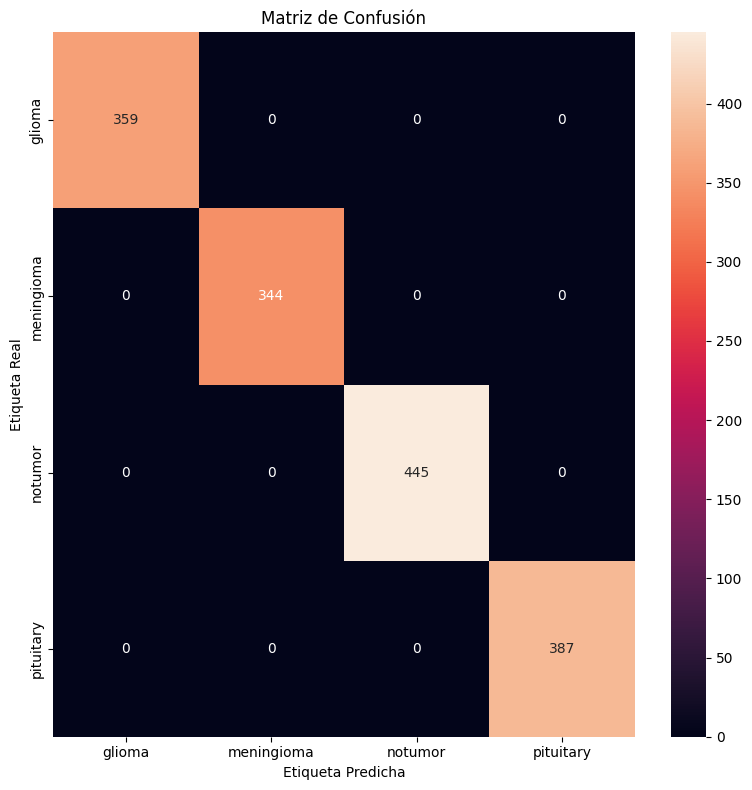

Accuracy:     1.0000
Macro Recall: 1.0000
Composite:    1.0000


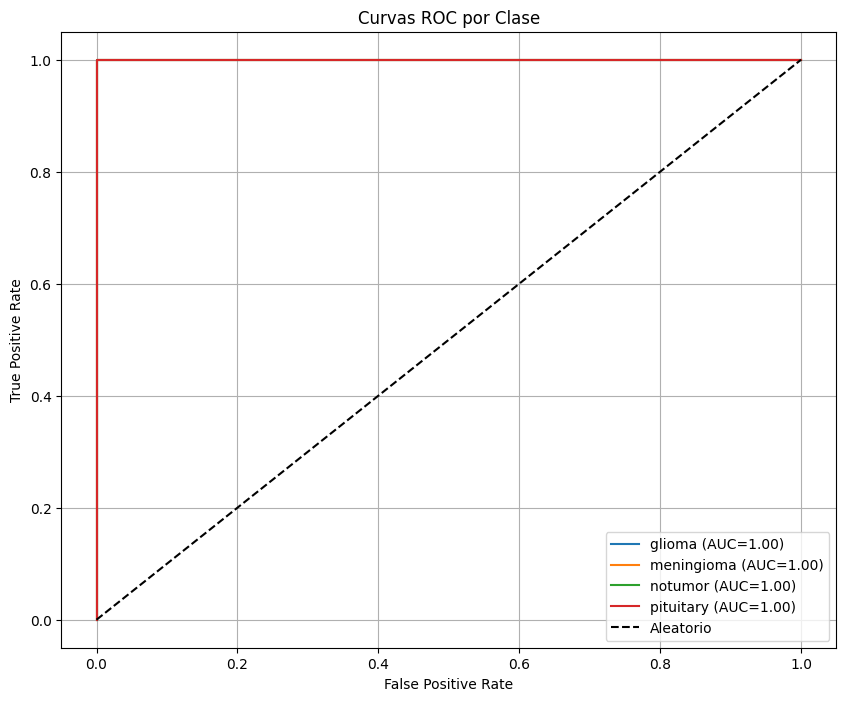

AUC por clase:
  glioma: 1.000
  meningioma: 1.000
  notumor: 1.000
  pituitary: 1.000

Primeros 10 casos mal clasificados:


In [ ]:
model = loadModel(os.path.join(models_path, 'pipelineLargeXGB.pkl'))
label_encoder = loadLabelEncoder(os.path.join(preprocessed_base_path, 'label_encoder.pkl'))
score = showPerformanceEmbedding(model, X_val, y_val, label_encoder)
scores['model'].append('XGB Large')
scores['score'].append(p_result['composite_score'])

In [ ]:
scores_df = pd.DataFrame(scores).set_index('model').sort_values(by='score', ascending=False)
scores_df.to_csv(os.path.join(submissions_path, 'scores_embeddings.csv'))
scores_df

,score
model,
KNN,1.000000
SVC_polynomial,1.000000
SVC_RBF,1.000000
SVC_linear,0.995966
XGB,0.965393
XGB Large,0.965393
GNB,0.728189


Ahora realizaremos las pruebas de desempeño sobre los modelos densos (Fine tunning sobre modelos de aprendizaje profundo)

### Desempeño modelo Resnet101

In [ ]:
warnings.filterwarnings('ignore')

Found 1535 validated image filenames belonging to 4 classes.
48/48 ━━━━━━━━━━━━━━━━━━━━ 286s 6s/step
              precision    recall  f1-score   support

      glioma       0.81      0.41      0.54       359
  meningioma       0.98      0.52      0.68       344
     notumor       0.50      0.94      0.65       445
   pituitary       0.95      0.83      0.89       387

    accuracy                           0.69      1535
   macro avg       0.81      0.68      0.69      1535
weighted avg       0.79      0.69      0.69      1535



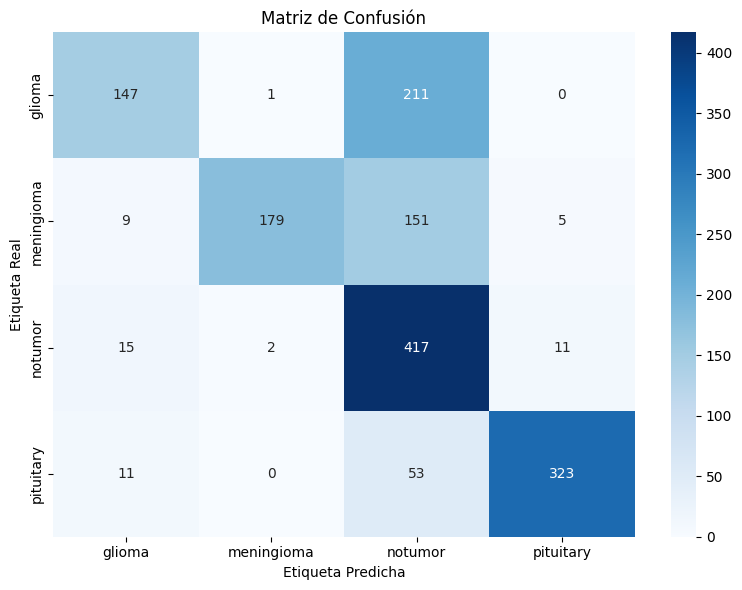

Accuracy:     0.6945
Macro Recall: 0.6754
Composite:    0.6849


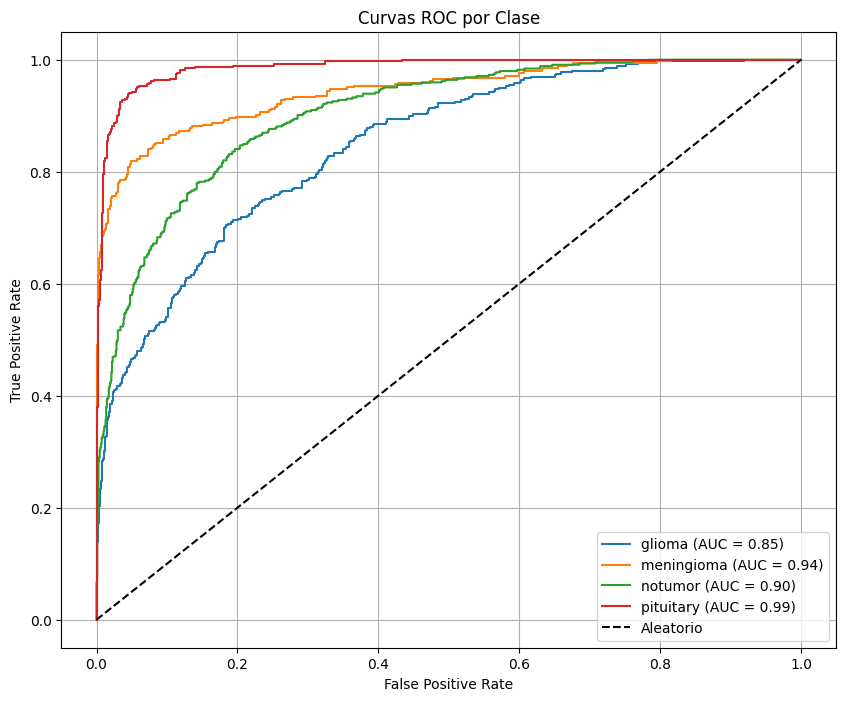

AUC por clase:
  glioma: 0.847
  meningioma: 0.944
  notumor: 0.904
  pituitary: 0.986

Primeros 10 ejemplos mal clasificados:
 1. Archivo:   img5051_scaled.jpg | Real:     glioma | Predicho:    notumor
 2. Archivo:   img1006_scaled.jpg | Real: meningioma | Predicho:    notumor
 3. Archivo:   img5306_scaled.jpg | Real:     glioma | Predicho:    notumor
 4. Archivo:   img5562_rot270.jpg | Real:     glioma | Predicho:    notumor
 5. Archivo:   img4308_scaled.jpg | Real:     glioma | Predicho:    notumor
 6. Archivo:   img4826_rot270.jpg | Real: meningioma | Predicho:    notumor
 7. Archivo:   img4954_rot180.jpg | Real:    notumor | Predicho: meningioma
 8. Archivo:   img1087_scaled.jpg | Real: meningioma | Predicho:    notumor
 9. Archivo:  img1331_cropped.jpg | Real:     glioma | Predicho:    notumor
10. Archivo:    img5580_rot90.jpg | Real: meningioma | Predicho:    notumor


In [ ]:
model = loadKerasModel(os.path.join(models_path, 'modelResnet101.keras'))
p_result = showPerformanceKeras(model, val_df, image_size=224)
deep_scores['model'].append('Resnet101')
deep_scores['score'].append(p_result['composite_score'])

### Desempeño modelo Resnet50V2

Found 1535 validated image filenames belonging to 4 classes.
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step
              precision    recall  f1-score   support

      glioma       0.91      0.90      0.90       359
  meningioma       0.91      0.89      0.90       344
     notumor       0.90      0.96      0.93       445
   pituitary       0.97      0.92      0.94       387

    accuracy                           0.92      1535
   macro avg       0.92      0.92      0.92      1535
weighted avg       0.92      0.92      0.92      1535



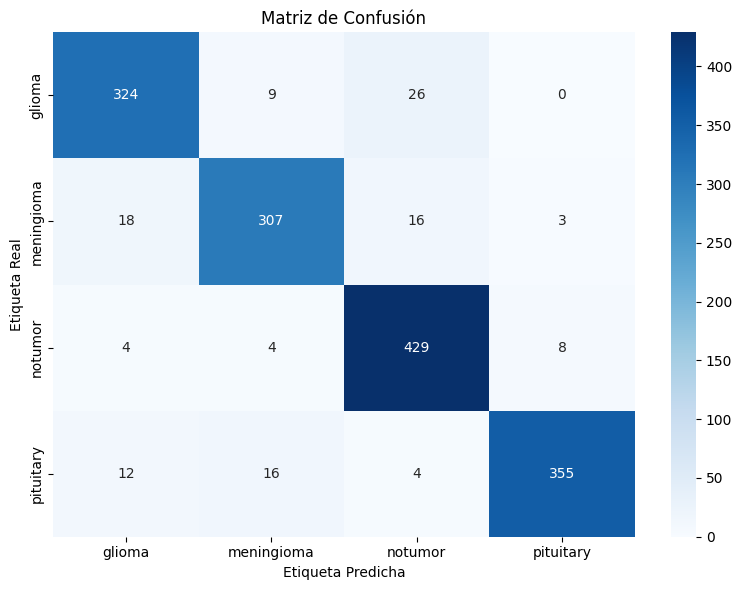

Accuracy:     0.9218
Macro Recall: 0.9191
Composite:    0.9205


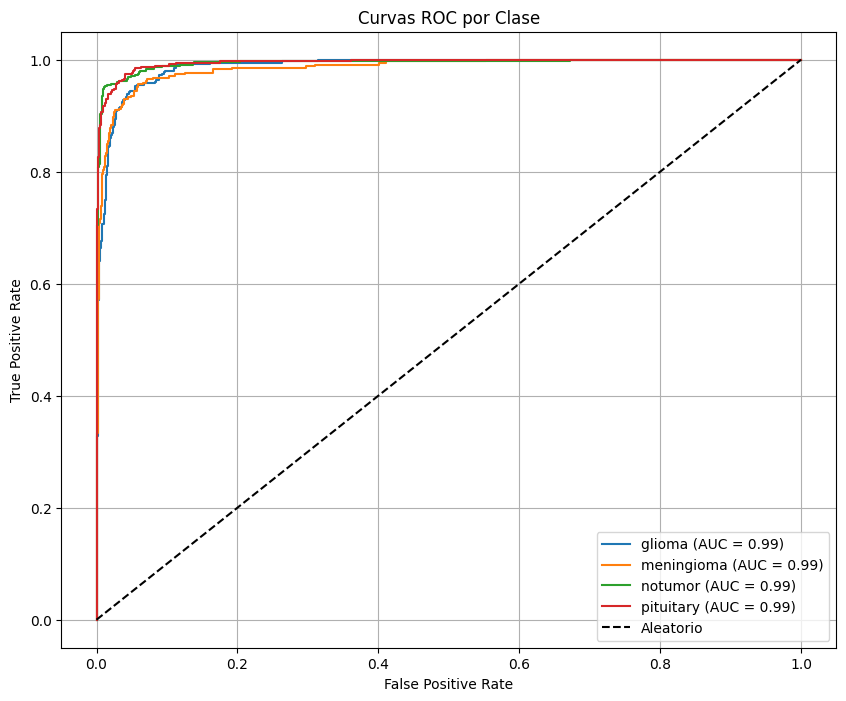

AUC por clase:
  glioma: 0.988
  meningioma: 0.985
  notumor: 0.994
  pituitary: 0.995

Primeros 10 ejemplos mal clasificados:
 1. Archivo:   img4954_rot180.jpg | Real:    notumor | Predicho:  pituitary
 2. Archivo:   img1087_scaled.jpg | Real: meningioma | Predicho:     glioma
 3. Archivo:  img1331_cropped.jpg | Real:     glioma | Predicho: meningioma
 4. Archivo:   img3928_rot180.jpg | Real: meningioma | Predicho:     glioma
 5. Archivo:   img3781_scaled.jpg | Real:  pituitary | Predicho:     glioma
 6. Archivo:   img1945_rot180.jpg | Real:  pituitary | Predicho:     glioma
 7. Archivo:  img4474_cropped.jpg | Real:    notumor | Predicho:  pituitary
 8. Archivo:   img2224_rot270.jpg | Real: meningioma | Predicho:    notumor
 9. Archivo:  img3991_cropped.jpg | Real:    notumor | Predicho: meningioma
10. Archivo:    img3437_rot90.jpg | Real:     glioma | Predicho:    notumor


In [ ]:
model = loadKerasModel(os.path.join(models_path, 'modelResNet50V2.keras'))
p_result = showPerformanceKeras(model, val_df, image_size=224)
deep_scores['model'].append('Resnet50V2')
deep_scores['score'].append(p_result['composite_score'])

### Desempeño modelo Xception

Found 1535 validated image filenames belonging to 4 classes.
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 210ms/step
              precision    recall  f1-score   support

      glioma       0.88      0.83      0.85       359
  meningioma       0.96      0.76      0.85       344
     notumor       0.81      0.96      0.88       445
   pituitary       0.92      0.95      0.94       387

    accuracy                           0.88      1535
   macro avg       0.89      0.88      0.88      1535
weighted avg       0.89      0.88      0.88      1535



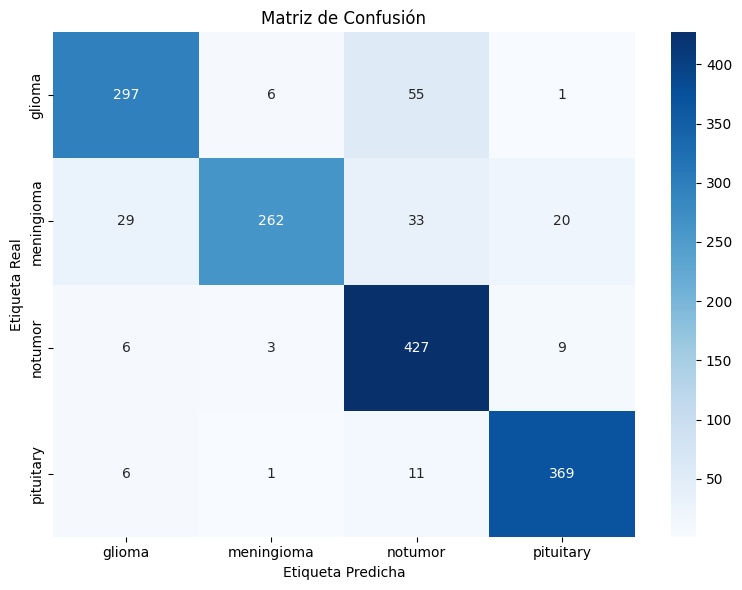

Accuracy:     0.8827
Macro Recall: 0.8755
Composite:    0.8791


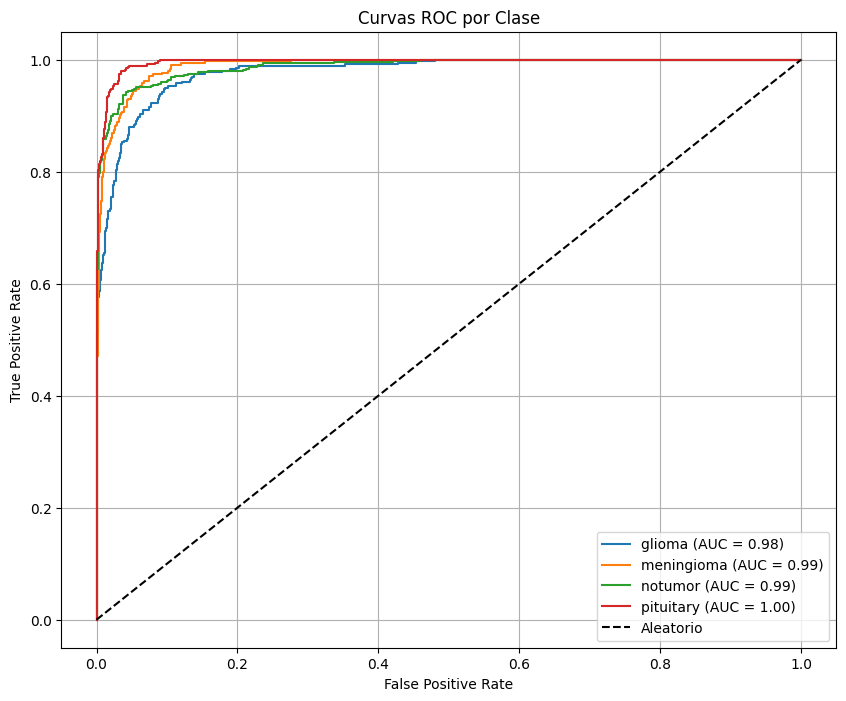

AUC por clase:
  glioma: 0.978
  meningioma: 0.989
  notumor: 0.988
  pituitary: 0.996

Primeros 10 ejemplos mal clasificados:
 1. Archivo:   img2624_scaled.jpg | Real: meningioma | Predicho:     glioma
 2. Archivo:   img4954_rot180.jpg | Real:    notumor | Predicho:  pituitary
 3. Archivo:   img1087_scaled.jpg | Real: meningioma | Predicho:     glioma
 4. Archivo:    img5580_rot90.jpg | Real: meningioma | Predicho:     glioma
 5. Archivo:   img1809_rot270.jpg | Real: meningioma | Predicho:     glioma
 6. Archivo:   img3928_rot180.jpg | Real: meningioma | Predicho:    notumor
 7. Archivo:   img3781_scaled.jpg | Real:  pituitary | Predicho:    notumor
 8. Archivo:  img4474_cropped.jpg | Real:    notumor | Predicho: meningioma
 9. Archivo:   img2523_rot180.jpg | Real:     glioma | Predicho:    notumor
10. Archivo:   img2224_rot270.jpg | Real: meningioma | Predicho:    notumor


In [ ]:
model = loadKerasModel(os.path.join(models_path, 'modelXception.keras'))
p_result = showPerformanceKeras(model, val_df, image_size=229)
deep_scores['model'].append('Xception')
deep_scores['score'].append(p_result['composite_score'])

### Desempeño modelo EfficientNetB4

Found 1535 validated image filenames belonging to 4 classes.
48/48 ━━━━━━━━━━━━━━━━━━━━ 33s 482ms/step
              precision    recall  f1-score   support

      glioma       0.85      0.78      0.81       359
  meningioma       0.97      0.85      0.91       344
     notumor       0.77      0.97      0.86       445
   pituitary       0.99      0.87      0.92       387

    accuracy                           0.87      1535
   macro avg       0.89      0.87      0.88      1535
weighted avg       0.89      0.87      0.88      1535



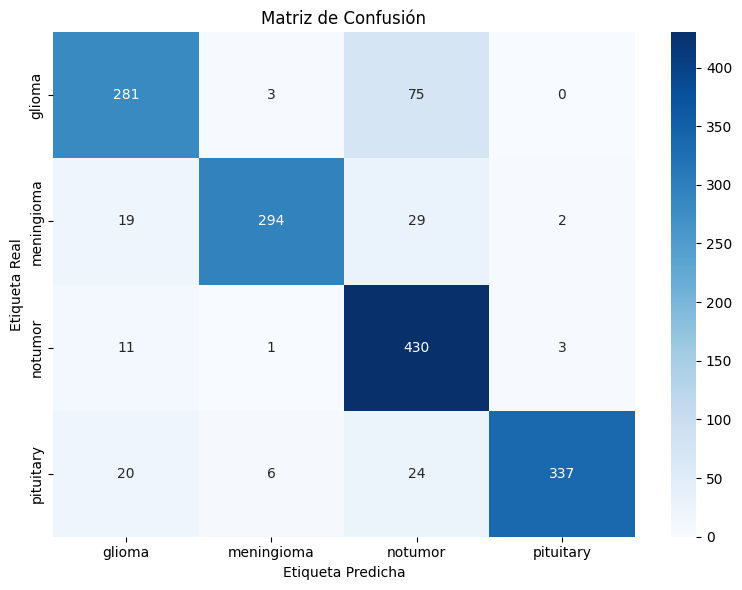

Accuracy:     0.8743
Macro Recall: 0.8686
Composite:    0.8714


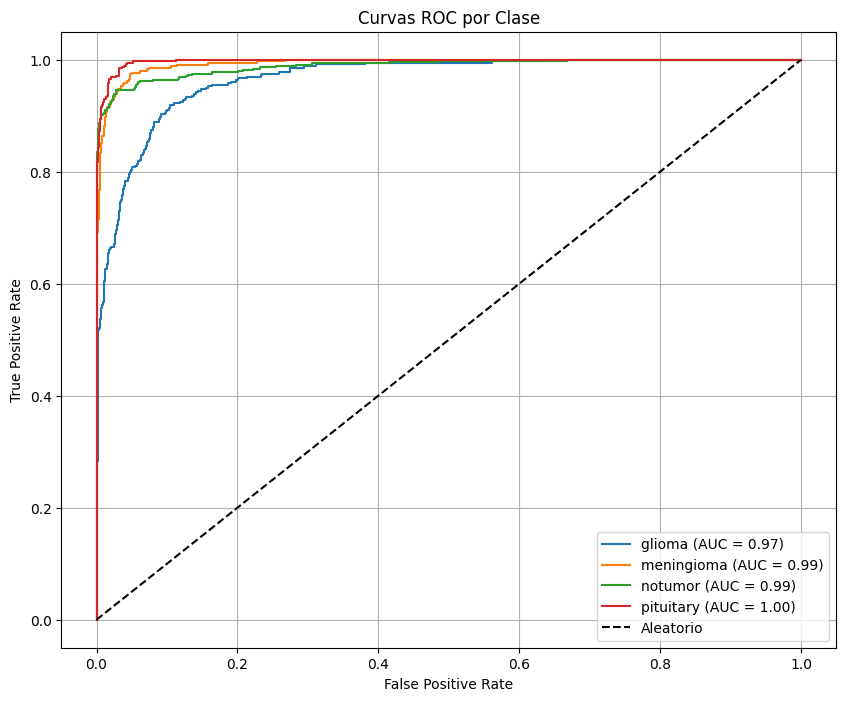

AUC por clase:
  glioma: 0.966
  meningioma: 0.993
  notumor: 0.989
  pituitary: 0.997

Primeros 10 ejemplos mal clasificados:
 1. Archivo:  img1676_cropped.jpg | Real:     glioma | Predicho:    notumor
 2. Archivo:   img4742_rot270.jpg | Real:  pituitary | Predicho:    notumor
 3. Archivo:   img4954_rot180.jpg | Real:    notumor | Predicho:  pituitary
 4. Archivo:   img1809_rot270.jpg | Real: meningioma | Predicho:     glioma
 5. Archivo:  img4474_cropped.jpg | Real:    notumor | Predicho:     glioma
 6. Archivo:   img4759_rot180.jpg | Real: meningioma | Predicho:    notumor
 7. Archivo:   img2523_rot180.jpg | Real:     glioma | Predicho:    notumor
 8. Archivo:   img5431_rot270.jpg | Real:     glioma | Predicho:    notumor
 9. Archivo:   img2224_rot270.jpg | Real: meningioma | Predicho:    notumor
10. Archivo:   img0307_scaled.jpg | Real:     glioma | Predicho:    notumor


In [ ]:
model = loadKerasModel(os.path.join(models_path, 'modelEfficientB4.keras'))
p_result = showPerformanceKeras(model, val_df, image_size=380)
deep_scores['model'].append('EfficientNetB4')
deep_scores['score'].append(p_result['composite_score'])

In [ ]:
scores_df = pd.DataFrame(deep_scores).set_index('model').sort_values(by='score', ascending=False)
scores_df.to_csv(os.path.join(submissions_path, 'scores_deepModels.csv'))
scores_df

,score
model,
Resnet50V2,0.920450
Xception,0.879114
EfficientNetB4,0.871443
Resnet101,0.684922


## G. Prueba y evaluación con un LLM

In [ ]:
import google.generativeai as genai
import base64
from typing import Tuple, Optional, List
from PIL import Image, ImageDraw, ImageFont
import io
import re
import json
from google.colab import userdata

TRAIN_DIR    = os.path.join(dataset_path, 'train')
LABELS_CSV   = os.path.join(dataset_path, 'train_labels.csv')

df = pd.read_csv(LABELS_CSV)

def load_image_bytes(image_id: str, ext: str = 'jpg') -> bytes:
    img_path = os.path.join(TRAIN_DIR, f"{image_id}")
    with open(img_path, 'rb') as f:
        return f.read()

def draw_regions_on_image(image_bytes: bytes, regions: List[dict]) -> bytes:
    # Open image
    image = Image.open(io.BytesIO(image_bytes))
    draw = ImageDraw.Draw(image)

    # Try to load a font, fall back to default if not available
    try:
        font = ImageFont.truetype("arial.ttf", 12)
    except:
        font = ImageFont.load_default()

    # Colors for different regions
    colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan', 'magenta']

    for i, region in enumerate(regions):
        color = colors[i % len(colors)]
        x, y, w, h = region['x'], region['y'], region['width'], region['height']

        # Draw bounding box
        draw.rectangle([x, y, x + w, y + h], outline=color, width=2)

        # Draw label
        label = f"{i+1}: {region['description'][:30]}..."

        # Get text size for background
        bbox = draw.textbbox((0, 0), label, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        # Draw background for text
        draw.rectangle([x, y-text_height-2, x+text_width+4, y], fill=color)
        draw.text((x+2, y-text_height-1), label, fill='white', font=font)

    # Convert back to bytes
    output = io.BytesIO()
    image.save(output, format='PNG')
    return output.getvalue()

def save_annotated_image(annotated_bytes: bytes, filename: str = "annotated_mri.png"):
    with open(filename, 'wb') as f:
        f.write(annotated_bytes)
    print(f"Annotated image saved as {filename}")

def analyze_mri_with_json_output(img_bytes: bytes) -> Tuple[str, Optional[dict], Optional[bytes], str]:
    model = genai.GenerativeModel('gemini-2.0-flash')
    image = Image.open(io.BytesIO(img_bytes))

    prompt = (
        """You are an AI radiology assistant.
          Your task: examine the supplied brain MRI scan, identify any tumors or other abnormalities, and respond **only** with a valid JSON object that follows the exact schema below.

          ──────────
          SCHEMA
          ──────────
          {
            "label": "< one of: notumor | pituitary | meningioma | glioma >",   // REQUIRED. Pick the single best category for this image.
            "findings": [
              {
                "id": <integer>,                                               // 1, 2, 3, … in order of importance
                "description": "<concise description of the finding>",         // e.g. "Heterogeneous mass in left temporal lobe"
                "coordinates": {                                               // Bounding box in pixels
                  "x": <integer>,                                              // upper‑left corner
                  "y": <integer>,
                  "width": <integer>,
                  "height": <integer>
                },
                "confidence": "<high | medium | low>",                         // Your confidence in this finding
                "severity": "<concerning | monitor | normal>"                  // Clinical relevance
              }
              // …additional findings as needed
            ],
            "summary": "<brief overall assessment of the scan>"                // 1‑3 sentences
          }

          ──────────
          INSTRUCTIONS
          ──────────
          1. **Label selection** – Choose exactly one label from the allowed list:
            • **notumor** • **pituitary** • **meningioma** • **glioma**

          2. **Findings array**
            • Include an entry for every clear abnormality you detect.
            • If the scan appears normal, return an empty array: `"findings": []`.

          3. **Coordinates**
            • If precise measurement is impossible, provide your best pixel‑level estimate based on the image dimensions.
            • Use whole numbers only.

          4. **Output rules**
            • Return **JSON only** – no extra keys, comments, or surrounding text.
            • Follow the field order and capitalization exactly.
            • Use double quotes around all keys and string values.

          5. If no abnormality is present, set `"summary"` to something like
            `"summary": "No intracranial mass or other abnormality detected."`

          Failure to comply with the schema or outputting anything other than JSON will invalidate the response."""
    )

    try:
        response = model.generate_content([prompt, image])
        analysis_text = response.text

        # Try to parse JSON from response
        try:
            # Extract JSON from response (in case there's extra text)
            json_start = analysis_text.find('{')
            json_end = analysis_text.rfind('}') + 1
            if json_start != -1 and json_end > json_start:
                json_str = analysis_text[json_start:json_end]
                parsed_data = json.loads(json_str)

                # Convert to regions format
                regions = []
                if 'findings' in parsed_data:
                    for finding in parsed_data['findings']:
                        if 'coordinates' in finding:
                            coord = finding['coordinates']
                            regions.append({
                                'x': coord.get('x', 0),
                                'y': coord.get('y', 0),
                                'width': coord.get('width', 0),
                                'height': coord.get('height', 0),
                                'description': finding.get('description', ''),
                                'confidence': finding.get('confidence', 'unknown')
                            })

                # Draw results
                annotated_image_bytes = None
                if regions:
                    annotated_image_bytes = draw_regions_on_image(img_bytes, regions)

                annotations = {
                    'regions': regions,
                    'total_regions': len(regions),
                    'structured_data': parsed_data,
                }

                return analysis_text, annotations, annotated_image_bytes, parsed_data.get('label', 'notumor')

        except json.JSONDecodeError:
            print(f"Error analyzing image: {e}")
            return f"Error: {str(e)}", None, None

    except Exception as e:
        print(f"Error analyzing image: {e}")
        return f"Error: {str(e)}", None, None


In [ ]:
import io
from openpyxl import Workbook
from openpyxl.drawing.image import Image as ExcelImage
from openpyxl.utils.dataframe import dataframe_to_rows
from PIL import Image as PILImage

if __name__ == "__main__":
    # Set your API key
    genai.configure(api_key=userdata.get("GEMINI_API_KEY"))
    results = []
    MAX_ITERS = 10

    # Crear workbook de Excel
    wb = Workbook()
    ws = wb.active

    # Configurar headers
    ws['A1'] = 'Image ID'
    ws['B1'] = 'True Label'
    ws['C1'] = 'Gemini Output'
    ws['D1'] = 'Annotations'
    ws['E1'] = 'Annotated Image'
    ws['F1'] = 'Predicted Label'

    for idx, row in enumerate(df.itertuples(), start=2):  # start=2 para dejar espacio al header
        if MAX_ITERS and (idx-1) > MAX_ITERS:
            print(f"⏹ Stopping after {MAX_ITERS} images.")
            break

        img_id = row.id
        true_label = getattr(row, 'label', None)
        img_bytes = load_image_bytes(img_id)

        analysis, annotations, annotated_image, label = analyze_mri_with_json_output(img_bytes)

        # Agregar datos a Excel
        ws[f'A{idx}'] = img_id
        ws[f'B{idx}'] = true_label
        ws[f'C{idx}'] = analysis
        ws[f'D{idx}'] = str(annotations)

        # Guardar imagen en Excel si existe
        if annotated_image:
            try:
                # Verificar si annotated_image es bytes o PIL Image
                if isinstance(annotated_image, bytes):
                    # Si es bytes, convertir a PIL Image primero
                    img_buffer = io.BytesIO(annotated_image)
                    pil_image = PILImage.open(img_buffer)

                    # Ahora convertir PIL Image de vuelta a bytes para Excel
                    excel_buffer = io.BytesIO()
                    pil_image.save(excel_buffer, format='PNG')
                    excel_buffer.seek(0)

                    # Crear objeto Image de Excel
                    excel_img = ExcelImage(excel_buffer)
                else:
                    # Si ya es PIL Image, proceder normalmente
                    img_buffer = io.BytesIO()
                    annotated_image.save(img_buffer, format='PNG')
                    img_buffer.seek(0)

                    # Crear objeto Image de Excel
                    excel_img = ExcelImage(img_buffer)

                # Redimensionar imagen para que quepa bien
                excel_img.width = 200
                excel_img.height = 150

                # Insertar imagen en la columna E
                ws.add_image(excel_img, f'E{idx}')

                # Ajustar altura de la fila para que se vea bien la imagen
                ws.row_dimensions[idx].height = 120

                print(f"🖼️ Imagen {img_id} agregada a Excel")

            except Exception as e:
                print(f"❌ Error al agregar imagen {img_id}: {e}")
                ws[f'E{idx}'] = f"Error: {str(e)}"

        # También guardar en la lista para CSV (mantener compatibilidad)
        results.append({
            "image_id": img_id,
            "true_label": true_label,
            "gemini_out": analysis,
            "annotations": annotations,
            "predicted_label": label
        })

        print(f"🔃[{idx-1}] {img_id} → {analysis[:80]}")

        # Guardar imagen anotada por separado también
        if annotated_image:
            save_annotated_image(annotated_image, f"{img_id}")

    # Ajustar ancho de columnas
    ws.column_dimensions['A'].width = 15
    ws.column_dimensions['B'].width = 15
    ws.column_dimensions['C'].width = 50
    ws.column_dimensions['D'].width = 30
    ws.column_dimensions['E'].width = 30
    ws.column_dimensions['F'].width = 30

    # Guardar Excel con imágenes
    excel_path = '/content/drive/Shareddrives/ISI-proj/gemini_results_with_images.xlsx'
    wb.save(excel_path)
    print(f"✅ Excel con imágenes guardado en: {excel_path}")

    # También mantener el CSV original
    import csv
    csv_path = '/content/drive/Shareddrives/ISI-proj/gemini_results.csv'
    with open(csv_path, 'w', newline='') as fout:
        writer = csv.DictWriter(fout, fieldnames=results[0].keys())
        writer.writeheader()
        writer.writerows(results)
    print(f"✅ CSV guardado en: {csv_path}")

🖼️ Imagen img0001.jpg agregada a Excel
🔃[1] img0001.jpg → ```json
{
  "label": "glioma",
  "findings": [
    {
      "id": 1,
      "descr
Annotated image saved as img0001.jpg
🖼️ Imagen img0002.jpg agregada a Excel
🔃[2] img0002.jpg → ```json
{
  "label": "glioma",
  "findings": [
    {
      "id": 1,
      "descr
Annotated image saved as img0002.jpg
🖼️ Imagen img0003.jpg agregada a Excel
🔃[3] img0003.jpg → ```json
{
  "label": "pituitary",
  "findings": [
    {
      "id": 1,
      "de
Annotated image saved as img0003.jpg
🖼️ Imagen img0004.jpg agregada a Excel
🔃[4] img0004.jpg → ```json
{
  "label": "glioma",
  "findings": [
    {
      "id": 1,
      "descr
Annotated image saved as img0004.jpg
🖼️ Imagen img0005.jpg agregada a Excel
🔃[5] img0005.jpg → ```json
{
  "label": "pituitary",
  "findings": [
    {
      "id": 1,
      "de
Annotated image saved as img0005.jpg
🖼️ Imagen img0006.jpg agregada a Excel
🔃[6] img0006.jpg → ```json
{
  "label": "pituitary",
  "findings": [
    {
      

In [ ]:
df = pd.read_csv('/content/drive/Shareddrives/ISI-proj/gemini_results.csv')
df.head()

,image_id,true_label,gemini_out,annotations,predicted_label
0,img0001.jpg,meningioma,"```json\n{\n ""label"": ""glioma"",\n ""findings""...","{'regions': [{'x': 100, 'y': 50, 'width': 150,...",glioma
1,img0002.jpg,glioma,"```json\n{\n ""label"": ""glioma"",\n ""findings""...","{'regions': [{'x': 105, 'y': 145, 'width': 130...",glioma
2,img0003.jpg,pituitary,"```json\n{\n ""label"": ""pituitary"",\n ""findin...","{'regions': [{'x': 220, 'y': 160, 'width': 50,...",pituitary
3,img0004.jpg,glioma,"```json\n{\n ""label"": ""glioma"",\n ""findings""...","{'regions': [{'x': 172, 'y': 196, 'width': 80,...",glioma
4,img0005.jpg,pituitary,"```json\n{\n ""label"": ""pituitary"",\n ""findin...","{'regions': [{'x': 212, 'y': 223, 'width': 85,...",pituitary


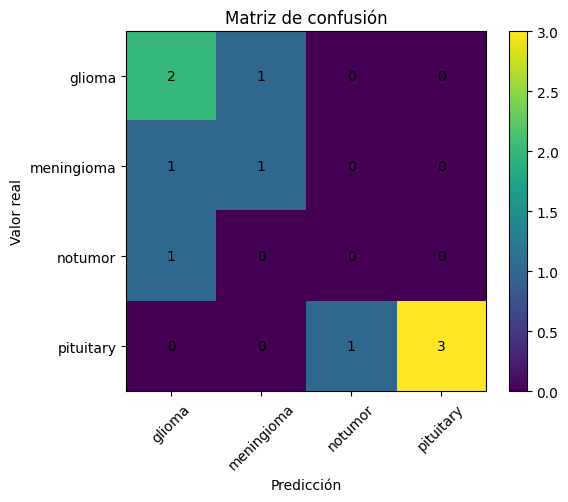


=== Classification Report ===
              precision    recall  f1-score   support

      glioma      0.500     0.667     0.571         3
  meningioma      0.500     0.500     0.500         2
     notumor      0.000     0.000     0.000         1
   pituitary      1.000     0.750     0.857         4

    accuracy                          0.600        10
   macro avg      0.500     0.479     0.482        10
weighted avg      0.650     0.600     0.614        10

Accuracy global : 0.600
Precision macro : 0.500
Recall macro    : 0.479
F1‑score macro  : 0.482


In [ ]:
y_true = df['true_label']
y_pred = df['predicted_label']

# Calcula la matriz de confusión
labels = sorted(y_true.unique())                # orden consistente de clases
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Visualiza la matriz de confusión
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de confusión')
plt.colorbar()
tick_marks = range(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)
plt.xlabel('Predicción')
plt.ylabel('Valor real')

# Etiqueta cada celda con el número de ejemplos
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

# Métricas agregadas
print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, digits=3))

accuracy = accuracy_score(y_true, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f'Accuracy global : {accuracy:.3f}')
print(f'Precision macro : {macro_p:.3f}')
print(f'Recall macro    : {macro_r:.3f}')
print(f'F1‑score macro  : {macro_f1:.3f}')

### ¿Cómo se desempeñó el LLM frente a cada clase?

El LLM mostró rendimiento desigual por clase: tuvo buen desempeño en pituitary (F1 = 0.86), identificando correctamente la mayoría de los casos. Sin embargo, falló completamente en no tumor (F1 = 0), clasificando erróneamente el único caso sano como glioma, lo que evidencia un sesgo grave. En glioma y meningioma el desempeño fue moderado (F1 = 0.57 y 0.50, respectivamente), con confusiones frecuentes entre ambas clases. En general, el modelo tiende a sobre‑predecir glioma y no aprendió adecuadamente a reconocer la normalidad.

### ¿Qué técnicas mejoraron el rendimiento? (por ejemplo, reformulación del prompt, forma de ingreso de las imágenes, contexto adicional, etc.)

El prompt mejora el rendimiento mediante varias técnicas clave de prompting. Primero, utiliza una reformulación clara y jerárquica, comenzando con una instrucción general (“You are an AI radiology assistant”) seguida de una tarea específica y bien delimitada. Segundo, incluye un schema explícito, que obliga al modelo a adherirse a un formato exacto con campos ordenados, tipos de dato definidos y restricciones semánticas (por ejemplo, etiquetas válidas y valores permitidos). Tercero, ofrece instrucciones paso a paso, como cómo seleccionar la etiqueta, cómo llenar el array de hallazgos y cómo estimar coordenadas, lo cual reduce ambigüedad. Cuarto, establece reglas de salida estrictas, indicando que cualquier texto fuera del JSON invalida la respuesta, reforzando así la adherencia al formato. También se proporciona contexto relevante del dominio (etiquetas diagnósticas específicas y ejemplos de descripción), lo que limita el espacio de respuesta y mejora la precisión clínica. Estas técnicas, combinadas, refinan la comprensión de la tarea, guían al modelo hacia salidas consistentes y útiles, y reducen significativamente errores estructurales y semánticos.

### ¿Qué limitaciones identificaron en el enfoque con LLM?

El enfoque con LLM presenta varias limitaciones: las cuotas y latencia de la API restringen su uso a pequeña escala; la ventana de contexto limitada impide procesar series completas de imágenes; y su desempeño depende fuertemente de la redacción del prompt, lo que introduce variabilidad. Además, sin fine‑tuning específico, su precisión en tareas puramente visuales es inferior a modelos tradicionales como CNNs. También enfrenta altos costos computacionales y económicos al procesar imágenes grandes, y su naturaleza estocástica dificulta la reproducibilidad y la trazabilidad de sus decisiones.

### ¿Qué ventajas ofrece este tipo de modelo respecto al modelo tradicional?

Los LLM ofrecen ventajas clave frente a modelos tradicionales: permiten trabajar en modo few-shot o zero-shot, sin requerir entrenamiento desde cero; pueden combinar múltiples modalidades (imagen, texto, historial clínico); generan salidas estructuradas y explicativas (JSON + descripciones); y permiten iterar rápidamente ajustando solo el prompt. Además, pueden generalizar semánticamente a nuevas tareas o clases sin modificar la arquitectura y reducen la dependencia de grandes volúmenes de datos etiquetados, lo que los hace útiles incluso en contextos con poca anotación.

## H. Generación de los archivos de envío para la competencia

Generamos una función simple que dado un modelo que reciba una muestra en el formato especificado, sea capaz de generar una predicción.

In [ ]:
def generateSubmissionFromImages(model, test_data ,name = 'submission.csv'):
  assert os.path.exists(test_data), rf'{test_data} not found'
  data = {
      'id': [],
      'label': []
  }
  for file_ in os.listdir(test_data):
    file_path = os.path.join(test_data, file_)
    sample = np.array(Image.open(file_path))
    class_ = model.predict(sample)
    data['id'].append(file_)
    data['label'].append(class_)
  df = pd.DataFrame(data)
  df.to_csv(os.path.join(submissions_path, name), index=False)
  print(f'Submission file generated at {name}')

def create_test_generator(test_dir, batch_size=32, target_size=(224,224)):
    image_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    test_df = pd.DataFrame({'filename': image_files})
    test_datagen = ImageDataGenerator()
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=test_dir,
        x_col='filename',
        y_col=None,
        batch_size=batch_size,
        shuffle=False,
        class_mode=None,
        target_size=target_size
    )
    return test_generator , test_df

def generateSubmissionFromImagesKeras(model, test_data, train_data, name='submission.csv', batch_size=32,
                                      target_size=(224,224)):
    assert os.path.exists(test_data), f'{test_data} not found'
    index_to_class = {v: k for k, v in train_data.class_indices.items()}
    test_generator, test_df = create_test_generator(test_data, batch_size=batch_size, target_size=target_size)
    preds = model.predict(test_generator, verbose=1)
    predicted_class_indices = preds.argmax(axis=1)
    predicted_labels = [index_to_class[idx] for idx in predicted_class_indices]
    submission_df = pd.DataFrame({
        'id': test_df['filename'],
        'label': predicted_labels
    })
    output_path = os.path.join(submissions_path, name)
    submission_df.to_csv(output_path, index=False)
    print(f'Submission file generated at {output_path}')

def generateSubmissionFromEmbeddings(model, label_encoder, ids, data, name = 'submission.csv'):
  assert len(ids) == len(data), 'ids and data must have the same length'
  y_preds = model.predict(data)
  y_preds = label_encoder.inverse_transform(y_preds)
  df = {
      'id': ids if isinstance(ids, list) else list(ids),
      'label': y_preds
  }
  df = pd.DataFrame(df)
  df.to_csv(os.path.join(submissions_path, name), index=False)
  print(f'Submission file generated at {name}')

def checkSubmission(name = 'submission.csv'):
  test_data = os.path.join(dataset_path , 'test')
  df_path = os.path.join(submissions_path, name)
  assert os.path.exists(test_data), rf'{test_data} not found'
  assert os.path.exists(df_path), rf'{df_path} not found'
  df = pd.read_csv(df_path)
  assert len(df)==len(os.listdir(test_data))
  print(f'Submission file {name} is valid')

Hacemos el ejercicio de probar esta rutina usando un modelo trivial (Es decir aquel que siempre predice la misma clase) de tal forma que se pueda comprobar que el esquema de clasificación es correcto

In [ ]:
class SimpleTrivialModel:
  def __init__(self, label):
    self.label = label
  def predict(self, sample):
    return self.label

labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
test_data = os.path.join(dataset_path , 'test')

for label in labels:
  generateSubmissionFromImages(SimpleTrivialModel(label), test_data, f'submission_trivial_{label}.csv')
  checkSubmission(f'submission_trivial_{label}.csv')
  print()

Submission file generated at submission_trivial_glioma.csv
Submission file submission_trivial_glioma.csv is valid

Submission file generated at submission_trivial_meningioma.csv
Submission file submission_trivial_meningioma.csv is valid

Submission file generated at submission_trivial_notumor.csv
Submission file submission_trivial_notumor.csv is valid

Submission file generated at submission_trivial_pituitary.csv
Submission file submission_trivial_pituitary.csv is valid



Con esto, podemos evidenciar que en el conjunto de test las clases también se encuentran balanceadas y que la función que genera las submissions también es correcta:

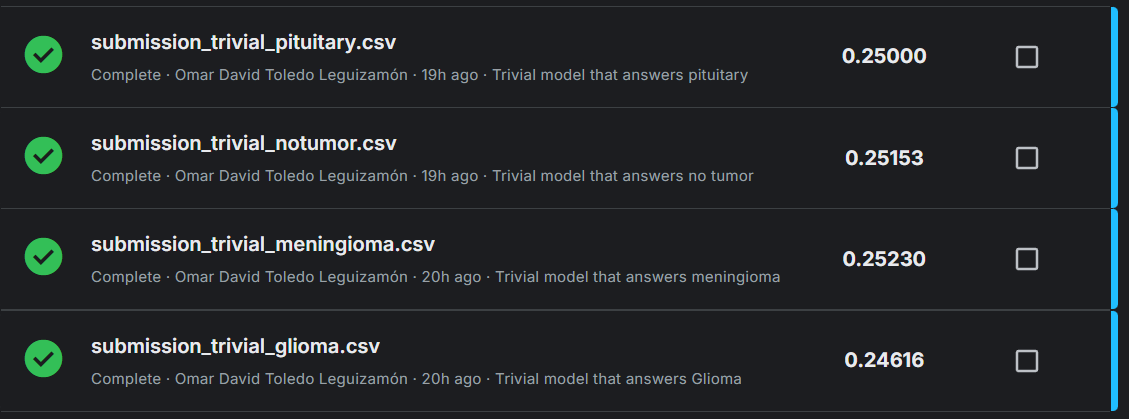

Con este resultado, podemos determinar aproximadamente la proporcion de las etiquetas en el conjunto de test.

En modelos triviales de $n$ clases, el macro recall siempre será $\frac{1}{n}$. Por otro lado, en estos modelos, el accuracy obtenido nos dirá las proporcion de muestras en la clase de interes. Con esto derivamos la siguiente formula:

$$p = 2 \cdot \text{score} - \dfrac{1}{n}$$

In [ ]:
def getProp(score, n=4):
  return 2 * score - 1/n

scores = {
    'glioma' : 0.24616,
    'no tumor': 0.25153,
    'meningioma': 0.25230,
    'pituitary': 0.25000
}

tot = 0
for k, v in scores.items():
  prop = getProp(v)
  print(f'Class {k} --> {prop:.4f}')
  tot += prop

assert np.isclose(tot, 1, rtol = 1e-2)

Class glioma --> 0.2423
Class no tumor --> 0.2531
Class meningioma --> 0.2546
Class pituitary --> 0.2500


El siguiente ejercicio, será generar las submissions usando los mejores modelos dada la exploración de hiperparametros realizada anteriormente

In [ ]:
def loadModel(route):
  pipeline = joblib.load(os.path.join(models_path, route))
  assert hasattr(pipeline, 'predict')
  return pipeline

def loadKerasModel(route):
  pipeline = tf.keras.models.load_model(os.path.join(models_path, route))
  assert hasattr(pipeline, 'predict')
  return pipeline

def loadScaler(route):
  pipeline = joblib.load(os.path.join(models_path, route))
  assert hasattr(pipeline, 'transform')
  return pipeline

def loadLabelEncoder(route):
  pipeline = joblib.load(os.path.join(models_path, route))
  assert hasattr(pipeline, 'inverse_transform')
  return pipeline

source_dir = os.path.join(preprocessed_base_path, 'pixel_intensity_normalization', 'test')
x_test_ids = sorted([f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
X_test = np.load(os.path.join(preprocessed_base_path, 'test_embeddinngs_dinov2.npy'))

Hacemos la submission del pipeline generado con KNN

In [ ]:
KNN_model_route = os.path.join(models_path, 'pipelineKNN.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

KNN_model = loadModel(KNN_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'bestKNNModelSubmission.csv'
generateSubmissionFromEmbeddings(KNN_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at bestKNNModelSubmission.csv
Submission file bestKNNModelSubmission.csv is valid


Generamos la submission del modelo Naive-Bayes Gaussiano

In [ ]:
GNB_model_route = os.path.join(models_path, 'pipelineGNB.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

GNB_model = loadModel(GNB_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'bestGNBModelSubmission.csv'
generateSubmissionFromEmbeddings(GNB_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at bestGNBModelSubmission.csv
Submission file bestGNBModelSubmission.csv is valid


Generamos la submission del modelo SVM con kernel lineal

In [ ]:
SVCLinear_model_route = os.path.join(models_path, 'pipelineSVC_linear.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

SVCLinear_model = loadModel(SVCLinear_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'bestSVCLinearModelSubmission.csv'
generateSubmissionFromEmbeddings(SVCLinear_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at bestSVCLinearModelSubmission.csv
Submission file bestSVCLinearModelSubmission.csv is valid


In [ ]:
SVCRBF_model_route = os.path.join(models_path, 'pipelineSVC_RBF.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

SVCRBF_model = loadModel(SVCRBF_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'bestSVCRBFModelSubmission.csv'
generateSubmissionFromEmbeddings(SVCRBF_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at bestSVCRBFModelSubmission.csv
Submission file bestSVCRBFModelSubmission.csv is valid


Generamos la submission del modelo SVM con kernel polinomial

In [ ]:
SVCpoly_model_route = os.path.join(models_path, 'pipelineSVC_polynomial.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

SVCpoly_model = loadModel(SVCpoly_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'bestSVCpolyModelSubmission.csv'
generateSubmissionFromEmbeddings(SVCpoly_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at bestSVCpolyModelSubmission.csv
Submission file bestSVCpolyModelSubmission.csv is valid


Generamos la submission del modelo XGB al que se le hizo la busqueda de hiperparametros con grilla

In [ ]:
XGB_model_route = os.path.join(models_path, 'pipelineXGB.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

XGB_model = loadModel(XGB_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'bestXGBModelSubmission.csv'
generateSubmissionFromEmbeddings(XGB_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at bestXGBModelSubmission.csv
Submission file bestXGBModelSubmission.csv is valid


Generamos la submission del modelo XGB más grande dada la teoría de que el modelo anterior daba señales de underfitting

In [ ]:
XGB_model_route = os.path.join(models_path, 'pipelineLargeXGB.pkl')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')

XGB_model = loadModel(XGB_model_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

name = f'LargeXGBModelSubmission.csv'
generateSubmissionFromEmbeddings(XGB_model, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

Submission file generated at LargeXGBModelSubmission.csv
Submission file LargeXGBModelSubmission.csv is valid


Generamos la submission de los modelos de red neuronal usando los embeddings como base de entrenamiento

In [ ]:
keras_model_route = os.path.join(models_path, 'model_embedding.keras')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')
scaler_route = os.path.join(preprocessed_base_path, 'scaler.pkl')

keras_model = loadKerasModel(keras_model_route)
scaler = loadScaler(scaler_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

pipeline = Pipeline(
    [
        ('scaler', scaler),
        ('model', keras_model)
    ]
)

name = f'kerasEmbeddingModelSubmission.csv'

warnings.filterwarnings("ignore", message="This Pipeline instance is not fitted yet")
generateSubmissionFromEmbeddings(KerasModel(pipeline), label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Submission file generated at kerasEmbeddingModelSubmission.csv
Submission file kerasEmbeddingModelSubmission.csv is valid


In [ ]:
keras_model_route = os.path.join(models_path, 'model2_embedding.keras')
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')
scaler_route = os.path.join(preprocessed_base_path, 'scaler.pkl')

keras_model = loadKerasModel(keras_model_route)
scaler = loadScaler(scaler_route)
label_encoder_ = loadLabelEncoder(label_encoder_route)

pipeline = Pipeline(
    [
        ('scaler', scaler),
        ('model', keras_model)
    ]
)

name = f'kerasEmbeddingModel2Submission.csv'
warnings.filterwarnings("ignore", message="This Pipeline instance is not fitted yet")
generateSubmissionFromEmbeddings(KerasModel(pipeline), label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Submission file generated at kerasEmbeddingModel2Submission.csv
Submission file kerasEmbeddingModel2Submission.csv is valid


Generamos la submission del modelo ensamblador

In [ ]:
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')
label_encoder_ = loadLabelEncoder(label_encoder_route)

model_routes = [
    os.path.join(models_path, 'pipelineSVC_linear.pkl'),
    os.path.join(models_path, 'pipelineSVC_RBF.pkl'),
    os.path.join(models_path, 'pipelineSVC_polynomial.pkl'),
    os.path.join(models_path, 'pipelineLargeXGB.pkl')
]

models = []
for route in model_routes:
    models.append(joblib.load(route))

keras_model = tf.keras.models.load_model(os.path.join(models_path, 'model_embedding.keras'))
p = Pipeline([
    ('scaler', scaler),
    ('model', keras_model)
])
models.append(KerasModel(p))
ensembler = EnsembleModel(models, label_encoder=None)

name = f'ensembleSubmission.csv'
warnings.filterwarnings("ignore", message="This Pipeline instance is not fitted yet")
generateSubmissionFromEmbeddings(ensembler, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Submission file generated at ensembleSubmission.csv
Submission file ensembleSubmission.csv is valid


In [ ]:
label_encoder_route = os.path.join(preprocessed_base_path, 'label_encoder.pkl')
label_encoder_ = loadLabelEncoder(label_encoder_route)

model_routes = [
    os.path.join(models_path, 'pipelineSVC_RBF.pkl'),
    os.path.join(models_path, 'pipelineSVC_polynomial.pkl'),
]

models = []
for route in model_routes:
    models.append(joblib.load(route))

keras_model = tf.keras.models.load_model(os.path.join(models_path, 'model_embedding.keras'))
p = Pipeline([
    ('scaler', scaler),
    ('model', keras_model)
])
models.append(KerasModel(p))
ensembler = EnsembleModel(models, label_encoder=None)

name = f'ensemble3BestSubmission.csv'
warnings.filterwarnings("ignore", message="This Pipeline instance is not fitted yet")
generateSubmissionFromEmbeddings(ensembler, label_encoder_ , x_test_ids, X_test, name=name)
checkSubmission(name)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Submission file generated at ensemble3BestSubmission.csv
Submission file ensemble3BestSubmission.csv is valid


Generamos las submission de los 4 modelos de deep learning entrenados

In [ ]:
X = np.load(os.path.join(preprocessed_base_path, 'train_embeddinngs_dinov2.npy'))
X_test = np.load(os.path.join(preprocessed_base_path, 'test_embeddinngs_dinov2.npy'))

train_df = pd.read_csv(os.path.join(dataset_path, 'train_labels.csv'))
source_dir = os.path.join(preprocessed_base_path, 'data_augmentation', 'train')
X_ids = sorted([f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
X_ids_cropped = list(map(lambda x: x.split('_')[0]+'.jpg', X_ids))
expanded_df = pd.DataFrame({
    'filename': X_ids,
    'id': X_ids_cropped
})
final_df = expanded_df.merge(train_df, on='id', how='left')
y = final_df['label']

In [ ]:
train_df, val_df = train_test_split(
    final_df,
    test_size=0.1,
    stratify=y,
    random_state=42
)

image_size = 224
batch_size = 32

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=os.path.join(preprocessed_base_path, 'data_augmentation', 'train'),
    x_col='filename',
    y_col='label',
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

Found 13809 validated image filenames belonging to 4 classes.


In [ ]:
test_model = os.path.join(models_path, 'modelResNet50V2.keras')
model = loadKerasModel(test_model)
test_target = os.path.join(preprocessed_base_path, 'pixel_intensity_normalization', 'test')
name = 'submission_resnet50v2.csv'
generateSubmissionFromImagesKeras(model, test_target, train_data, name = name, target_size=(224,224))
checkSubmission(name = name)

Found 1305 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 296ms/step
Submission file generated at /content/drive/Shareddrives/ISI-proj/submissions/submission_resnet50v2.csv
Submission file submission_resnet50v2.csv is valid


In [ ]:
test_model = os.path.join(models_path, 'modelResnet101.keras')
model = loadKerasModel(test_model)
test_target = os.path.join(preprocessed_base_path, 'pixel_intensity_normalization', 'test')
name = 'submission_resnet101.csv'
generateSubmissionFromImagesKeras(model, test_target, train_data, name = name, target_size=(224,224))
checkSubmission(name = name)

Found 1305 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 377ms/step
Submission file generated at /content/drive/Shareddrives/ISI-proj/submissions/submission_resnet101.csv
Submission file submission_resnet101.csv is valid


In [ ]:
test_model = os.path.join(models_path, 'modelEfficientB4.keras')
model = loadKerasModel(test_model)
test_target = os.path.join(preprocessed_base_path, 'pixel_intensity_normalization', 'test')
name = 'submission_efficientb4.csv'
generateSubmissionFromImagesKeras(model, test_target, train_data, name = name, target_size=(380,380))
checkSubmission(name = name)

Found 1305 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 40s 690ms/step
Submission file generated at /content/drive/Shareddrives/ISI-proj/submissions/submission_efficientb4.csv
Submission file submission_efficientb4.csv is valid


In [ ]:
test_model = os.path.join(models_path, 'modelXception.keras')
model = loadKerasModel(test_model)
test_target = os.path.join(preprocessed_base_path, 'pixel_intensity_normalization', 'test')
name = 'submission_xception.csv'
generateSubmissionFromImagesKeras(model, test_target, train_data, name = name, target_size=(229,229))
checkSubmission(name = name)

Found 1305 validated image filenames.
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 290ms/step
Submission file generated at /content/drive/Shareddrives/ISI-proj/submissions/submission_xception.csv
Submission file submission_xception.csv is valid


Después de esto, el mejor modelo según el leaderboard, fue aquel que involucro fine tunning al modelo EfficientNetB4

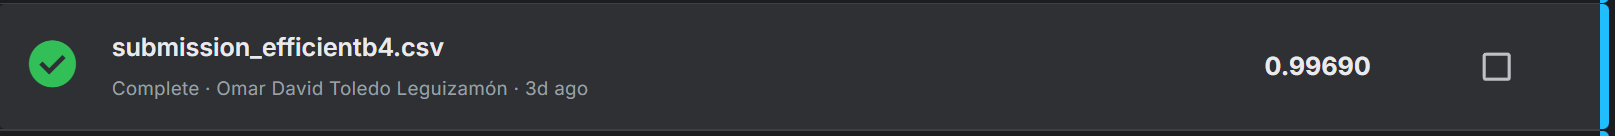

## I. Conclusiones y resultados

### Problema
Las imágenes de resonancia magnética (RM) contienen una enorme cantidad de información visual difícil de procesar manualmente. El aprendizaje automático, en particular el aprendizaje profundo, permite automatizar la detección de patrones complejos y sutiles, facilitando el análisis masivo de datos con precisión y rapidez.

El problema está bien definido (clasificación multiclase), y existe disponibilidad de conjuntos de datos etiquetados, lo que lo hace adecuado para entrenar y validar modelos.

El proyecto demuestra que el aprendizaje automático es una herramienta pertinente para la detección temprana de tumores cerebrales en imágenes de resonancia magnética, porque permite:

Las CNN pre-entrenadas (p. ej., ResNet-101) aprenden representaciones jerárquicas que revelan variaciones morfológicas mínimas entre tipos de tumor, algo que un radiólogo solo podría detectar tras años de experiencia.

Un modelo entrenado procesa cientos de resonancias por minuto, aliviando la carga de especialistas y reduciendo los tiempos de diagnóstico en entornos con alta demanda.

La combinación de accuracy y macro-recall proporciona una medida objetiva y constante de desempeño, evitando sesgos subjetivos y garantizando que las clases minoritarias (p. ej., tumores poco frecuentes) no queden invisibilizadas.

### Preprocesamiento

La estandarización de las imágenes de entrada contribuyó a reducir el margen de error de los modelos, al minimizar la posibilidad de que aprendan patrones no deseados o irrelevantes presentes en los datos. Esta normalización garantiza que las redes enfoquen su aprendizaje en las características realmente discriminativas.

El aumento de datos hecho contribuyó a que los modelos puedieran extraer mejor las caracteristicas y parametros que se deben tener en cuenta para la clasificación precisa de las imagenes.

### Modelos

La extracción de embeddings a partir de cada imagen permitió una clasificación efectiva utilizando modelos clásicos como SVM (lineal, RBF, polinómico), K-NN, Gaussian Naïve Bayes y XGBoost, incluso en entornos con recursos computacionales limitados.

Los vectores generados por DINOv2 capturan de forma tan precisa la estructura del espacio de características que clasificadores relativamente simples (como K-NN, SVM y XGBoost) logran una precisión y recall del 100 % por clase. Este rendimiento excepcional solo se alcanza cuando el embedding separa de forma casi perfecta las categorías. La única excepción es Gaussian Naïve Bayes, que al asumir independencia entre las 1024 características pierde la correlación inherente al espacio y se ve penalizado en su rendimiento.

A pesar del buen desempeño de los modelos clásicos con embeddings, los modelos de aprendizaje profundo superan claramente a estos enfoques. Las CNN especializadas para resonancias magnéticas capturan patrones morfológicos que los embeddings genéricos no logran representar completamente. Estas redes aprenden una “firma radiológica” compleja, que va más allá de la simple silueta tumoral e incluye detalles sutiles como:

* La textura del tejido (liso, granulado, etc.),

* Variaciones de brillo que forman anillos o regiones claras/oscuras,

* La forma del borde tumoral (suave o irregular),

* La forma en que el tumor desplaza o deforma estructuras cerebrales adyacentes.

En conjunto, las CNN integran información local y global de la imagen, logrando una representación más rica y específica para el dominio médico.

EfficientNet-B4 superó a las otras redes del notebook porque se re-entrenó con su resolución nativa de 380 px, lo que permitió capturar detalles finos de textura y bordes que se pierden a 224 px; sus bloques MBConv con atención squeeze-excitation refuerzan automáticamente los canales clave para distinguir tumores; el fine-tuning usó un esquema gradual (primero cabeza nueva, luego base a LR bajo) y una regularización combinada (BatchNorm, Dropout, L2) que evitó sobre-ajuste; y, al optimizarse con la métrica centrada en macro-recall, la red equilibró mejor la sensibilidad entre las cuatro clases. Estos factores juntos explican por qué la EfficientNet-B4 afinada alcanzó la puntuación más alta en el cuaderno.

## Referencias



[1] National Brain Tumor Society. *Tipos de tumores cerebrales*. Recuperado de [https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://translate.google.com/translate%3Fu%3Dhttps://braintumor.org/brain-tumors/about-brain-tumors/brain-tumor-types/%26hl%3Des%26sl%3Den%26tl%3Des%26client%3Dsrp&ved=2ahUKEwiF8OS3hMqOAxVGQzABHWn_IF4QFnoECA0QAQ&usg=AOvVaw0zi_ls-TjSavS2D650vhLY](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://translate.google.com/translate%3Fu%3Dhttps://braintumor.org/brain-tumors/about-brain-tumors/brain-tumor-types/%26hl%3Des%26sl%3Den%26tl%3Des%26client%3Dsrp&ved=2ahUKEwiF8OS3hMqOAxVGQzABHWn_IF4QFnoECA0QAQ&usg=AOvVaw0zi_ls-TjSavS2D650vhLY)

[2] Mathivanan, S. K., Srinivasan, S., Koti, M. S., Kushwah, V. S., Joseph, R. B., & Shah, M. A. (2025). A secure hybrid deep learning framework for brain tumor detection and classification. *Journal of Big Data*, *12*(1), 72. Recuperado de [https://journalofbigdata.springeropen.com/articles/10.1186/s40537-025-01117-6](https://journalofbigdata.springeropen.com/articles/10.1186/s40537-025-01117-6)

[3] Saeedi, S., Rezayi, S., Keshavarz, H., & Niakan Kalhori, S. R. (2023). MRI-based brain tumor detection using convolutional deep learning methods and chosen machine learning techniques. *BMC Medical Informatics and Decision Making*, *23*(1), 16. Recuperado de [https://bmcmedinformdecismak.biomedcentral.com/articles/10.1186/s12911-023-02114-6](https://bmcmedinformdecismak.biomedcentral.com/articles/10.1186/s12911-023-02114-6)

[4] Chakrabarty, S., Roffman, C. E., & Dahiya, S. (2021). Deep Learning Model Classifies Brain Tumors From a Single MRI Scan. *Radiology: Artificial Intelligence*. Recuperado de [https://www.rsna.org/news/2021/august/dl-model-for-brain-tumors](https://www.rsna.org/news/2021/august/dl-model-for-brain-tumors)

[5] Universae Colombia. (s.f.). *Técnicas de diagnóstico por imagen*. Recuperado de [https://universae.co/blog/tecnicas-diagnostico-por-imagen/](https://universae.co/blog/tecnicas-diagnostico-por-imagen/)

[6] PostDiCom. (s.f.). *Tipos y modalidades de imágenes médicas*. Recuperado de [https://www.postdicom.com/es/blog/medical-imaging-types-and-modalities](https://www.postdicom.com/es/blog/medical-imaging-types-and-modalities)

[7] Bhatti, U. A., Liu, J., Huang, M., & Zhang, Y. (2025). FF-UNet: Feature fusion based deep learning-powered enhanced framework for accurate brain tumor segmentation in MRI images. *Image and Vision Computing*, *161*, 105635. Recuperado de [https://www.sciencedirect.com/science/article/abs/pii/S0262885625002239](https://www.sciencedirect.com/science/article/abs/pii/S0262885625002239)

[8] Salud Digital. (s.f.). *Aprendizaje profundo y sus aplicaciones en la atención médica*. Recuperado de [https://saluddigital.com/big-data/aprendizaje-profundo-y-sus-aplicaciones-en-la-atencion-medica/](https://saluddigital.com/big-data/aprendizaje-profundo-y-sus-aplicaciones-en-la-atencion-medica/)

[9] Redalyc. (s.f.). *Desafíos en el uso de la Inteligencia Artificial para el sector salud*. Recuperado de [https://www.redalyc.org/journal/5517/551774301029/html/](https://www.redalyc.org/journal/5517/551774301029/html/)

[10] Asif, S., Yi, W., Ain, Q. U., Hou, J., Yi, T., & Si, J. (2025). Brain tumor classification using MRI images and deep learning techniques. *Journal of Digital Imaging*, *38*(3), 808-819. Recuperado de [https://pmc.ncbi.nlm.nih.gov/articles/PMC12063847/](https://pmc.ncbi.nlm.nih.gov/articles/PMC12063847/)

[11] Slimi, H., Abid, S., & Sayadi, M. (2025). Revolutionizing Alzheimer's disease detection with a cutting-edge CAPCBAM deep learning framework. *Scientific Reports*, *15*(1), 13925. Recuperado de [https://www.nature.com/articles/s41598-025-98476-0](https://www.nature.com/articles/s41598-025-98476-0)

[12] Laçi, H., Sevrani, K., & Iqbal, S. (2025). Deep learning approaches for classification tasks in medical X-ray, MRI, and ultrasound images: a scoping review. *BMC Medical Imaging*, *25*(1), 156. Recuperado de: [https://bmcmedimaging.biomedcentral.com/articles/10.1186/s12880-025-01701-5](https://bmcmedimaging.biomedcentral.com/articles/10.1186/s12880-025-01701-5)

[13] Qaisar, S. M., Hanif, M., Rehman, O. U., Haider, U., & Pławiak, P. (2024). Brain tumor classification from MRI scans: a framework of hybrid deep learning model with Bayesian optimization and quantum theory-based marine predator algorithm. *Frontiers in Oncology*, *14*, 1335740. Recuperado de [https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1335740/full](https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1335740/full)

[14] I2S Research. (s.f.). *Deep Learning-Based MRI Brain Tumor Classification: Evaluating Sequential Architectures for Diagnostic Accuracy*. Recuperado de [https://i2s-research.ku.edu/deep-learning-based-mri-brain-tumor-classification-evaluating-sequential-architectures-diagnostic](https://i2s-research.ku.edu/deep-learning-based-mri-brain-tumor-classification-evaluating-sequential-architectures-diagnostic)

[15] Universitat Oberta de Catalunya. (s.f.). *Clasificación de imágenes de cáncer de cerebro mediante aprendizaje profundo*. Recuperado de [https://openaccess.uoc.edu/server/api/core/bitstreams/961a0105-a0e2-4bd3-b7e7-af47f1c93dd2/content](https://openaccess.uoc.edu/server/api/core/bitstreams/961a0105-a0e2-4bd3-b7e7-af47f1c93dd2/content)

[16] Anales de Radiología México. (2016). *Utilidad de la resonancia magnética en el diagnóstico y clasificación de los tumores astrocíticos*. Recuperado de [https://www.analesderadiologiamexico.com/previos/ARM%202016%20Vol.%2015/ARM_16_15_4_Octubre-Diciembre/arm_16_15_4_279-293.pdf](https://www.analesderadiologiamexico.com/previos/ARM%202016%20Vol.%2015/ARM_16_15_4_Octubre-Diciembre/arm_16_15_4_279-293.pdf)

[17] Mundo FESC. (s.f.). *Detección y clasificación de tumores cerebrales mediante aprendizaje profundo y detección compresiva en imágenes de resonancia magnética*. Recuperado de [https://www.fesc.edu.co/Revistas/OJS/index.php/mundofesc/article/view/932](https://www.fesc.edu.co/Revistas/OJS/index.php/mundofesc/article/view/932)

[18] American Brain Tumo Association. *Pituitary Tumors*. Recuperado de [https://www.abta.org/tumor_types/pituitary-tumors/](https://www.abta.org/tumor_types/pituitary-tumors/)

[19] Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet Classification with Deep Convolutional Neural Networks. En *Advances in Neural Information Processing Systems* (pp. 1097-1105). Recuperado de [https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

[20] Edward L. Melnick, Biran S. Everitt (2008).  En *Encyclopedia of Quantitative Risk Analysis and Assessment*. Recuperado de [https://www.wiley.com/en-dk/Encyclopedia+of+Quantitative+Risk+Analysis+and+Assessment-p-9780470061596](https://www.wiley.com/en-dk/Encyclopedia+of+Quantitative+Risk+Analysis+and+Assessment-p-9780470061596)

[21] Kaggle. (s.f.). *Brain Tumor MRI Dataset*. Recuperado de [https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri)

[22] Khiet Dang, Toi Vo, Lua Ngo, Huong Ha (2022). *A deep learning framework integrating MRI image preprocessing methods for brain tumor segmentation and classification*. Recuperado de
[https://doi.org/10.1016/j.ibneur.2022.10.014](https://doi.org/10.1016/j.ibneur.2022.10.014)

[23] Perez, L., & Wang, F. N. (2017). The Effectiveness of Data Augmentation in Image Classification using Deep Learning. *arXiv preprint arXiv:1712.04621*. Recuperado de [https://arxiv.org/abs/1712.04621](https://arxiv.org/abs/1712.04621)

[24] Suganyadevi, S., Seethalakshmi, V. & Balasamy, K. A review on deep learning in medical image analysis. Int J Multimed Info Retr 11, 19–38 (2022). Recuperado de [https://link.springer.com/article/10.1007/s13735-021-00218-1](https://link.springer.com/article/10.1007/s13735-021-00218-1)

[25] Kim, H.E., Cosa-Linan, A., Santhanam, N. et al. Transfer learning for medical image classification: a literature review. Recuperado de [https://bmcmedimaging.biomedcentral.com/articles/10.1186/s12880-022-00793-7](https://bmcmedimaging.biomedcentral.com/articles/10.1186/s12880-022-00793-7)

[26] ian D, Jiang S, Zhang L, Lu X, Xu Y. The role of large language models in medical image processing: a narrative review. Quant Imaging Med Surg. (2024). Recuperado de [https://pmc.ncbi.nlm.nih.gov/articles/PMC10784029/](https://pmc.ncbi.nlm.nih.gov/articles/PMC10784029/)

[27] Sridhar, D., & Murali Krishna, I. (2013). Brain Tumor Classification using Discrete Cosine Transform and Probabilistic Neural Network. *2013 International Conference on Signal Processing, Image*. Recuperado de [https://ieeexplore.ieee.org/document/6497966](https://ieeexplore.ieee.org/document/6497966)

[28] Menze, B. H., et al. (2015). The Multimodal Brain Tumor Image Segmentation Benchmark (BRATS). *IEEE Transactions on Medical Imaging*, *34*(10), 1993-2024. Recuperado de [https://ieeexplore.ieee.org/document/6975210](https://ieeexplore.ieee.org/document/6975210)

[29] Syed AB, Zoga AC. Artificial Intelligence in Radiology: Current Technology and Future Directions. Semin Musculoskelet Radiol. (2018) [https://pubmed.ncbi.nlm.nih.gov/30399618/](https://pubmed.ncbi.nlm.nih.gov/30399618/)

[30] Sarma, T., et al. (2024). Brain Tumor Classification from MRI Images using Deep Learning Techniques. *Journal of Digital Imaging*, *38*(3), 808-819. Recuperado de [https://pmc.ncbi.nlm.nih.gov/articles/PMC12063847/](https://pmc.ncbi.nlm.nih.gov/articles/PMC12063847/)

[31] Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. En *Medical Image Computing and Computer-Assisted Intervention – MICCAI 2015* (pp. 234-241). Recuperado de [https://arxiv.org/abs/1505.04597](https://arxiv.org/abs/1505.04597)

[32] Rahman, J. U., et al. (2025). Stages prediction of Alzheimer’s disease with shallow 2D and 3D CNNs from intelligently selected neuroimaging data. *Scientific Reports*, *15*(1), 9238. Recuperado de [https://www.nature.com/articles/s41598-025-93560-x](https://www.nature.com/articles/s41598-025-93560-x)

[33] Qaisar, S. M., et al. (2024). Brain tumor classification from MRI scans: a framework of hybrid deep learning model with Bayesian optimization and quantum theory-based marine predator algorithm. *Frontiers in Oncology*, *14*, 1335740. Recuperado de [https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1335740/full](https://www.frontiersin.org/journals/oncology/articles/10.3389/fonc.2024.1335740/full)

[34] M.Kranthi; S.Sailaja; E.V.N.Jyothi Deep Learning Approaches for Medical Image Processing in the Big Data Era. (2024). Recuperado de [https://www.scilit.com/publications/be05655c49060bf3ae01097cb0699b91](https://www.scilit.com/publications/be05655c49060bf3ae01097cb0699b91)

[35] González, S.R., Zemmoura, I., Tauber, C. (2021). 3D Brain Tumor Segmentation and Survival Prediction Using Ensembles of Convolutional Neural Networks. Recuperado de [https://link.springer.com/chapter/10.1007/978-3-030-72087-2_21](https://link.springer.com/chapter/10.1007/978-3-030-72087-2_21)

[36] iu, Z., Tong, L., Chen, L. et al. Deep learning based brain tumor segmentation: a survey. Complex Intell. Syst. 9, 1001–1026 (2023). Recuperado de [https://doi.org/10.1007/s40747-022-00815-5](https://doi.org/10.1007/s40747-022-00815-5)

[37] Instituto de Investigación Nuclear del Organismo Internacional de Energía Atómica (INIS-IAEA). (2017). *Clasificación de Tumores Cerebrales por medio de Espectroscopía de Resonancia Magnética Nuclear de Protones (ERM)*. Recuperado de [https://inis.iaea.org/collection/NCLCollectionStore/_Public/49/045/49045747.pdf](https://inis.iaea.org/collection/NCLCollectionStore/_Public/49/045/49045747.pdf)

[38] Purwono, P., Wulandari, A. N. E. ., & Nisa, K. . (2025). Explainable Artificial Intelligence (XAI) in Medical Imaging: Techniques, Applications, Challenges, and Future Directions. Advanced Mechanical and Mechatronic Systems, 1(1), 52–66. Recuperado de [https://tecnoscientifica.com/journal/amms/article/view/692](https://tecnoscientifica.com/journal/amms/article/view/692)


[39] Kebaili, A.; Lapuyade-Lahorgue, J.; Ruan, S. Deep Learning Approaches for Data Augmentation in Medical Imaging: A Review. J. Imaging 2023, 9, 81. Recuperado de [https://doi.org/10.3390/jimaging9040081](https://doi.org/10.3390/jimaging9040081)

